malak

# 03 — Prétraitement et Analyse Exploratoire
**PFA Photovoltaïque** — Surveillance et maintenance prédictive des installations PV

**Objectif :** Transformer les données brutes (dt1 météo + dt2 électrique) en un dataset nettoyé, enrichi et prêt pour l'entraînement du pipeline ML non supervisé.

**Dataset :** Zenodo — Installation PV domestique 4 kW, La Réunion (climat tropical)
- `dt1_solar_and_meteorological_measurement.csv` — irradiance, températures (échantillonnage 1 Hz)
- `dt2_electrical_production_inverter_1_with_faults.csv` — courant, tension, puissance, étiquettes de pannes (0.2 Hz)

**Pipeline :**
1. Exploration des données brutes
2. Fusion et rééchantillonnage à 5 min
3. Nettoyage (analyse d'outliers + suppression capteurs déconnectés)
4. Feature engineering (7 indicateurs physiques)
5. Analyse exploratoire visuelle (EDA)
6. Réduction de dimensionnalité (t-SNE)
7. Split chronologique 70/10/20

---
## 1. Exploration des données brutes
---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 150, "font.size": 11,
    "axes.titlesize": 14, "axes.labelsize": 12,
    "legend.fontsize": 10, "figure.titlesize": 16,
})

COLORS_FAULT = {
    0: "#4682B4", 1: "#E9967A", 2: "#8B5CF6",
    3: "#F59E0B", 4: "#EF4444", 5: "#10B981"
}
PALETTE_BINARY = ["#4682B4", "#E9967A"]

import os
os.makedirs("figures", exist_ok=True)

### 1.1 Dataset électrique (dt2) — Structure et types

In [3]:
dt2 = pd.read_csv("data/dt2_electrical_production_inverter_1_with_faults.csv")
print(f"dt2 : {dt2.shape[0]:,} lignes x {dt2.shape[1]} colonnes")
print(f"\n=== Colonnes ===")
print(dt2.columns.tolist())
print(f"\n=== Types ===")
print(dt2.dtypes)
print(f"\n=== Valeurs manquantes ===")
print(dt2.isnull().sum())
print(f"\n=== Statistiques descriptives ===")
dt2.describe()

dt2 : 2,988,814 lignes x 9 colonnes

=== Colonnes ===
['time', 'Fault', 'Ia', 'Ig', 'Eg', 'Fg', 'Pg', 'Va', 'Vg']

=== Types ===
time      object
Fault    float64
Ia       float64
Ig       float64
Eg       float64
Fg       float64
Pg       float64
Va       float64
Vg       float64
dtype: object

=== Valeurs manquantes ===
time      0
Fault     6
Ia       10
Ig       10
Eg       10
Fg       10
Pg       10
Va       10
Vg       10
dtype: int64

=== Statistiques descriptives ===


,Fault,Ia,Ig,Eg,Fg,Pg,Va,Vg
count,2.988808e+06,2.988804e+06,2.988804e+06,2.988804e+06,2.988804e+06,2.988804e+06,2.988804e+06,2.988804e+06
mean,9.955340e-02,3.840925e+00,2.731033e+00,3.423541e+00,4.990957e+01,6.503475e+02,1.809852e+02,2.334123e+02
std,6.029997e-01,2.895252e+00,2.019501e+00,2.633320e+00,1.927615e+00,4.756930e+02,1.360209e+01,9.186887e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,1.100000e+00,8.000000e-01,8.610000e-01,4.995000e+01,2.010000e+02,1.750000e+02,2.330000e+02
50%,0.000000e+00,3.200000e+00,2.300000e+00,3.226000e+00,4.998000e+01,5.450000e+02,1.830000e+02,2.340000e+02
75%,0.000000e+00,6.500000e+00,4.600000e+00,5.633000e+00,5.002000e+01,1.096000e+03,1.880000e+02,2.350000e+02
max,4.000000e+00,1.140000e+01,9.200000e+00,9.493000e+00,5.037000e+01,2.195000e+03,2.410000e+02,2.480000e+02


### 1.2 Répartition des types de pannes (Fault)

In [4]:
print("=== Répartition Fault ===")
print(dt2["Fault"].value_counts().sort_index())
print(f"\nNormal : {(dt2['Fault']==0).sum():,} | Anomalies : {(dt2['Fault']!=0).sum():,}")

=== Répartition Fault ===
Fault
0.0    2904289
1.0       6318
2.1       2148
2.2       2460
2.3       3287
3.1       2717
3.2       6292
4.0      61297
Name: count, dtype: int64

Normal : 2,904,289 | Anomalies : 84,525


### 1.3 Dataset météorologique (dt1) — Structure et échantillon

In [5]:
dt1_peek = pd.read_csv("data/dt1_solar_and_meteorological_measurement.csv", nrows=5)
print("=== Colonnes dt1 ===")
print(dt1_peek.columns.tolist())
print("\n=== 5 premières lignes ===")
dt1_peek

=== Colonnes dt1 ===
['time', 'DTI', 'GTI', 'TA', 'TPV']

=== 5 premières lignes ===


,time,DTI,GTI,TA,TPV
0,2021-10-28 16:37:45+04:00,148.8,193.8,26.99,31.03
1,2021-10-28 16:37:46+04:00,148.8,193.8,26.94,31.00
2,2021-10-28 16:37:47+04:00,148.8,193.8,26.93,31.01
3,2021-10-28 16:37:48+04:00,151.5,193.8,26.98,31.02
4,2021-10-28 16:37:49+04:00,148.8,193.8,27.02,31.01


In [6]:
dt1_sample = pd.read_csv(
    "data/dt1_solar_and_meteorological_measurement.csv",
    nrows=100_000
)
print(f"dt1 sample : {dt1_sample.shape[0]:,} lignes x {dt1_sample.shape[1]} colonnes")
print("\n=== Types ===")
print(dt1_sample.dtypes)
print("\n=== Valeurs manquantes ===")
print(dt1_sample.isnull().sum())
print("\n=== Statistiques descriptives ===")
dt1_sample.describe()

dt1 sample : 100,000 lignes x 5 colonnes

=== Types ===
time     object
DTI     float64
GTI     float64
TA      float64
TPV     float64
dtype: object

=== Valeurs manquantes ===
time    0
DTI     0
GTI     0
TA      0
TPV     0
dtype: int64

=== Statistiques descriptives ===


,DTI,GTI,TA,TPV
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,91.631491,106.600733,23.879584,26.802066
std,143.399573,180.900816,2.947540,8.226398
min,1.342000,1.375000,20.640000,20.350000
25%,1.342000,1.376000,21.230000,20.990000
50%,5.367000,6.878000,23.230000,22.250000
75%,124.700000,144.400000,26.400000,30.640000
max,609.000000,1583.000000,31.760000,57.470000


### 1.4 Vérification du format des dates (compatibilité pour la fusion)

In [7]:
print("=== Format date dt2 ===")
print(dt2.iloc[:3, 0])

print("\n=== Format date dt1 ===")
print(dt1_sample.iloc[:3, 0])

=== Format date dt2 ===
0    2021-10-01 14:10:02+04:00
1    2021-10-01 14:10:09+04:00
2    2021-10-01 14:10:16+04:00
Name: time, dtype: object

=== Format date dt1 ===
0    2021-10-28 16:37:45+04:00
1    2021-10-28 16:37:46+04:00
2    2021-10-28 16:37:47+04:00
Name: time, dtype: object


---
## 2. Pipeline de fusion : indexation temporelle, rééchantillonnage et jointure
---

In [11]:
print("Chargement dt2...")
dt2 = pd.read_csv("data/dt2_electrical_production_inverter_1_with_faults.csv")
dt2["time"] = pd.to_datetime(dt2["time"], utc=True)
dt2 = dt2.set_index("time").sort_index()
print(f"dt2 : {len(dt2):,} lignes")
print(f"Période : {dt2.index.min()} → {dt2.index.max()}")

print("\nChargement dt1 par chunks (fichier volumineux)...")
chunks = []
for i, chunk in enumerate(pd.read_csv(
    "data/dt1_solar_and_meteorological_measurement.csv",
    chunksize=500_000
)):
    chunk["time"] = pd.to_datetime(chunk["time"], utc=True)
    chunk = chunk.set_index("time").sort_index()
    chunks.append(chunk)
    print(f"  chunk {i+1} : {len(chunk):,} lignes")

dt1 = pd.concat(chunks)
print(f"\ndt1 total : {len(dt1):,} lignes")
print(f"Période : {dt1.index.min()} → {dt1.index.max()}")

# --- Rééchantillonnage à 5 minutes ---
print("\nRééchantillonnage dt1 à 5 min (moyenne)...")
dt1_5min = dt1.resample("5min").mean().dropna()
print(f"dt1 après resample : {len(dt1_5min):,} lignes")

print("Rééchantillonnage dt2 à 5 min...")
fault_5min = dt2["Fault"].resample("5min").apply(
    lambda x: x.mode().iloc[0] if len(x) > 0 and not x.mode().empty else np.nan
)
dt2_numeric = dt2.drop(columns=["Fault"]).resample("5min").mean()
dt2_5min = dt2_numeric.join(fault_5min).dropna()
print(f"dt2 après resample : {len(dt2_5min):,} lignes")

# --- Fusion (inner join sur l'index temporel) ---
print("\nFusion dt1 + dt2 (inner join)...")
df = dt1_5min.join(dt2_5min, how="inner")
print(f"Après fusion : {len(df):,} lignes x {len(df.columns)} colonnes")
print(f"Période : {df.index.min()} → {df.index.max()}")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nRépartition Fault :")
print(df["Fault"].value_counts().sort_index())

# --- Filtrage jour (GTI > 50 W/m²) ---
df = df[df["GTI"] > 50].copy()
print(f"\nAprès filtrage jour (GTI > 50) : {len(df):,} lignes")

# Sauvegarde intermédiaire
df.to_csv("data/merged_5min_day.csv")
print("Sauvegardé : data/merged_5min_day.csv")

Chargement dt2...
dt2 : 2,988,814 lignes
Période : 2021-10-01 10:10:02+00:00 → 2023-04-13 13:42:27+00:00

Chargement dt1 par chunks (fichier volumineux)...
  chunk 1 : 500,000 lignes
  chunk 2 : 500,000 lignes
  chunk 3 : 500,000 lignes
  chunk 4 : 500,000 lignes
  chunk 5 : 500,000 lignes
  chunk 6 : 500,000 lignes
  chunk 7 : 500,000 lignes
  chunk 8 : 500,000 lignes
  chunk 9 : 500,000 lignes
  chunk 10 : 500,000 lignes
  chunk 11 : 500,000 lignes
  chunk 12 : 500,000 lignes
  chunk 13 : 500,000 lignes
  chunk 14 : 500,000 lignes
  chunk 15 : 500,000 lignes
  chunk 16 : 500,000 lignes
  chunk 17 : 500,000 lignes
  chunk 18 : 500,000 lignes
  chunk 19 : 500,000 lignes
  chunk 20 : 500,000 lignes
  chunk 21 : 500,000 lignes
  chunk 22 : 500,000 lignes
  chunk 23 : 500,000 lignes
  chunk 24 : 500,000 lignes
  chunk 25 : 500,000 lignes
  chunk 26 : 500,000 lignes
  chunk 27 : 500,000 lignes
  chunk 28 : 500,000 lignes
  chunk 29 : 500,000 lignes
  chunk 30 : 500,000 lignes
  chunk 31 : 

---
## 3. Nettoyage des données
---

### 3.1 Analyse de la dispersion — Boîtes à moustaches

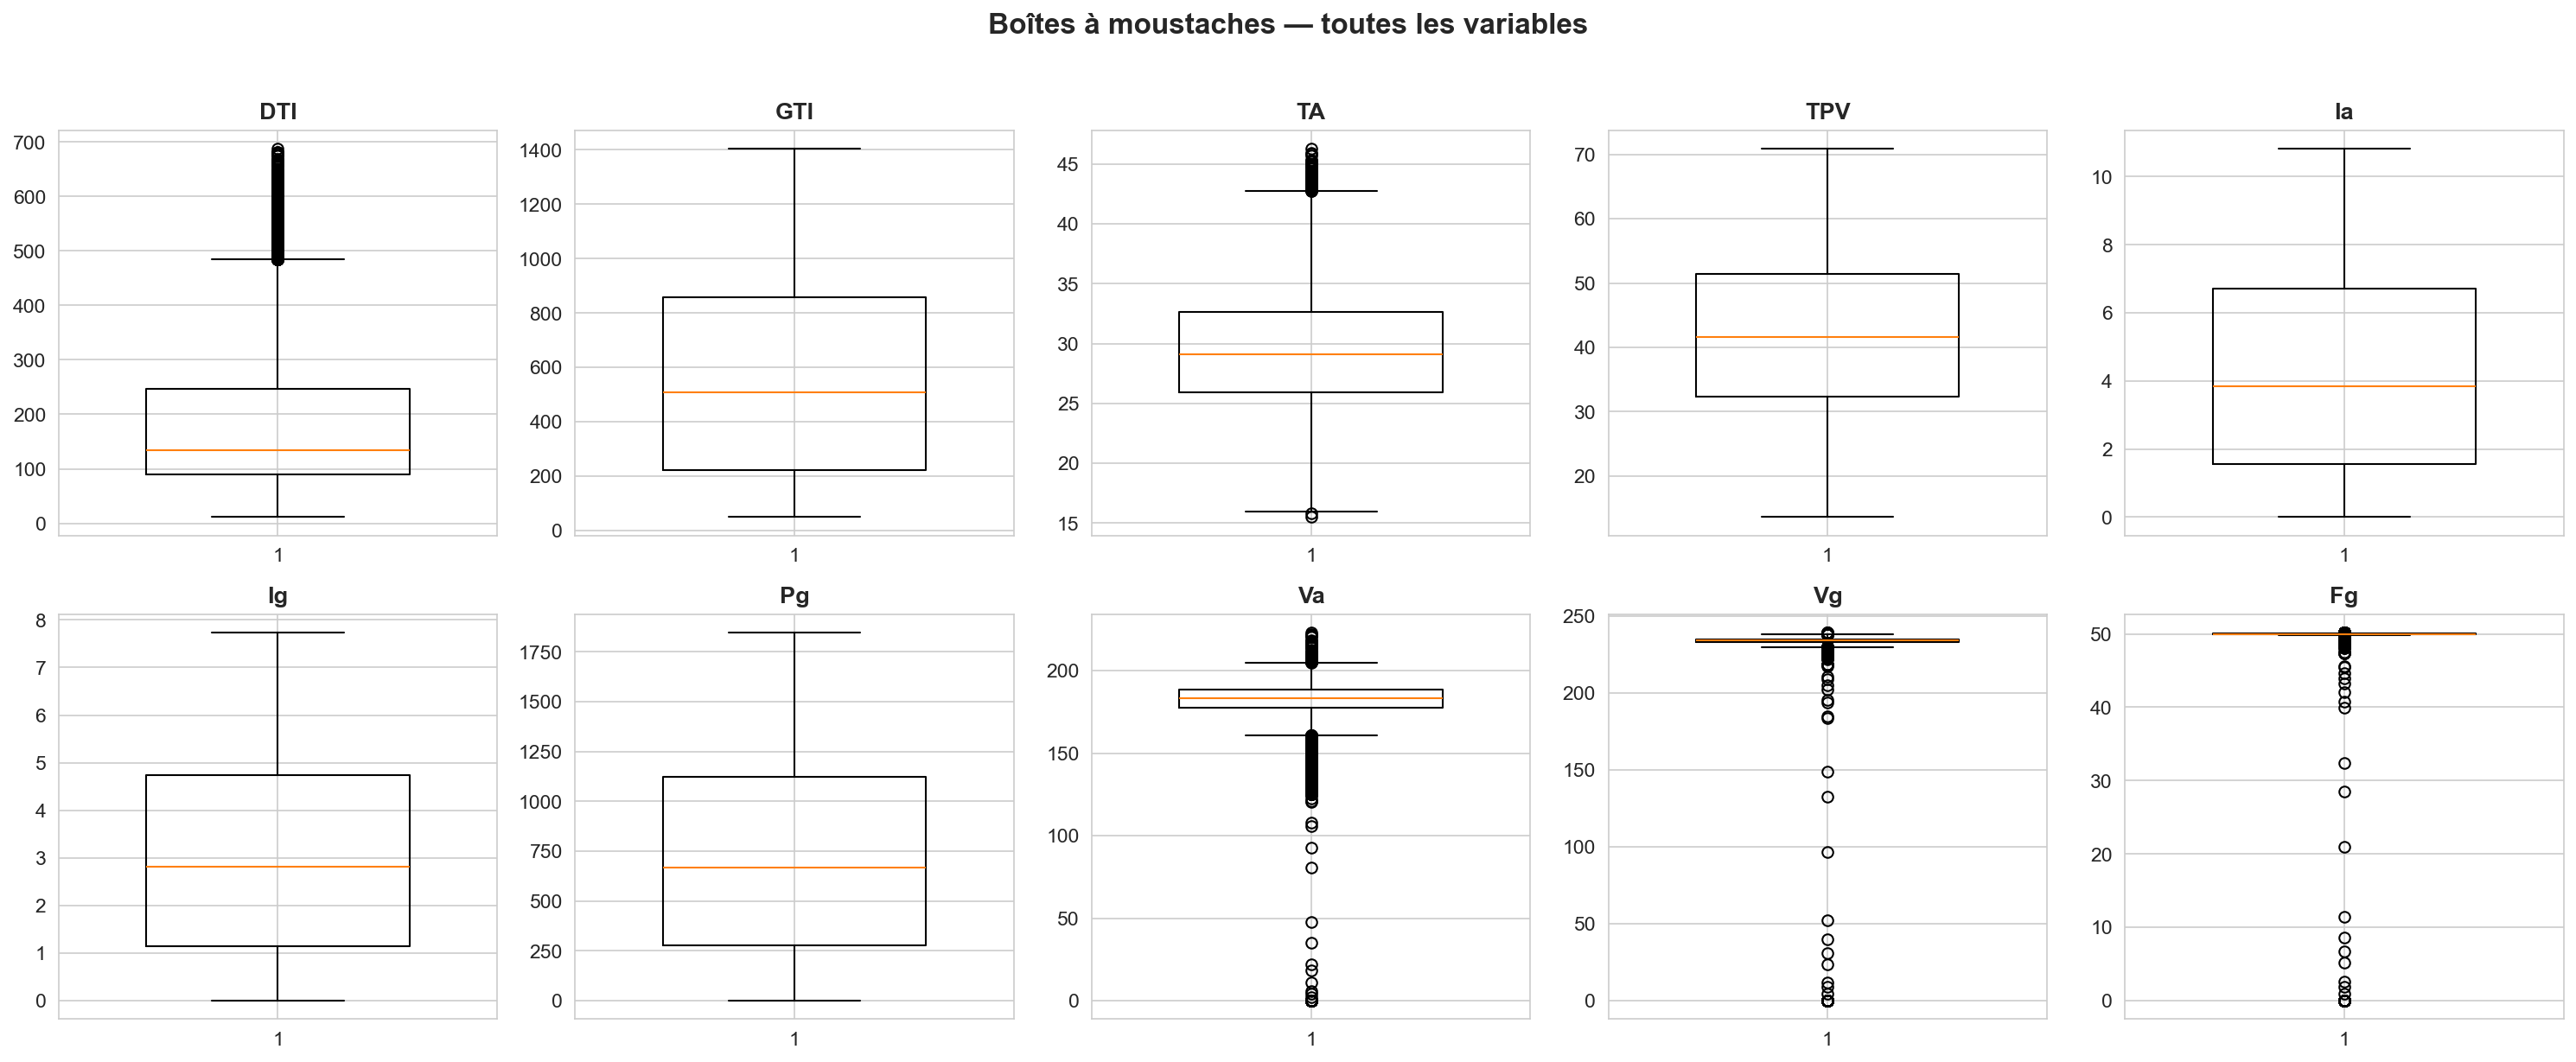

In [12]:
features = ["DTI", "GTI", "TA", "TPV", "Ia", "Ig", "Pg", "Va", "Vg", "Fg"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col].dropna(), widths=0.6)
    axes[i].set_title(col, fontsize=13, fontweight="bold")
    axes[i].set_xticklabels(["1"])

fig.suptitle("Boîtes à moustaches — toutes les variables", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Vérification physique — Valeurs suspectes

Critères de vérification :
- `Va` ou `Vg` à 0 → capteur déconnecté
- `Pg < 0` → puissance négative (erreur physique)
- `GTI > 1500` → irradiance supérieure au maximum terrestre
- `TPV < 0` → température négative du panneau (suspect en climat tropical)

In [13]:
print("=== Valeurs suspectes ===")
print(f"Va == 0     : {(df['Va'] == 0).sum()} lignes")
print(f"Vg == 0     : {(df['Vg'] == 0).sum()} lignes")
print(f"Pg < 0      : {(df['Pg'] < 0).sum()} lignes")
print(f"GTI > 1500  : {(df['GTI'] > 1500).sum()} lignes")
print(f"TPV < 0     : {(df['TPV'] < 0).sum()} lignes")

=== Valeurs suspectes ===
Va == 0     : 57 lignes
Vg == 0     : 57 lignes
Pg < 0      : 0 lignes
GTI > 1500  : 0 lignes
TPV < 0     : 0 lignes


### 3.3 Détection des outliers — Z-score

Le Z-score mesure la distance de chaque valeur par rapport à la moyenne, en nombre d'écarts-types.
Si Z > 3 ou Z < −3, la valeur est considérée comme un outlier statistique (les ~0.3% les plus extrêmes si la distribution est normale).

In [14]:
z_scores = np.abs(stats.zscore(df[features]))
outliers_z = (z_scores > 3).sum(axis=0)

print("=== Outliers par Z-score (> 3 écarts-types) ===")
for col, count in zip(features, outliers_z):
    pct = count / len(df) * 100
    print(f"  {col:6s} : {count:5d} outliers ({pct:.2f}%)")

=== Outliers par Z-score (> 3 écarts-types) ===
  DTI    :   431 outliers (0.81%)
  GTI    :     0 outliers (0.00%)
  TA     :    53 outliers (0.10%)
  TPV    :     0 outliers (0.00%)
  Ia     :     0 outliers (0.00%)
  Ig     :     0 outliers (0.00%)
  Pg     :     0 outliers (0.00%)
  Va     :   689 outliers (1.30%)
  Vg     :    73 outliers (0.14%)
  Fg     :    73 outliers (0.14%)


### 3.4 Détection des outliers — IQR (méthode des quartiles)

L'IQR est plus robuste que le Z-score pour les distributions asymétriques :
il utilise les quartiles Q1/Q3, insensibles aux valeurs extrêmes.
Un outlier est toute valeur en dehors de [Q1 − 1.5×IQR, Q3 + 1.5×IQR].

In [15]:
print("=== Outliers par IQR ===")
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_out / len(df) * 100
    print(f"  {col:6s} : {n_out:5d} outliers ({pct:.2f}%)")

=== Outliers par IQR ===
  DTI    :  1470 outliers (2.77%)
  GTI    :     0 outliers (0.00%)
  TA     :    97 outliers (0.18%)
  TPV    :     0 outliers (0.00%)
  Ia     :     0 outliers (0.00%)
  Ig     :     0 outliers (0.00%)
  Pg     :     0 outliers (0.00%)
  Va     :  1389 outliers (2.62%)
  Vg     :  1438 outliers (2.71%)
  Fg     :  1343 outliers (2.53%)


**Décision de nettoyage :** L'IQR détecte plus d'outliers que le Z-score (attendu pour des distributions asymétriques).
Les outliers de GTI, Pg, Ia, etc. sont conservés car ils pourraient être des anomalies opérationnelles réelles que le modèle doit apprendre à détecter.
Seuls les cas de **capteur déconnecté** (Va = Vg = Fg = 0 simultanément) sont supprimés : ce sont des erreurs de mesure, pas des anomalies PV.

### 3.5 Nettoyage — Suppression des lignes capteur déconnecté

In [16]:
avant = len(df)
df = df[~((df["Va"] == 0) & (df["Vg"] == 0) & (df["Fg"] == 0))]
print(f"Supprimé : {avant - len(df)} lignes (capteur déconnecté : Va=Vg=Fg=0)")
print(f"Restant  : {len(df):,} lignes")

Supprimé : 57 lignes (capteur déconnecté : Va=Vg=Fg=0)
Restant  : 52,959 lignes


### 3.6 Matrice de corrélation — Variables capteurs

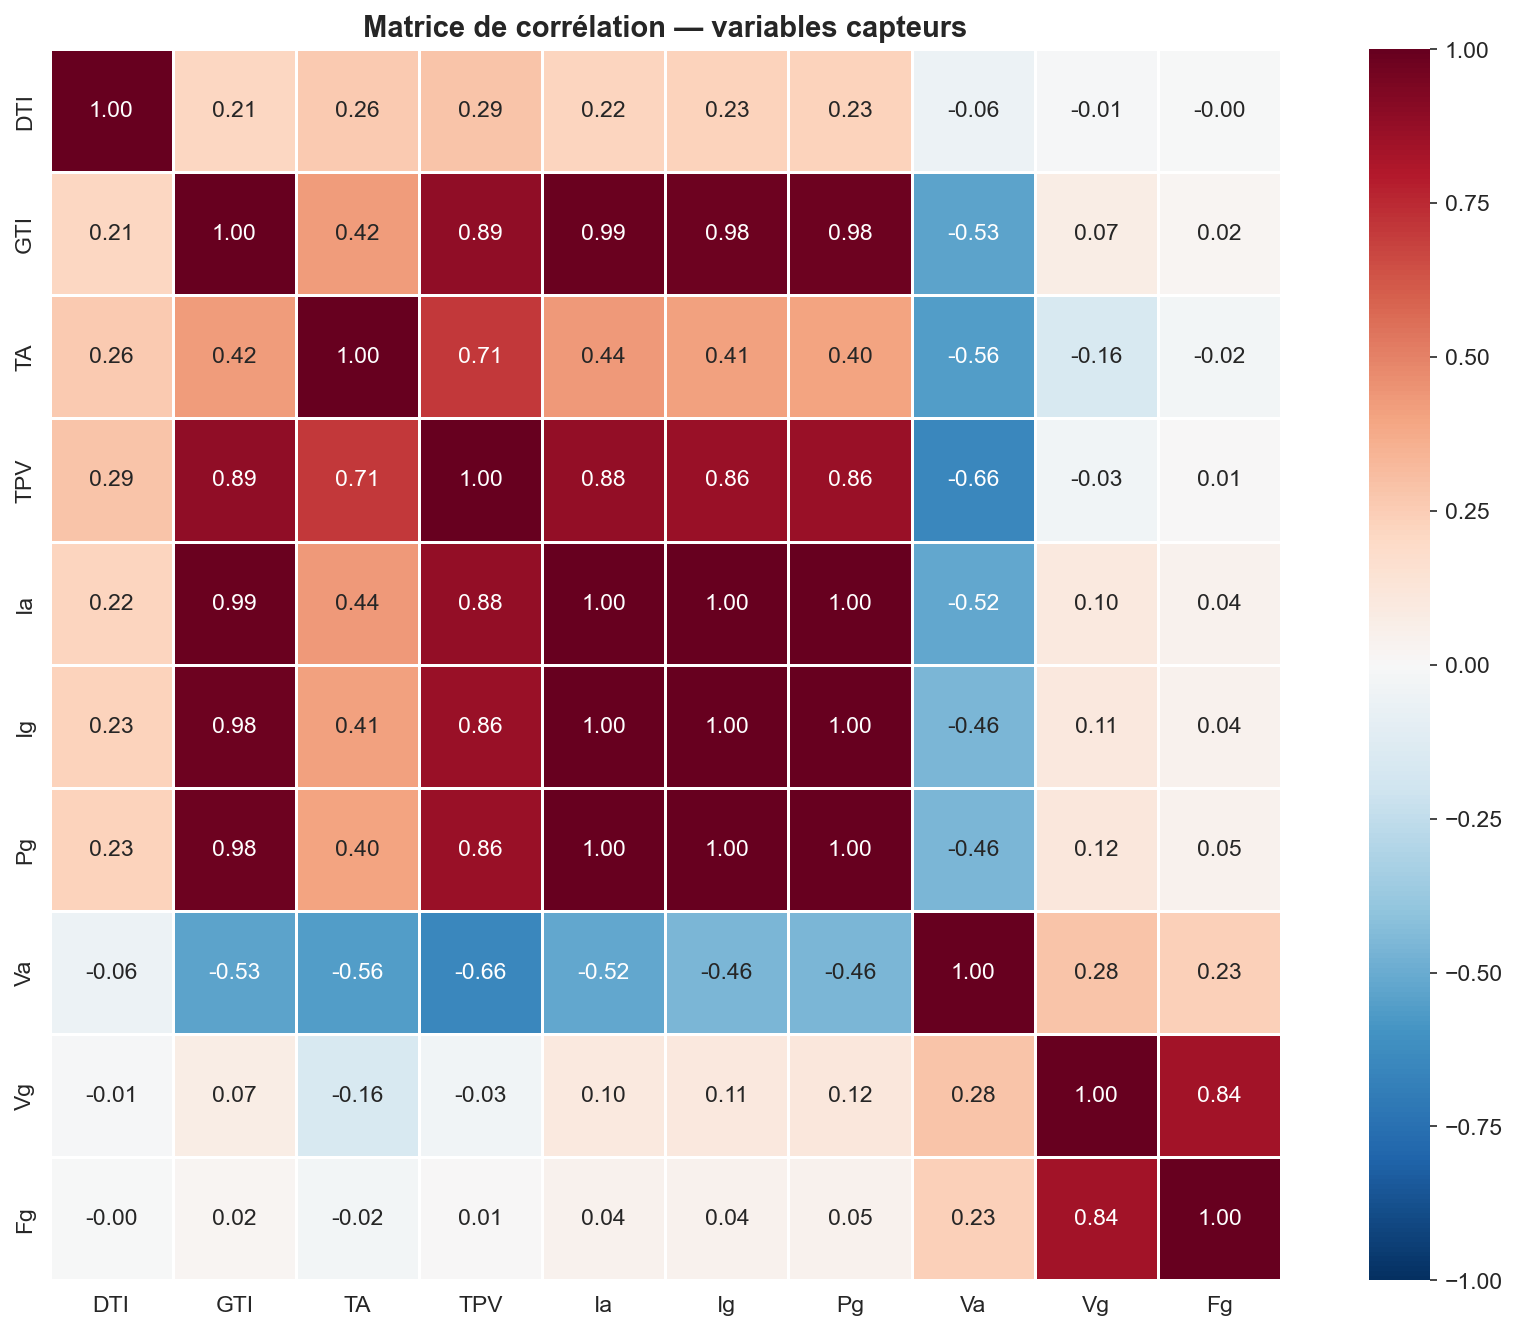

In [ ]:
corr = df[features].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Matrice de corrélation — variables capteurs", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#  Analyse Exploratoire des Données (EDA)

Cette section explore les **données brutes** (capteurs) et la **distribution des anomalies**, *avant* toute création de feature. L'objectif est de comprendre :
- la structure du jeu de données (volume, période, déséquilibre) ;
- la relation physique fondamentale entre irradiance et puissance ;
- **quand** et **comment** les anomalies apparaissent dans le temps.



In [326]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Palette
C_NORMAL = "#4682B4"
C_ANO    = "#E9967A"
C_RED    = "#E24B4A"

# Chargement des données nettoyées (capteurs bruts + colonne Fault)
df = pd.read_csv("data/cleaned_with_features.csv")
df["time"] = pd.to_datetime(df["time"], utc=True)
df = df.set_index("time").sort_index()

# Capteurs bruts uniquement (on ignore les features dérivées ici)
CAPTEURS = ["DTI", "GTI", "TA", "TPV", "Ia", "Ig", "Eg", "Fg", "Pg", "Va", "Vg"]
CAPTEURS = [c for c in CAPTEURS if c in df.columns]

print(f"Dataset : {df.shape[0]:,} lignes × {len(CAPTEURS)} capteurs")
print(f"Période : {df.index.min().date()} → {df.index.max().date()}")
print(f"Anomalies : {(df['Fault'] != 0).sum():,} ({100*(df['Fault']!=0).mean():.1f}%)")

Dataset : 52,959 lignes × 11 capteurs
Période : 2021-10-28 → 2023-04-13
Anomalies : 1,494 (2.8%)


                 Type  Nombre  Pourcentage
               Normal   51465        97.18
F1 (ombrage uniforme)      51         0.10
                 F2.1      36         0.07
                 F2.2      41         0.08
                 F2.3      55         0.10
                 F3.1      73         0.14
                 F3.2     114         0.22
    F4 (intermittent)    1124         2.12


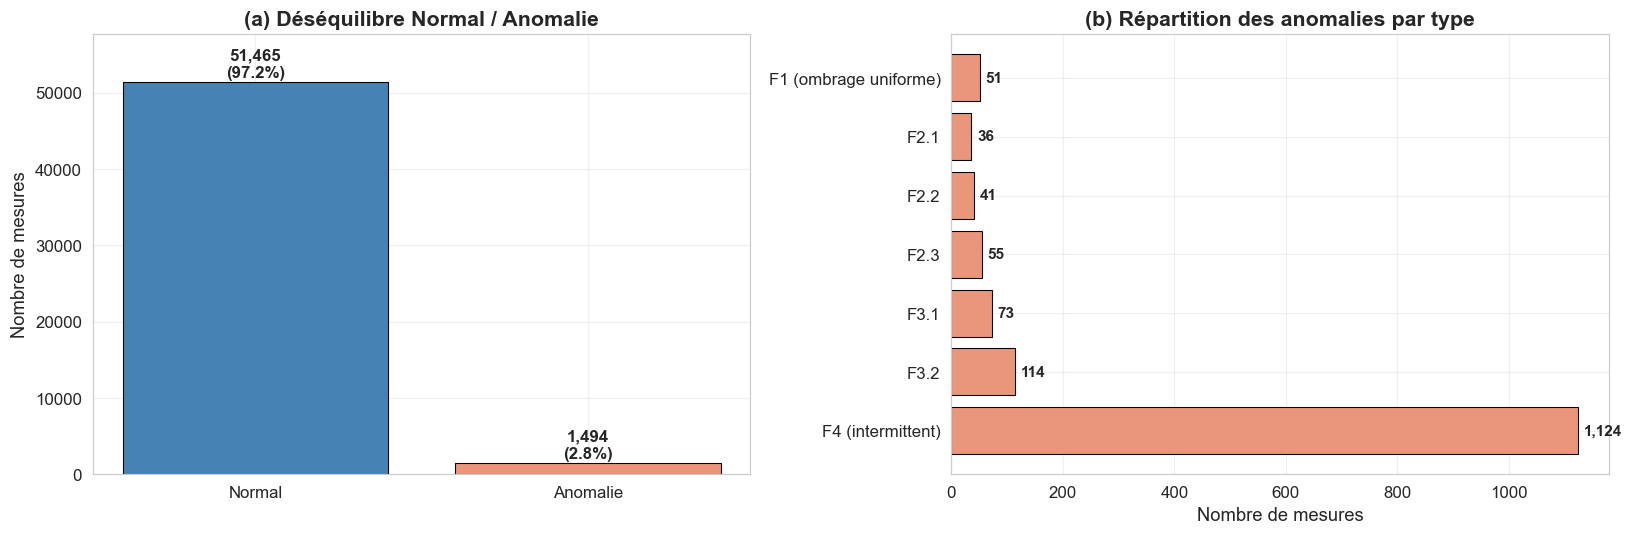


Constat : Fault 4.0 (ombrage intermittent) domine les anomalies (1124 pts),
les autres types sont rares (36-114 pts). Fort déséquilibre global (~2.8% d'anomalies).


In [327]:
# Table de fréquence par type de panne
LABELS = {0.0: "Normal", 1.0: "F1 (ombrage uniforme)",
          2.1: "F2.1", 2.2: "F2.2", 2.3: "F2.3",
          3.1: "F3.1", 3.2: "F3.2", 4.0: "F4 (intermittent)"}

counts = df["Fault"].value_counts().sort_index()
tab = pd.DataFrame({
    "Type": [LABELS.get(f, f"F{f}") for f in counts.index],
    "Nombre": counts.values,
    "Pourcentage": (100 * counts.values / len(df)).round(2),
})
print(tab.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Normal vs Anomalie (barres) — plus lisible qu'un donut surchargé
n_norm = (df["Fault"] == 0).sum()
n_ano  = (df["Fault"] != 0).sum()
bars = axes[0].bar(["Normal", "Anomalie"], [n_norm, n_ano],
                   color=[C_NORMAL, C_ANO], edgecolor="black", linewidth=0.7)
for b, v in zip(bars, [n_norm, n_ano]):
    axes[0].text(b.get_x()+b.get_width()/2, v+600, f"{v:,}\n({100*v/len(df):.1f}%)",
                 ha="center", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Nombre de mesures")
axes[0].set_title("(a) Déséquilibre Normal / Anomalie", fontweight="bold")
axes[0].set_ylim(0, n_norm*1.12)

# (b) Répartition des anomalies par type (barres horizontales, hors normal)
ano_counts = counts[counts.index != 0]
labels_ano = [LABELS.get(f, f"F{f}") for f in ano_counts.index]
axes[1].barh(labels_ano, ano_counts.values, color=C_ANO, edgecolor="black", linewidth=0.7)
for i, v in enumerate(ano_counts.values):
    axes[1].text(v+10, i, f"{v:,}", va="center", fontsize=10, fontweight="bold")
axes[1].set_xlabel("Nombre de mesures")
axes[1].set_title("(b) Répartition des anomalies par type", fontweight="bold")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("figures/eda_01_desequilibre.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nConstat : Fault 4.0 (ombrage intermittent) domine les anomalies (1124 pts),")
print("les autres types sont rares (36-114 pts). Fort déséquilibre global (~2.8% d'anomalies).")

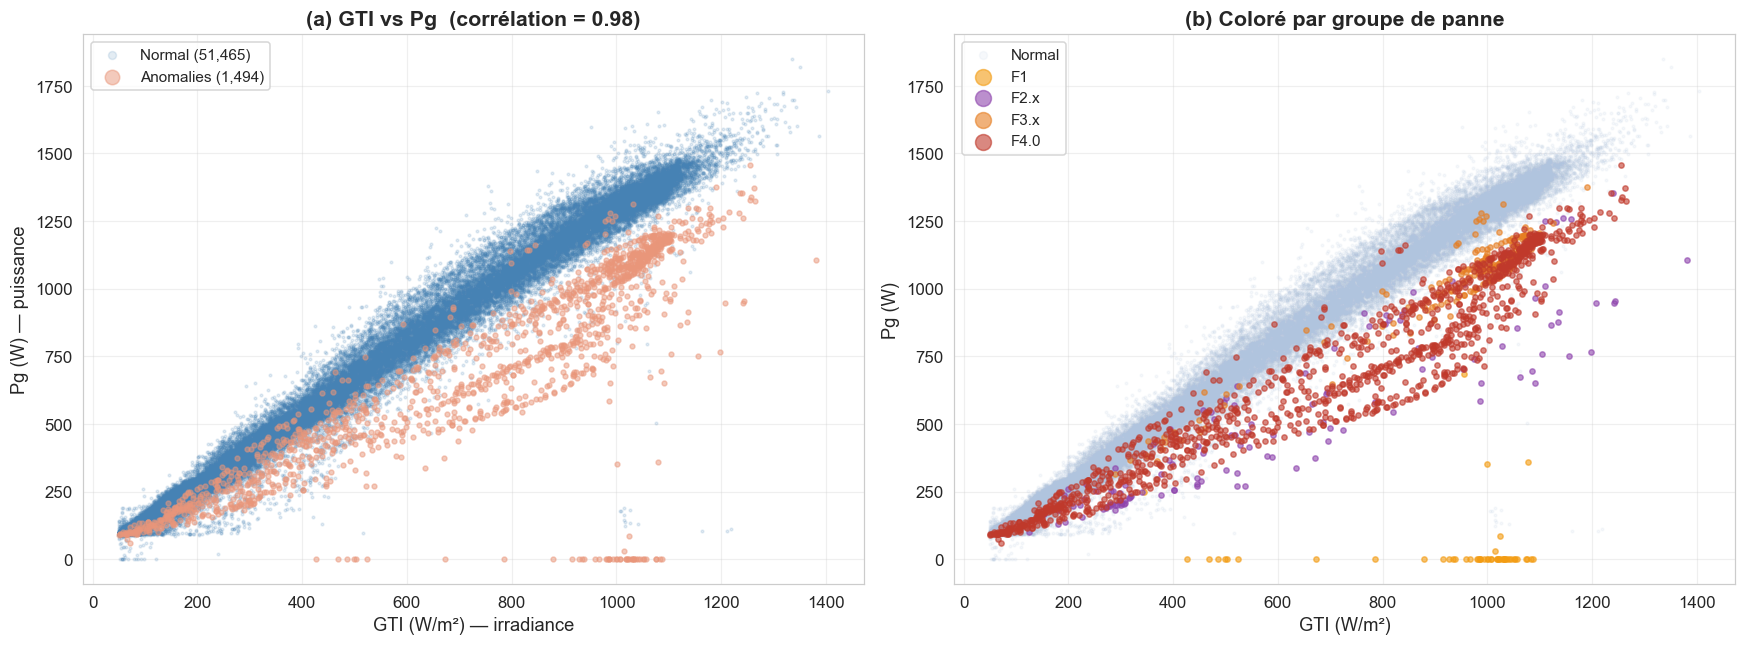

Constat : Pg et GTI sont corrélés à 0.98 (relation quasi-linéaire).
Les anomalies (orange) forment un NUAGE SOUS la droite normale : à irradiance
égale, un panneau en panne produit moins. → motive une feature de RENDEMENT Pg/GTI.


In [328]:
normal = df[df["Fault"] == 0]
anomalies = df[df["Fault"] != 0]
corr_pg_gti = df["Pg"].corr(df["GTI"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Normal vs anomalies
axes[0].scatter(normal["GTI"], normal["Pg"], s=3, alpha=0.15, c=C_NORMAL,
                label=f"Normal ({len(normal):,})")
axes[0].scatter(anomalies["GTI"], anomalies["Pg"], s=10, alpha=0.5, c=C_ANO,
                label=f"Anomalies ({len(anomalies):,})")
axes[0].set_xlabel("GTI (W/m²) — irradiance"); axes[0].set_ylabel("Pg (W) — puissance")
axes[0].set_title(f"(a) GTI vs Pg  (corrélation = {corr_pg_gti:.2f})", fontweight="bold")
axes[0].legend(markerscale=3)

# (b) Coloré par groupe de panne
df["fgroup"] = df["Fault"].apply(lambda x: 0 if x == 0 else int(x))
cmap = {0:"#B0C4DE", 1:"#F39C12", 2:"#8E44AD", 3:"#E67E22", 4:"#C0392B"}
lbl  = {0:"Normal", 1:"F1", 2:"F2.x", 3:"F3.x", 4:"F4.0"}
for g in [0, 1, 2, 3, 4]:
    sub = df[df["fgroup"] == g]
    axes[1].scatter(sub["GTI"], sub["Pg"], s=3 if g==0 else 12,
                    alpha=0.1 if g==0 else 0.6, c=cmap[g], label=lbl[g])
axes[1].set_xlabel("GTI (W/m²)"); axes[1].set_ylabel("Pg (W)")
axes[1].set_title("(b) Coloré par groupe de panne", fontweight="bold")
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig("figures/eda_02_gti_pg.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Constat : Pg et GTI sont corrélés à {corr_pg_gti:.2f} (relation quasi-linéaire).")
print("Les anomalies (orange) forment un NUAGE SOUS la droite normale : à irradiance")
print("égale, un panneau en panne produit moins. → motive une feature de RENDEMENT Pg/GTI.")

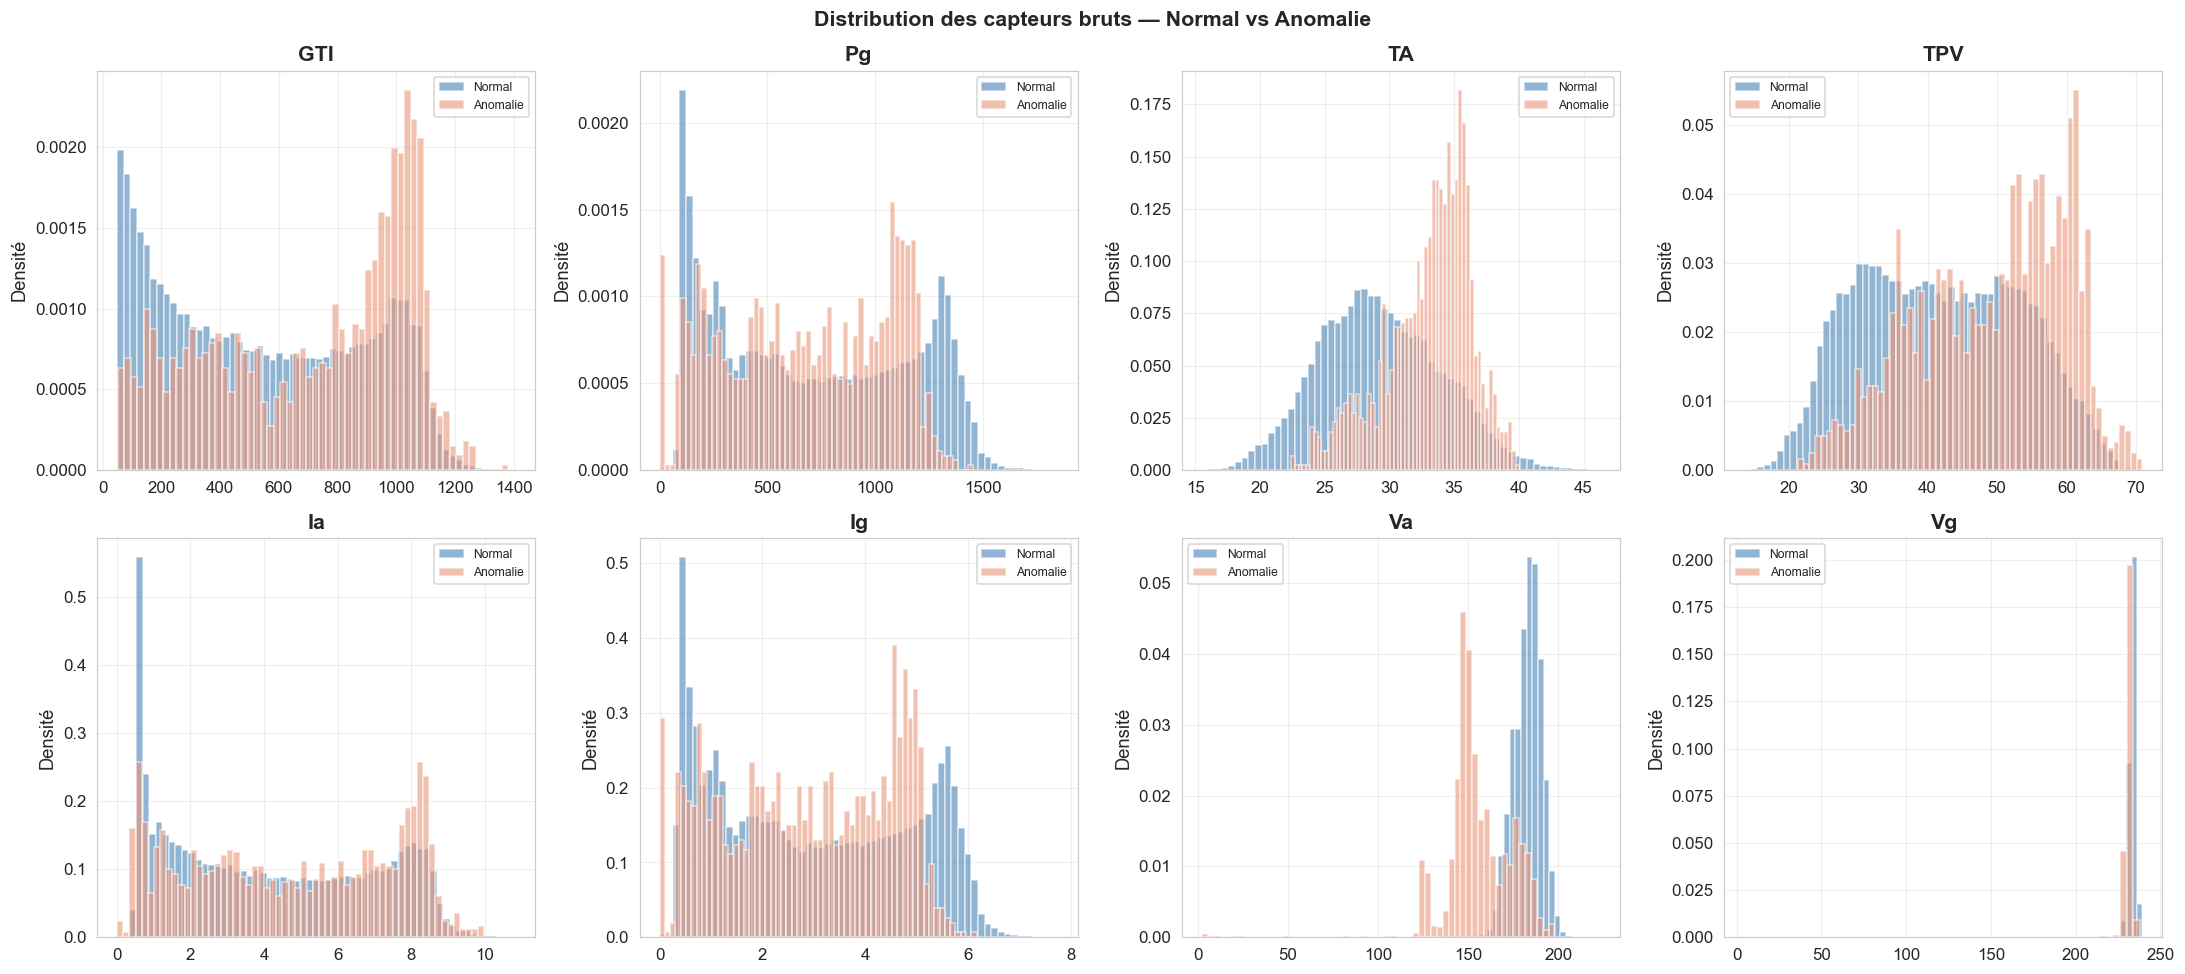

Constat : Va (tension AC) et les courants Ia/Ig montrent un décalage visible
entre normal et anomalie — indices pour le feature engineering (déviation de tension).


In [329]:
caps_show = ["GTI", "Pg", "TA", "TPV", "Ia", "Ig", "Va", "Vg"]
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, c in zip(axes.flatten(), caps_show):
    ax.hist(normal[c], bins=60, alpha=0.6, color=C_NORMAL, density=True, label="Normal")
    ax.hist(anomalies[c], bins=60, alpha=0.6, color=C_ANO, density=True, label="Anomalie")
    ax.set_title(c, fontweight="bold"); ax.set_ylabel("Densité")
    ax.legend(fontsize=8)
fig.suptitle("Distribution des capteurs bruts — Normal vs Anomalie", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_03_distributions_capteurs.png", dpi=150, bbox_inches="tight")
plt.show()

print("Constat : Va (tension AC) et les courants Ia/Ig montrent un décalage visible")
print("entre normal et anomalie — indices pour le feature engineering (déviation de tension).")

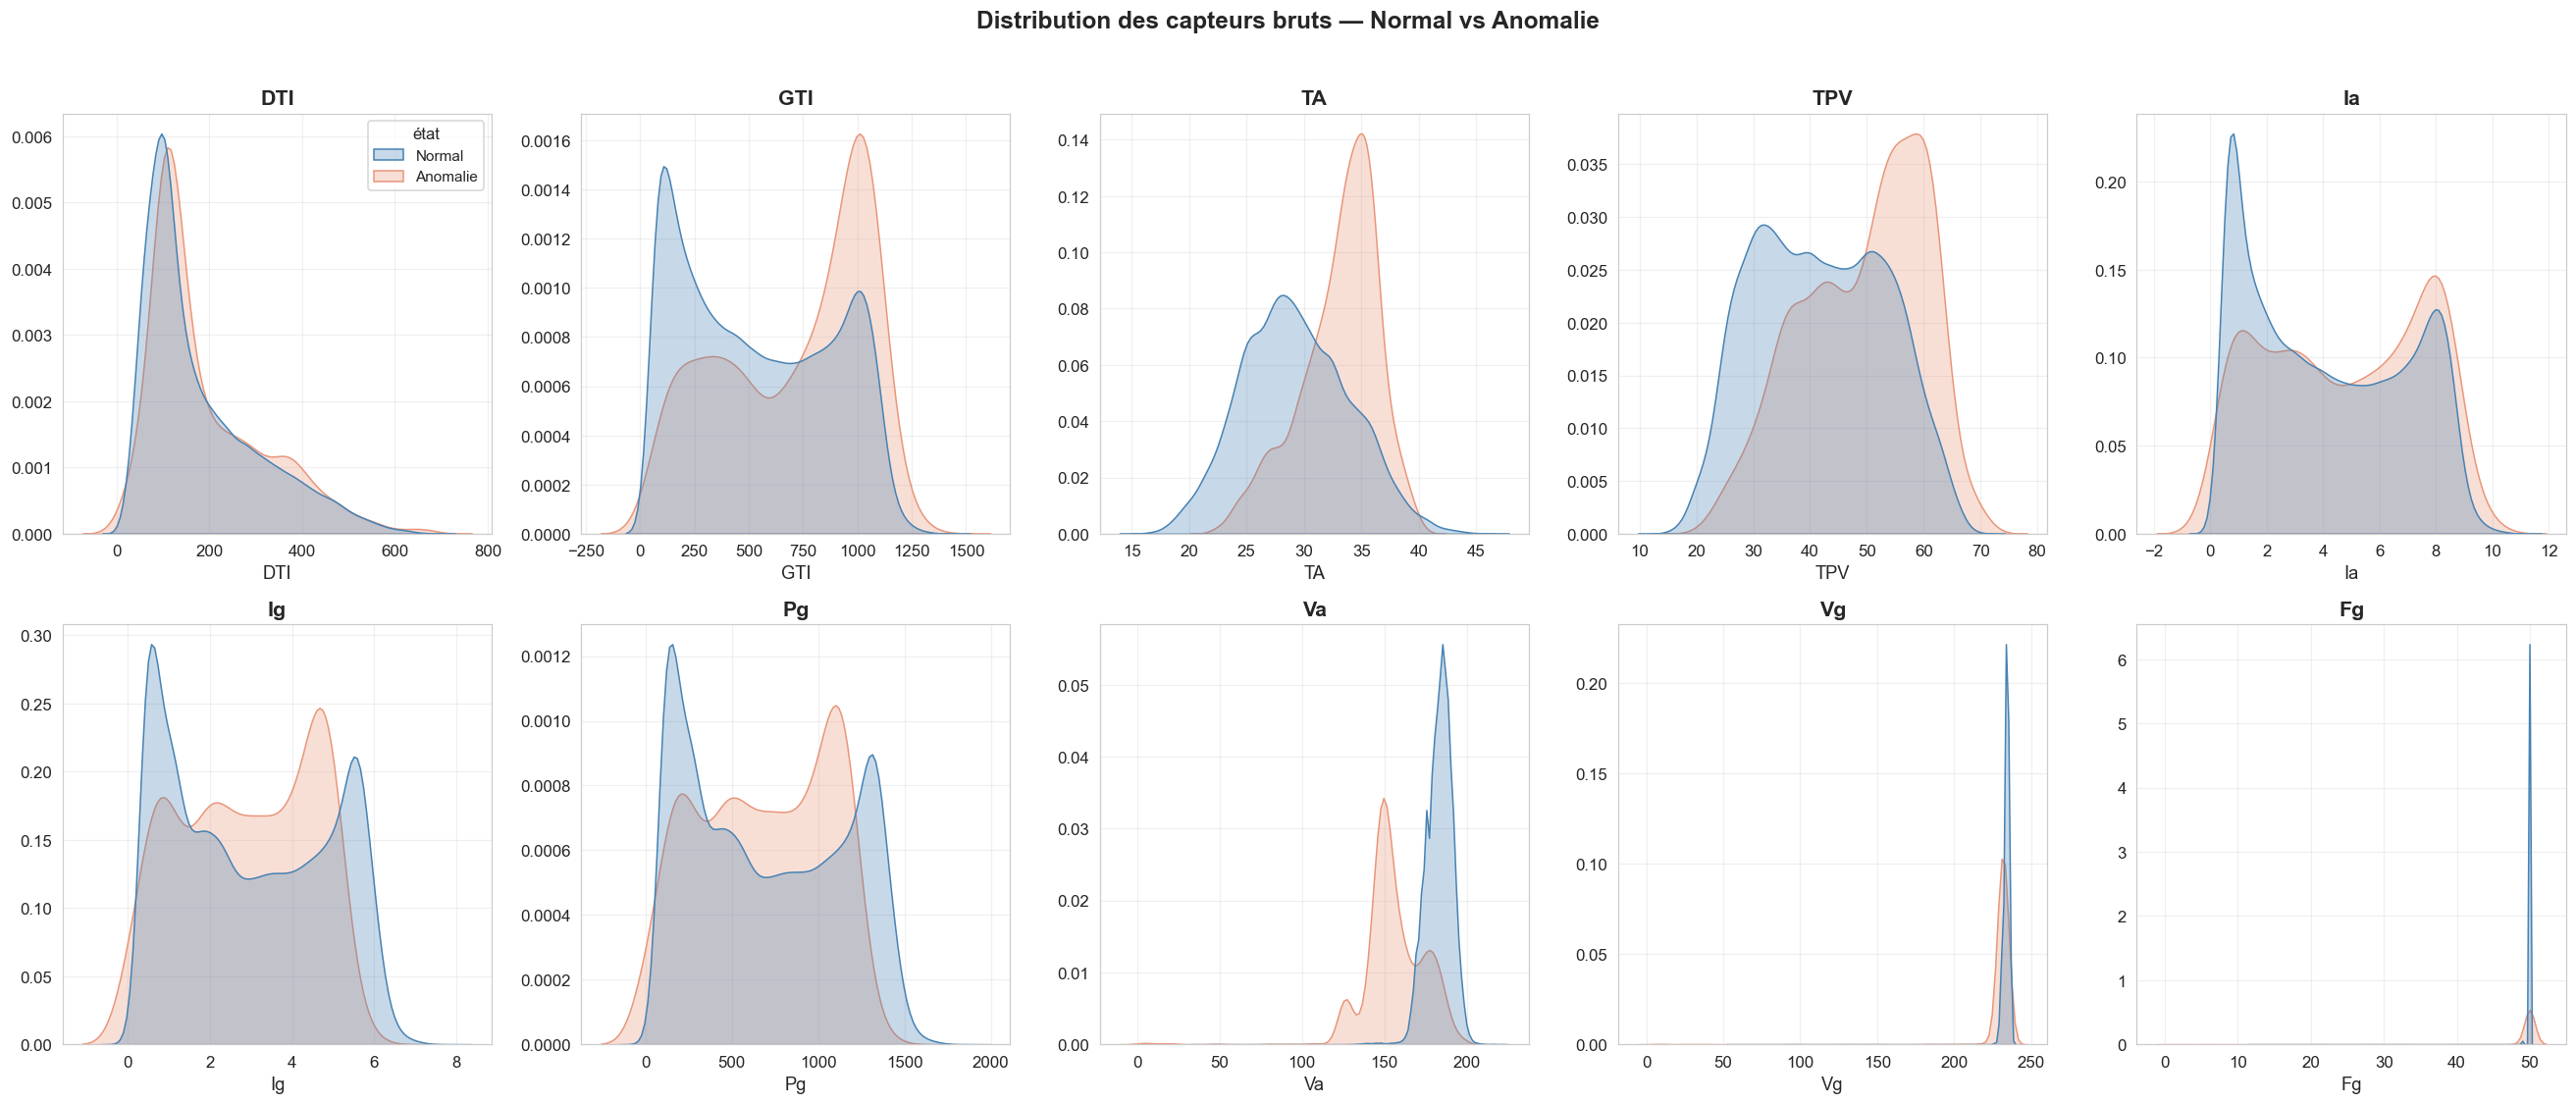

Constat : Va (tension AC) et les courants Ia/Ig montrent un décalage visible
entre normal et anomalie — indices pour le feature engineering (déviation de tension).


In [338]:
PALETTE_BINARY = {"Normal": C_NORMAL, "Anomalie": C_ANO}
HUE_ORDER = ["Normal", "Anomalie"]
CAPS_KDE = ["DTI", "GTI", "TA", "TPV", "Ia", "Ig", "Pg", "Va", "Vg", "Fg"]

# Frame de tracé temporaire — on ne touche PAS à df (voir note ci-dessous)
df_plot = df[CAPS_KDE].copy()
df_plot["état"] = np.where(df["Fault"] != 0, "Anomalie", "Normal")

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(CAPS_KDE):
    sns.kdeplot(data=df_plot, x=col, hue="état",
                hue_order=HUE_ORDER, palette=PALETTE_BINARY,
                fill=True, alpha=0.3, ax=axes[i],
                common_norm=False, warn_singular=False, gridsize=120)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_ylabel("")
    if i > 0 and axes[i].get_legend() is not None:
        axes[i].get_legend().remove()   # une seule légende au lieu de dix

fig.suptitle("Distribution des capteurs bruts — Normal vs Anomalie",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/eda_03_distributions_capteurs.png", dpi=150, bbox_inches="tight")
plt.show()

print("Constat : Va (tension AC) et les courants Ia/Ig montrent un décalage visible")
print("entre normal et anomalie — indices pour le feature engineering (déviation de tension).")

del df_plot

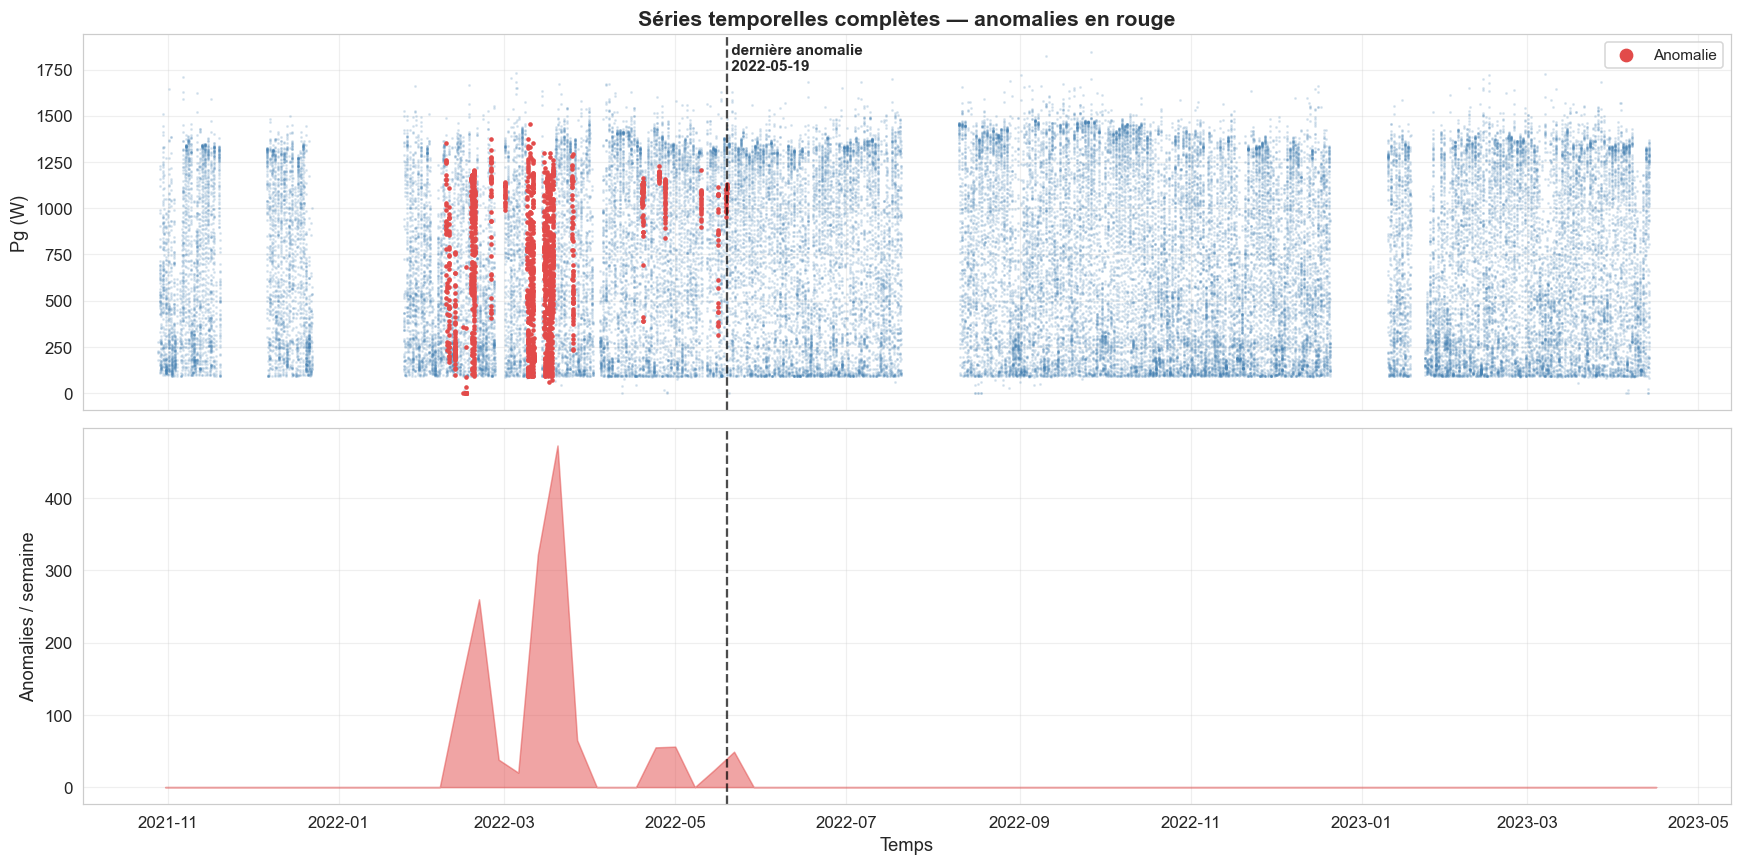

Constat CLÉ : dernière anomalie le 2022-05-19, mais le dataset va jusqu'au
2023-04-13. Soit 35,684 lignes (67%) de normal pur après.
→ Il faut restreindre l'étude à la période contenant des anomalies (df_etude),
  sinon un split naïf placerait tout le test dans la zone sans panne (test vide).


In [331]:
ano = df[df["Fault"] != 0]
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Pg dans le temps, anomalies en rouge
axes[0].scatter(df.index, df["Pg"], s=1, alpha=0.15, c=C_NORMAL)
axes[0].scatter(ano.index, ano["Pg"], s=4, c=C_RED, label="Anomalie")
axes[0].set_ylabel("Pg (W)"); axes[0].legend(markerscale=4)
axes[0].set_title("Séries temporelles complètes — anomalies en rouge", fontweight="bold")

# Densité d'anomalies par semaine
ano_hebdo = (df["Fault"] != 0).resample("W").sum()
axes[1].fill_between(ano_hebdo.index, ano_hebdo.values, color=C_RED, alpha=0.5)
axes[1].set_ylabel("Anomalies / semaine"); axes[1].set_xlabel("Temps")

# Marquer la fin de la période d'anomalies
fin_ano = ano.index.max()
for ax in axes:
    ax.axvline(fin_ano, color="black", ls="--", lw=1.5, alpha=0.7)
axes[0].text(fin_ano, axes[0].get_ylim()[1]*0.9, f" dernière anomalie\n {fin_ano.date()}",
             fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_05_anomalies_temps.png", dpi=150, bbox_inches="tight")
plt.show()

n_apres = len(df[df.index > fin_ano])
print(f"Constat CLÉ : dernière anomalie le {fin_ano.date()}, mais le dataset va jusqu'au")
print(f"{df.index.max().date()}. Soit {n_apres:,} lignes ({100*n_apres/len(df):.0f}%) de normal pur après.")
print("→ Il faut restreindre l'étude à la période contenant des anomalies (df_etude),")
print("  sinon un split naïf placerait tout le test dans la zone sans panne (test vide).")

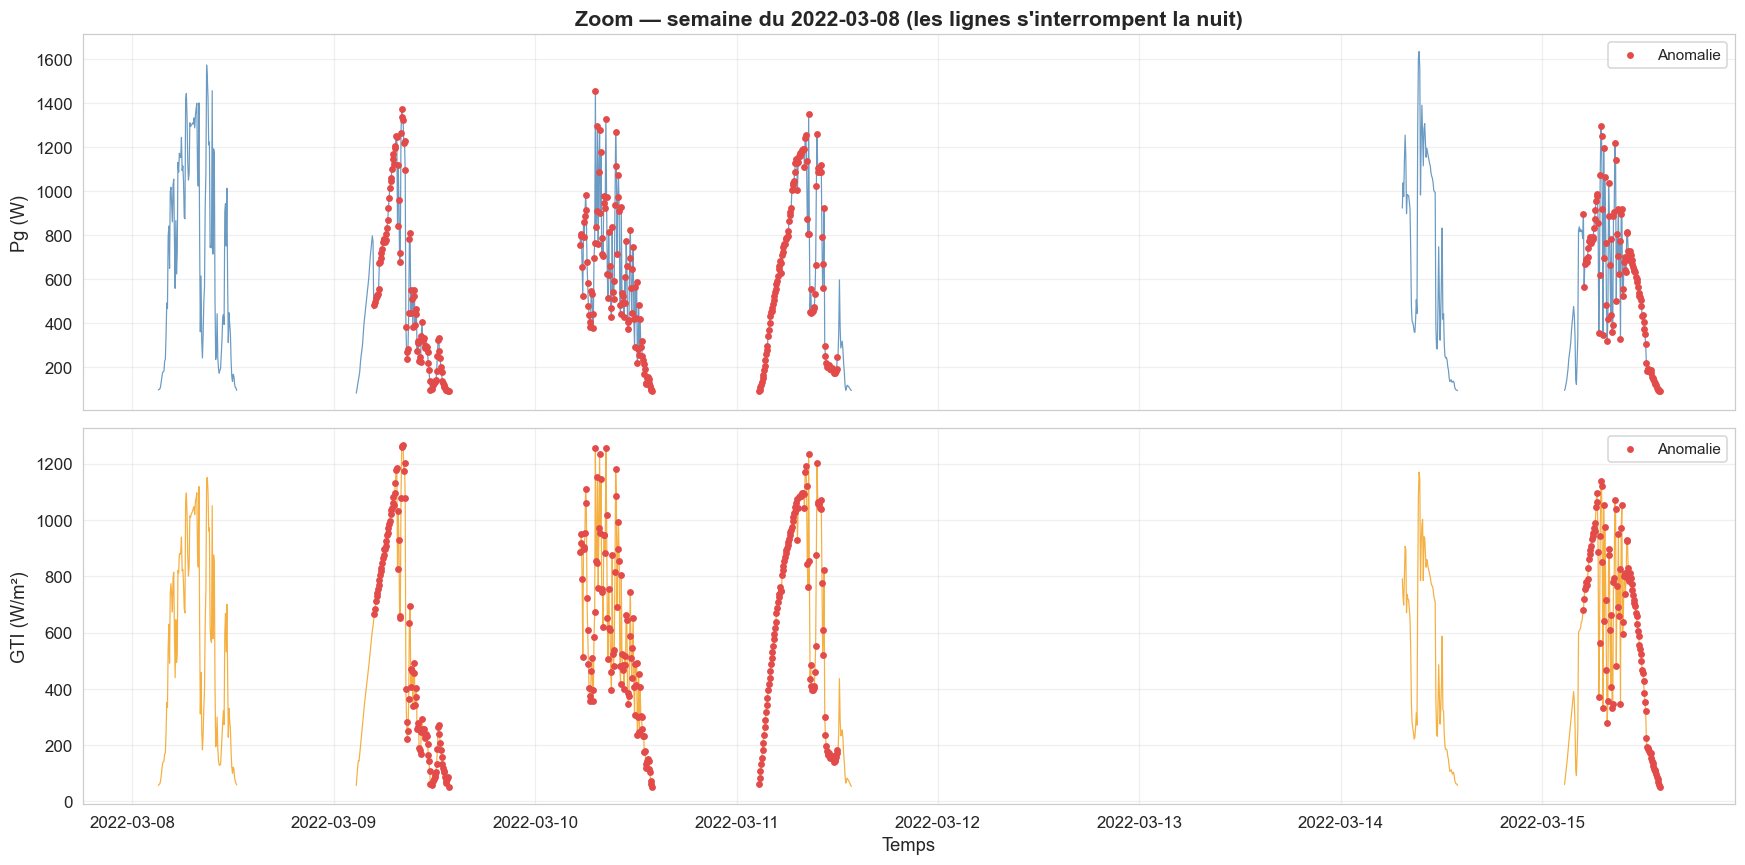

Constat : cycle jour/nuit marqué ; les mesures nocturnes sont absentes (GTI>50).
Les anomalies (rouge) surviennent en journée, souvent en cloche autour de midi.
→ Les séquences temporelles (LSTM) ne devront pas enjamber les nuits.


In [332]:
sem = df["2022-03-08":"2022-03-15"].copy()
# Réindexer sur grille 5 min pour NE PAS relier à travers les nuits
sem_g = sem.asfreq("5min")
ano_sem = sem[sem["Fault"] != 0]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
for ax, (col, ylab, coul) in zip(axes, [("Pg", "Pg (W)", C_NORMAL), ("GTI", "GTI (W/m²)", "#F39C12")]):
    ax.plot(sem_g.index, sem_g[col], "-", color=coul, lw=0.8, alpha=0.8)
    ax.scatter(ano_sem.index, ano_sem[col], s=12, c=C_RED, zorder=3, label="Anomalie")
    ax.set_ylabel(ylab); ax.legend()
axes[0].set_title("Zoom — semaine du 2022-03-08 (les lignes s'interrompent la nuit)", fontweight="bold")
axes[-1].set_xlabel("Temps")
plt.tight_layout()
plt.savefig("figures/eda_06_zoom_semaine.png", dpi=150, bbox_inches="tight")
plt.show()

print("Constat : cycle jour/nuit marqué ; les mesures nocturnes sont absentes (GTI>50).")
print("Les anomalies (rouge) surviennent en journée, souvent en cloche autour de midi.")
print("→ Les séquences temporelles (LSTM) ne devront pas enjamber les nuits.")

C:\Users\PC\AppData\Local\Temp\ipykernel_18932\3526659245.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ano["mois"]  = ano.index.to_period("M").astype(str)


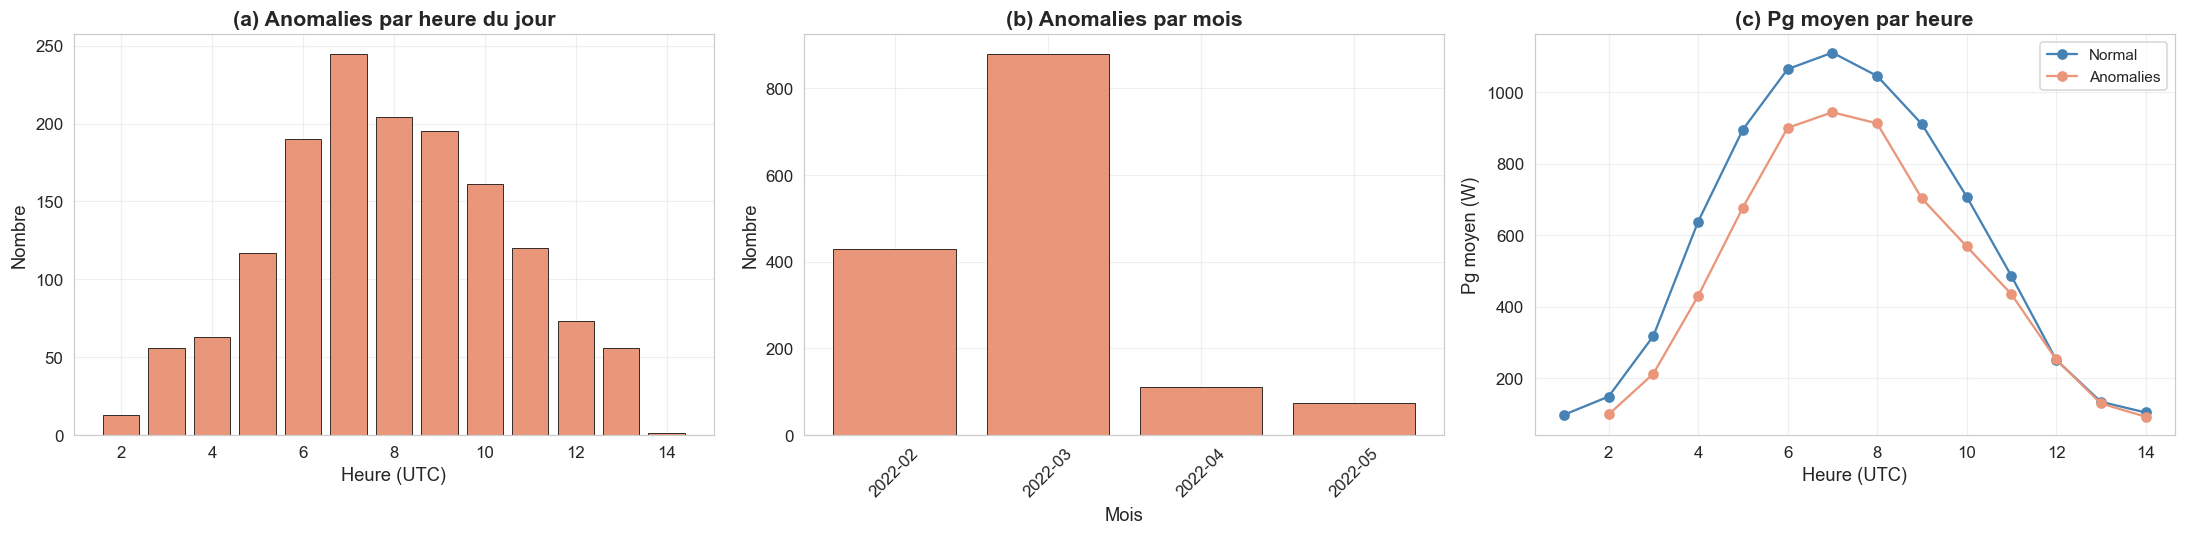

Constat : anomalies concentrées en journée (pic vers 7h UTC) et sur février-mai 2022
(surtout mars). À chaque heure, la Pg des anomalies est SOUS celle du normal :
le déficit de production est constant, ce qui confirme l'intérêt d'un rendement normalisé.


In [333]:
ano = df[df["Fault"] != 0].copy()
ano["heure"] = ano.index.hour
ano["mois"]  = ano.index.to_period("M").astype(str)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# (a) par heure
h = ano["heure"].value_counts().sort_index()
axes[0].bar(h.index, h.values, color=C_ANO, edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Heure (UTC)"); axes[0].set_ylabel("Nombre")
axes[0].set_title("(a) Anomalies par heure du jour", fontweight="bold")

# (b) par mois
m = ano["mois"].value_counts().sort_index()
axes[1].bar(range(len(m)), m.values, color=C_ANO, edgecolor="black", linewidth=0.5)
axes[1].set_xticks(range(len(m))); axes[1].set_xticklabels(m.index, rotation=45)
axes[1].set_xlabel("Mois"); axes[1].set_ylabel("Nombre")
axes[1].set_title("(b) Anomalies par mois", fontweight="bold")

# (c) Pg moyen par heure : normal vs anomalie
prof_n = df[df["Fault"]==0].groupby(df[df["Fault"]==0].index.hour)["Pg"].mean()
prof_a = ano.groupby("heure")["Pg"].mean()
axes[2].plot(prof_n.index, prof_n.values, "o-", color=C_NORMAL, label="Normal")
axes[2].plot(prof_a.index, prof_a.values, "o-", color=C_ANO, label="Anomalies")
axes[2].set_xlabel("Heure (UTC)"); axes[2].set_ylabel("Pg moyen (W)")
axes[2].set_title("(c) Pg moyen par heure", fontweight="bold"); axes[2].legend()

plt.tight_layout()
plt.savefig("figures/eda_07_profils.png", dpi=150, bbox_inches="tight")
plt.show()

print("Constat : anomalies concentrées en journée (pic vers 7h UTC) et sur février-mai 2022")
print("(surtout mars). À chaque heure, la Pg des anomalies est SOUS celle du normal :")
print("le déficit de production est constant, ce qui confirme l'intérêt d'un rendement normalisé.")

## 5.8 Synthèse de l'EDA → transition vers le Feature Engineering

L'exploration des données brutes révèle plusieurs constats qui **motivent directement** les features à créer :

| Constat EDA (données brutes) | Feature dérivée motivée |
|---|---|
| Pg ∝ GTI ; les anomalies produisent moins à irradiance égale | **ratio Pg/GTI** (rendement normalisé par le soleil) |
| Le déficit de production est visible mais dépend du soleil | **pg_residual** (écart à la production attendue) |
| Va (tension AC) décalée entre normal et anomalie | **va_deviation** (déviation de tension) |
| Va anti-corrélée au soleil, Vg au réseau | **vg_va_ratio** (déséquilibre de tension) |
| Anomalies concentrées fév–mai 2022, rien après | restriction à la **période d'étude** (df_etude) |
| Trous nocturnes (GTI>50) | séquences LSTM **respectant les journées** |
| Fort déséquilibre (~2.8% d'anomalies) | métrique **PR-AUC**, approche **non supervisée** |

La section suivante construit et valide ces features.

---
## 4. Feature Engineering
---

### 4.1 Phase 1 — Indicateurs physiques de base

4 features capturant des comportements physiques utiles pour la détection d'anomalies.

In [225]:
# =============================================================
# 4.1bis — Validation des features Phase 1 par pouvoir discriminant
# =============================================================
# Les 4 features Phase 1 ont été créées sur base physique. Comme en Phase 2,
# on les VALIDE par un test de Kolmogorov-Smirnov (séparation normal/anomalie)
# AVANT de les retenir — un ajout intuitif n'est pas une justification.
from scipy.stats import ks_2samp

sain_ = df_etude[df_etude["Fault"] == 0]
ano_  = df_etude[df_etude["Fault"] != 0]

FEATURES_PHASE1_CANDIDATES = ["ratio_pg_gti", "delta_tpv_ta", "pg_diff", "ratio_std_30min"]

print("Pouvoir discriminant des candidates Phase 1 (KS normal vs anomalie)\n")
print(f"{'Feature':<18}{'KS':>8}{'KS sur Fault 3':>16}   décision")
SEUIL_KS = 0.35
FEATURES_PHASE1 = []
f3_ = df_etude[df_etude["Fault"].isin([3.1, 3.2])]
for f in FEATURES_PHASE1_CANDIDATES:
    ks     = ks_2samp(sain_[f].dropna(), ano_[f].dropna()).statistic
    ks_f3  = ks_2samp(sain_[f].dropna(), f3_[f].dropna()).statistic
    garde  = ks >= SEUIL_KS
    if garde:
        FEATURES_PHASE1.append(f)
    print(f"{f:<18}{ks:>8.2f}{ks_f3:>16.2f}   {'RETENUE' if garde else 'écartée (KS trop faible)'}")

print(f"\nSeuil KS = {SEUIL_KS}")


Pouvoir discriminant des candidates Phase 1 (KS normal vs anomalie)

Feature                 KS  KS sur Fault 3   décision
ratio_pg_gti          0.82            0.83   RETENUE
delta_tpv_ta          0.17            0.23   écartée (KS trop faible)
pg_diff               0.10            0.31   écartée (KS trop faible)
ratio_std_30min       0.09            0.27   écartée (KS trop faible)

Seuil KS = 0.35


Phase 1 retenue : {FEATURES_PHASE1} 

→ delta_tpv_ta, pg_diff, ratio_std_30min écartées : elles ne séparent

pas le normal des anomalies (KS < 0.35) et dégradent le PR-AUC de l'IF.

### 4.1.1 t-SNE AVANT enrichissement (Phase 1 — 11 variables)

Vérifier la séparabilité des anomalies avec les features de Phase 1 uniquement.

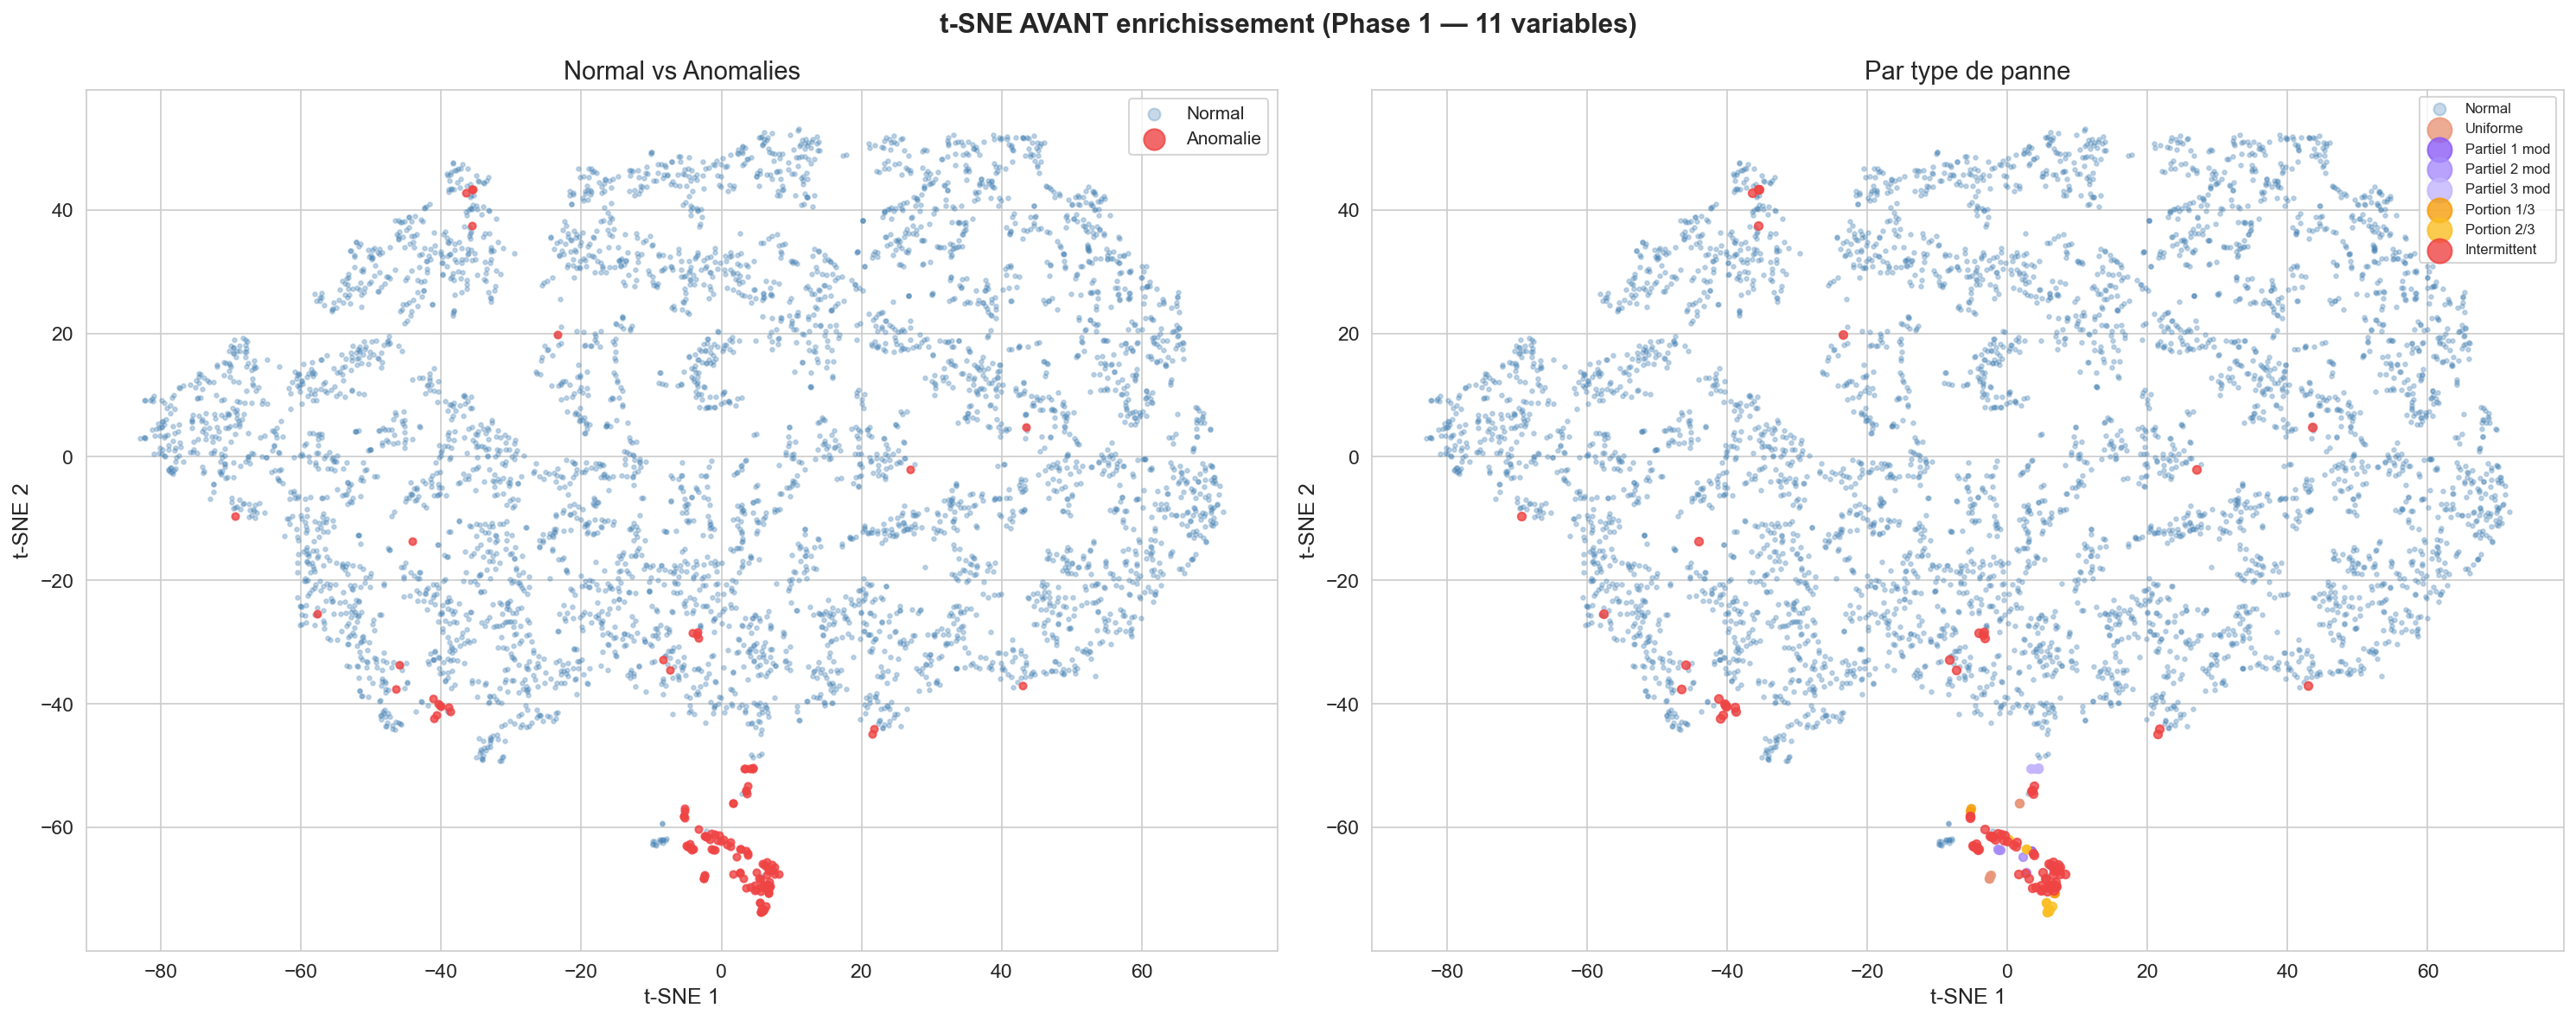

In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
FEATURES_CAPTEURS   = ["DTI", "GTI", "TA", "TPV", "Ia", "Ig", "Pg", "Va", "Vg", "Fg"]
tsne_features_v1 = FEATURES_CAPTEURS + FEATURES_PHASE1
X_sample = sample[tsne_features_v1].dropna()
sample_clean = sample.loc[X_sample.index]

X_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(
    StandardScaler().fit_transform(X_sample)
)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("t-SNE AVANT enrichissement (Phase 1 — 11 variables)", fontsize=15, fontweight="bold")

COLORS_TSNE = {0.0: "#4682B4", 1.0: "#E9967A", 2.1: "#8B5CF6", 2.2: "#A78BFA",
               2.3: "#C4B5FD", 3.1: "#F59E0B", 3.2: "#FBBF24", 4.0: "#EF4444"}
LABELS_TSNE = {0.0: "Normal", 1.0: "Uniforme", 2.1: "Partiel 1 mod",
               2.2: "Partiel 2 mod", 2.3: "Partiel 3 mod",
               3.1: "Portion 1/3", 3.2: "Portion 2/3", 4.0: "Intermittent"}

# (a) Normal vs Anomalies
mask_n = sample_clean["Fault"] == 0
axes[0].scatter(X_2d[mask_n, 0], X_2d[mask_n, 1], alpha=0.3, s=5, c="#4682B4", label="Normal")
axes[0].scatter(X_2d[~mask_n, 0], X_2d[~mask_n, 1], alpha=0.8, s=15, c="#EF4444", label="Anomalie")
axes[0].set_title("Normal vs Anomalies")
axes[0].legend(markerscale=3)
axes[0].set_xlabel("t-SNE 1"); axes[0].set_ylabel("t-SNE 2")

# (b) Par type de panne
for fv in sorted(sample_clean["Fault"].unique()):
    m = sample_clean["Fault"] == fv
    axes[1].scatter(X_2d[m, 0], X_2d[m, 1],
                    alpha=0.3 if fv == 0 else 0.8, s=5 if fv == 0 else 20,
                    c=COLORS_TSNE.get(fv, "gray"), label=LABELS_TSNE.get(fv, f"Fault {fv}"))
axes[1].set_title("Par type de panne")
axes[1].legend(markerscale=3, fontsize=8)
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


---
### 4.2 Phase 2 — Recherche de features pour les pannes subtiles (Fault 3)

Fault 3 (ombrage partiel d'une portion de module) est le type le plus difficile à détecter.

**Démarche :** créer 6 features candidates → évaluer le pouvoir de séparation (test KS) → vérifier la redondance → ne retenir que les meilleures.

#### 4.2.1 Création des 7 features candidates

In [245]:
from sklearn.linear_model import LinearRegression
from scipy import stats

# Sous-ensembles de référence
normal  = df[df["Fault"] == 0.0]
fault3  = df[(df["Fault"] >= 3.0) & (df["Fault"] < 4.0)]
fault31 = df[df["Fault"] == 3.1]
fault32 = df[df["Fault"] == 3.2]

print(f"Normal  : {len(normal):,} lignes")
print(f"Fault 3 : {len(fault3):,} lignes  (3.1 = {len(fault31)}, 3.2 = {len(fault32)})")

# === 6 candidates ===
CANDIDATES = {}

# C1. Résidu de la régression GTI → Pg
lr = LinearRegression().fit(normal[["GTI"]], normal["Pg"])
CANDIDATES["pg_residual"] = df["Pg"] - lr.predict(df[["GTI"]])

# C2. Déviation de Va par rapport à la médiane normale
CANDIDATES["va_deviation"] = (df["Va"] - normal["Va"].median()).abs()

# C3. Efficacité corrigée par la température
CANDIDATES["efficiency_corrigee"] = df["Pg"] / (df["GTI"] * (1 - 0.004 * (df["TPV"] - 25))).replace(0, np.nan)

# C4. Ratio Ia / GTI
CANDIDATES["ratio_ia_gti"] = df["Ia"] / df["GTI"].replace(0, np.nan)

# C5. Moyenne glissante du ratio sur 1h
CANDIDATES["ratio_mean_1h"] = df["ratio_pg_gti"].rolling(12).mean()

# C6. Déviation locale
CANDIDATES["ratio_local_dev"] = df["ratio_pg_gti"] - CANDIDATES["ratio_mean_1h"]

CANDIDATES["vg_va_ratio"] = df["Vg"] / df["Va"].replace(0, np.nan)

# Ajouter temporairement au DataFrame pour les visualisations
for name, series in CANDIDATES.items():
    df[name] = series

# Recalculer les sous-ensembles avec les nouvelles colonnes
normal  = df[df["Fault"] == 0.0]
fault3  = df[(df["Fault"] >= 3.0) & (df["Fault"] < 4.0)]
fault31 = df[df["Fault"] == 3.1]
fault32 = df[df["Fault"] == 3.2]

CANDIDATE_NAMES = list(CANDIDATES.keys())
print(f"\n7 candidates créées : {CANDIDATE_NAMES}")

Normal  : 51,465 lignes
Fault 3 : 187 lignes  (3.1 = 73, 3.2 = 114)

7 candidates créées : ['pg_residual', 'va_deviation', 'efficiency_corrigee', 'ratio_ia_gti', 'ratio_mean_1h', 'ratio_local_dev', 'vg_va_ratio']


#### 4.2.2 Test de Kolmogorov-Smirnov — Classement du pouvoir de séparation

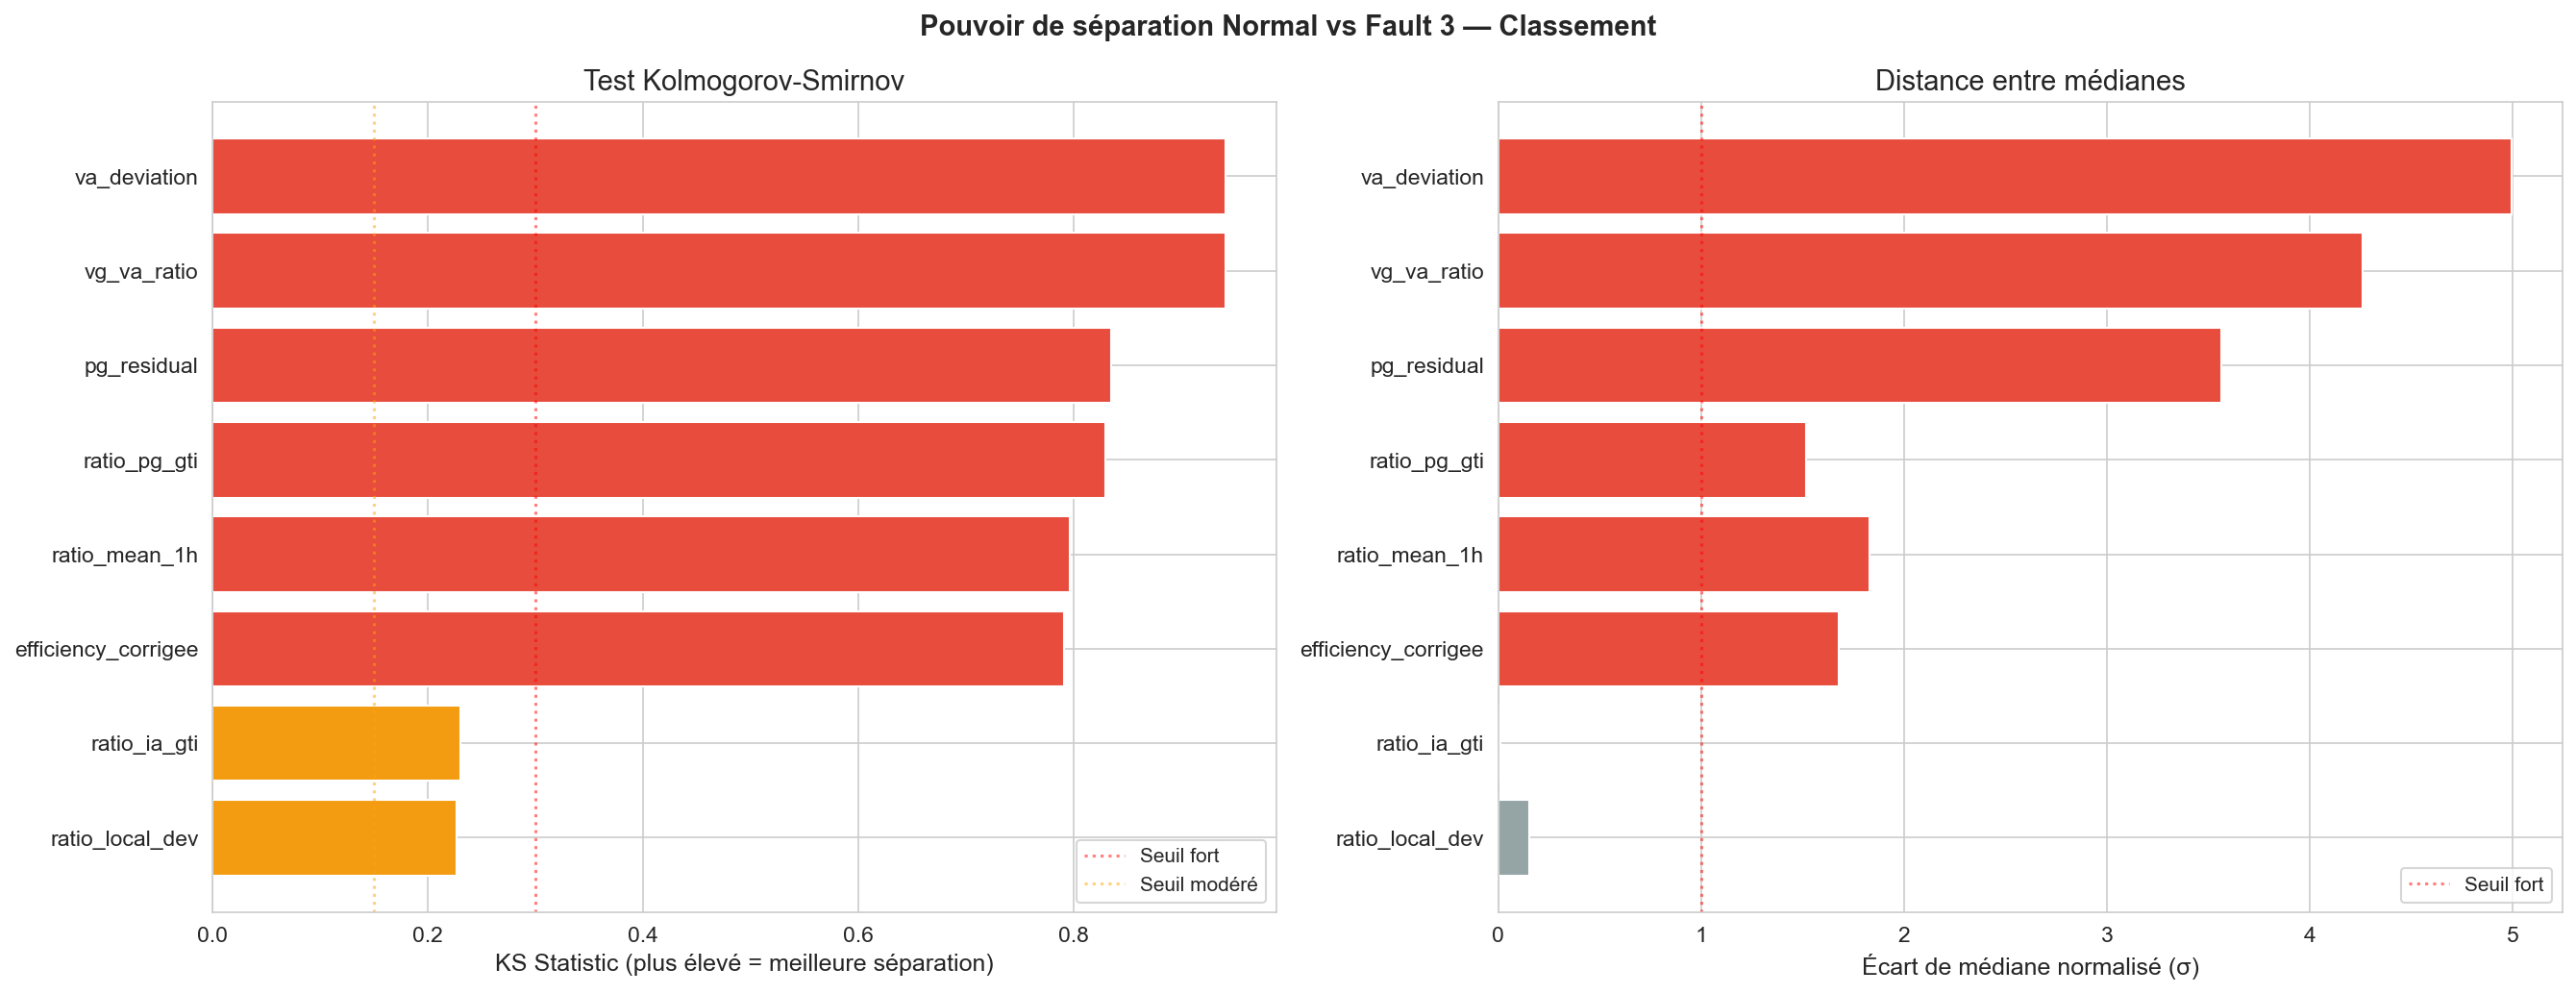


Classement :
            Feature    KS  Écart méd. (σ)
       va_deviation 0.941           4.993
        vg_va_ratio 0.941           4.262
        pg_residual 0.835           3.564
       ratio_pg_gti 0.829           1.516
      ratio_mean_1h 0.796           1.828
efficiency_corrigee 0.791           1.677
       ratio_ia_gti 0.230           0.013
    ratio_local_dev 0.227           0.152


In [246]:
all_test = FEATURES_PHASE1 + CANDIDATE_NAMES

results = []
for feat in all_test:
    n_data = normal[feat].dropna()
    f_data = fault3[feat].dropna()
    ks_stat, _ = stats.ks_2samp(n_data, f_data)
    ecart_med = abs(n_data.median() - f_data.median()) / n_data.std()
    results.append({"Feature": feat, "KS": round(ks_stat, 3), "Écart méd. (σ)": round(ecart_med, 3)})

df_ks = pd.DataFrame(results).sort_values("KS", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Pouvoir de séparation Normal vs Fault 3 — Classement", fontsize=14, fontweight="bold")

colors_ks = ["#E74C3C" if x > 0.3 else "#F39C12" if x > 0.15 else "#95A5A6" for x in df_ks["KS"]]
axes[0].barh(df_ks["Feature"], df_ks["KS"], color=colors_ks)
axes[0].set_xlabel("KS Statistic (plus élevé = meilleure séparation)")
axes[0].set_title("Test Kolmogorov-Smirnov")
axes[0].axvline(0.3, color="red", linestyle=":", alpha=0.5, label="Seuil fort")
axes[0].axvline(0.15, color="orange", linestyle=":", alpha=0.5, label="Seuil modéré")
axes[0].legend(); axes[0].invert_yaxis()

colors_med = ["#E74C3C" if x > 1.0 else "#F39C12" if x > 0.5 else "#95A5A6" for x in df_ks["Écart méd. (σ)"]]
axes[1].barh(df_ks["Feature"], df_ks["Écart méd. (σ)"], color=colors_med)
axes[1].set_xlabel("Écart de médiane normalisé (σ)")
axes[1].set_title("Distance entre médianes")
axes[1].axvline(1.0, color="red", linestyle=":", alpha=0.5, label="Seuil fort")
axes[1].legend(); axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("figures/fig_fe_01_ks_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nClassement :")
print(df_ks.to_string(index=False))

#### 4.2.3 Distributions — Normal vs Fault 3 pour chaque candidate

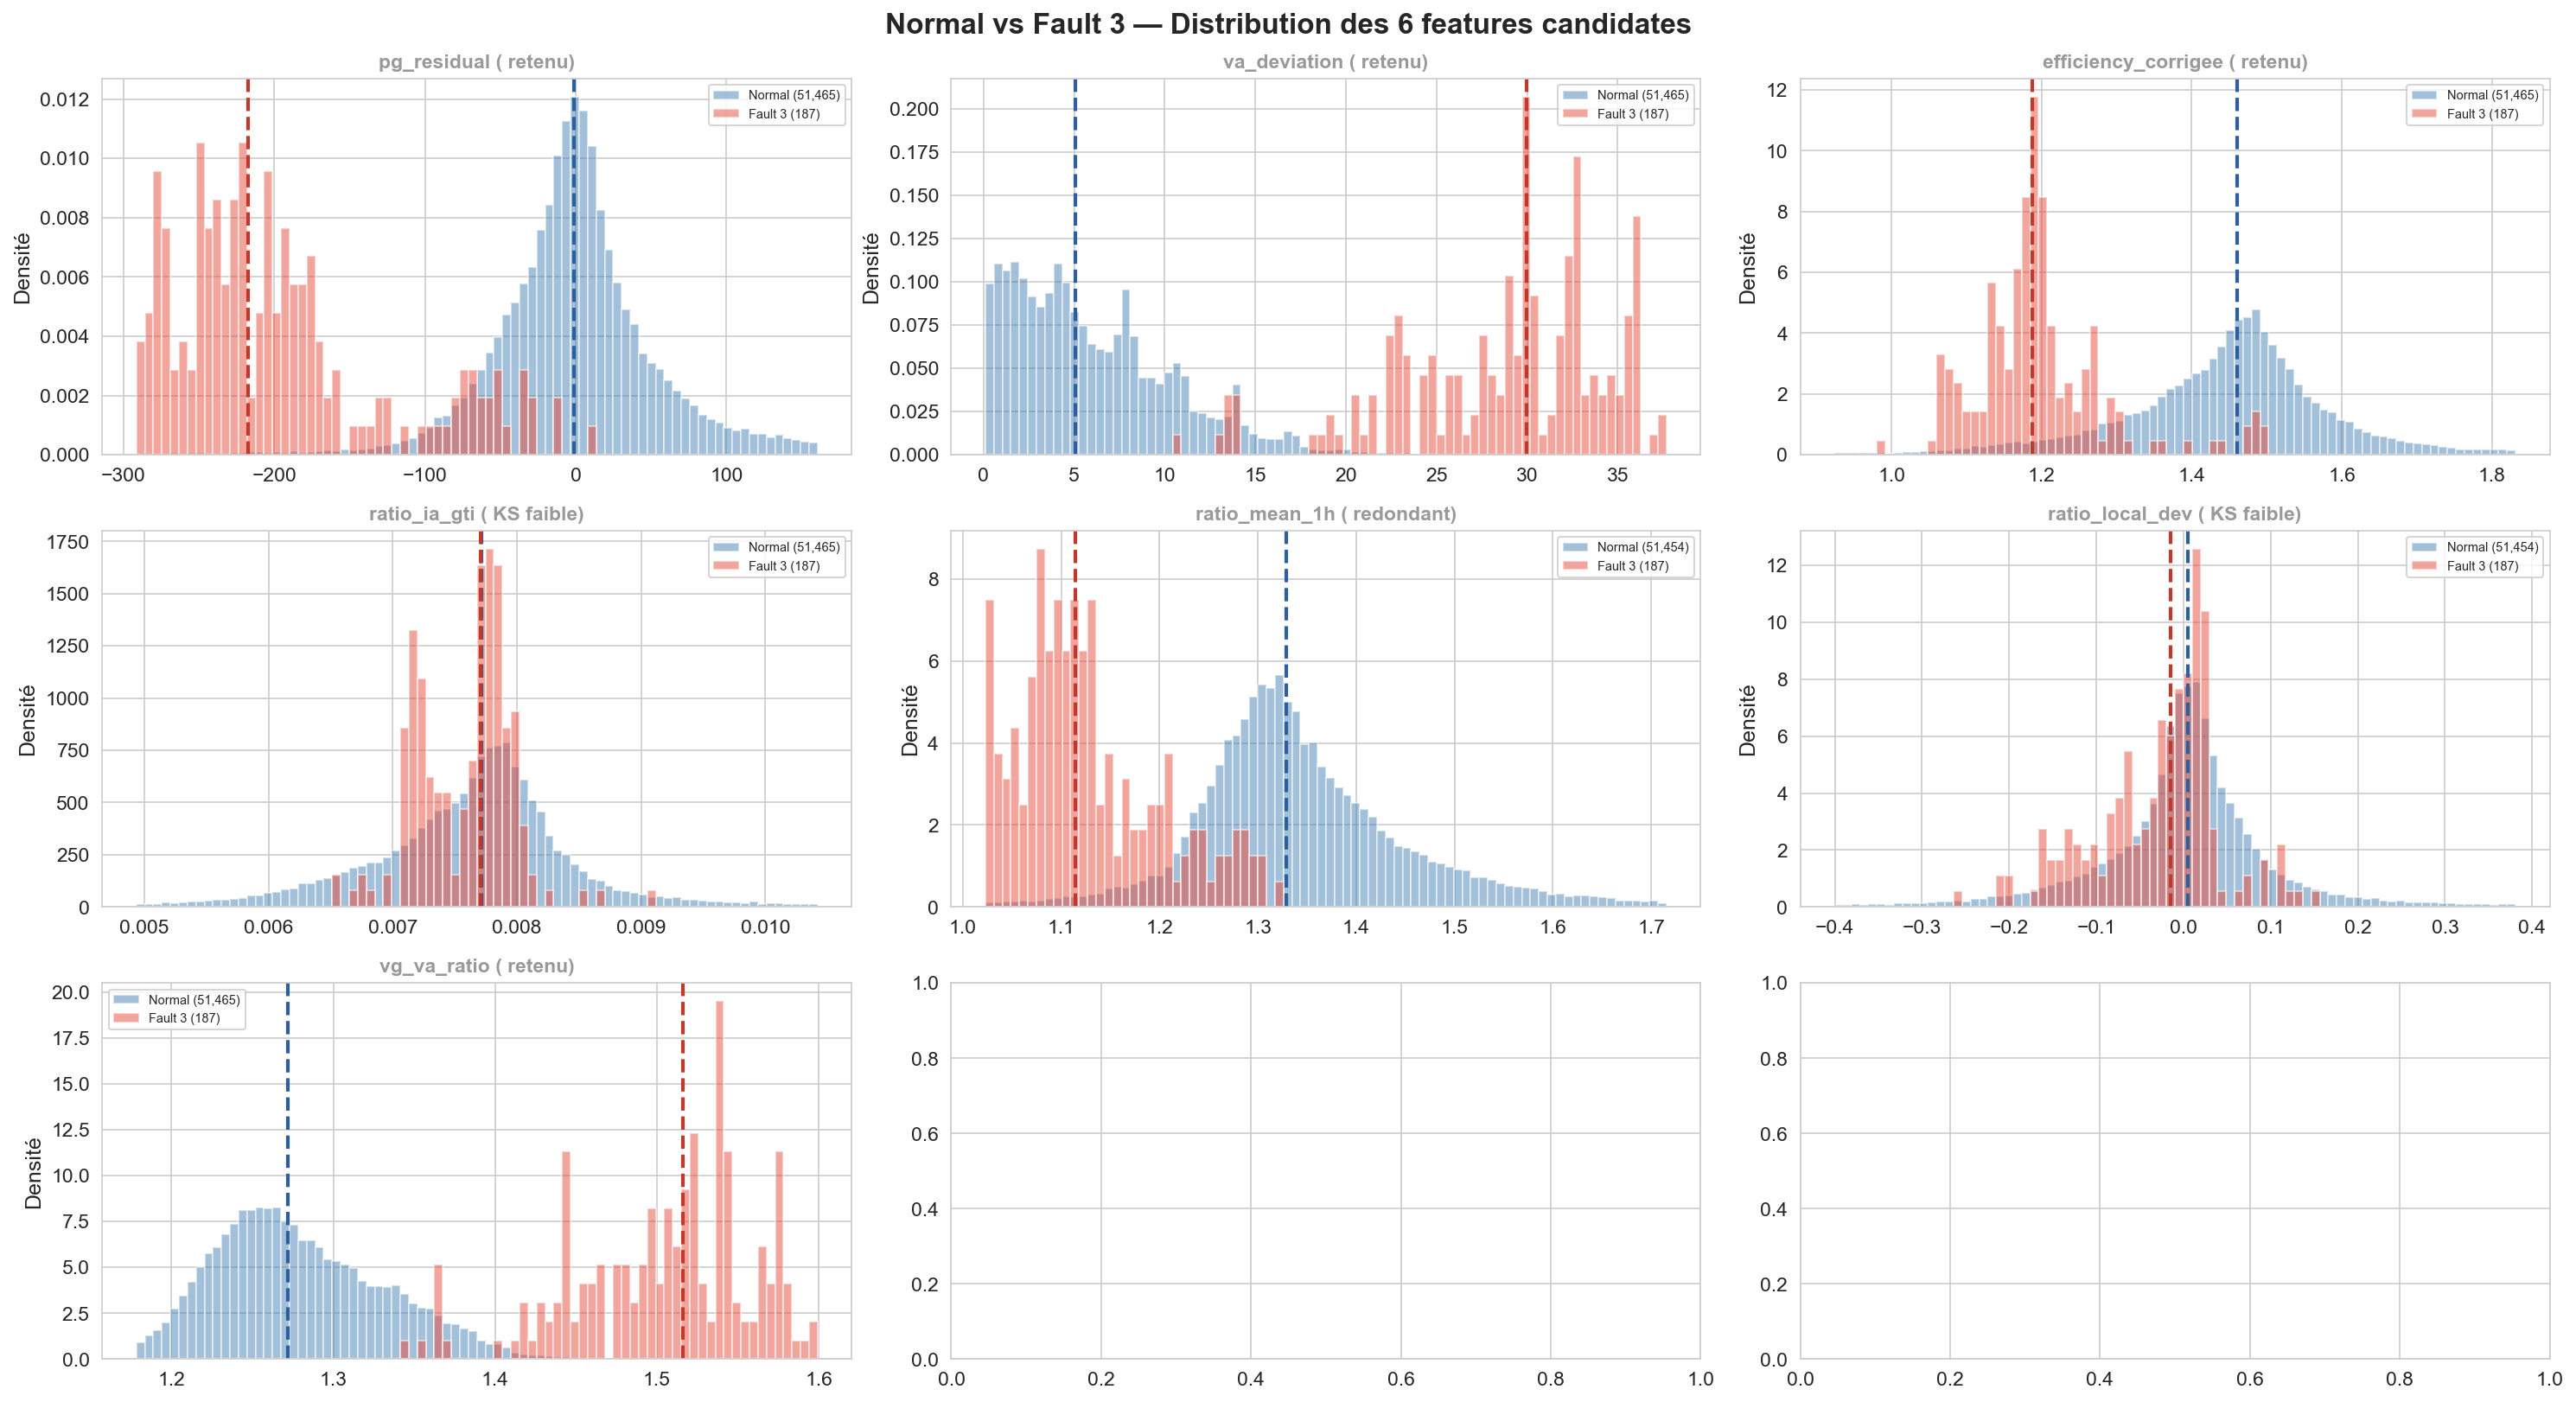

Ligne du haut : décalage net → retenues
Ligne du bas : chevauchement trop important → écartées


In [249]:
fig, axes = plt.subplots(3, 3, figsize=(20, 11))
fig.suptitle("Normal vs Fault 3 — Distribution des 6 features candidates", fontsize=16, fontweight="bold")

plot_info = [
    ("pg_residual",         "pg_residual ( retenu)"),
    ("va_deviation",        "va_deviation ( retenu)"),
    ("efficiency_corrigee", "efficiency_corrigee ( retenu)"),
    ("ratio_ia_gti",        "ratio_ia_gti ( KS faible)"),
    ("ratio_mean_1h",       "ratio_mean_1h ( redondant)"),
    ("ratio_local_dev",     "ratio_local_dev ( KS faible)"),
    ("vg_va_ratio",          "vg_va_ratio ( retenu)")
]

for ax, (col, title) in zip(axes.flatten(), plot_info):
    data_n = normal[col].dropna()
    data_f = fault3[col].dropna()
    low = min(data_n.quantile(0.01), data_f.quantile(0.01))
    high = max(data_n.quantile(0.99), data_f.quantile(0.99))

    ax.hist(data_n, bins=80, range=(low, high), density=True, alpha=0.5, color="#4682B4", label=f"Normal ({len(data_n):,})")
    ax.hist(data_f, bins=80, range=(low, high), density=True, alpha=0.5, color="#E74C3C", label=f"Fault 3 ({len(data_f):,})")
    ax.axvline(data_n.median(), color="#2C5F9E", linestyle="--", linewidth=2)
    ax.axvline(data_f.median(), color="#C0392B", linestyle="--", linewidth=2)

    ax.set_title(title, fontsize=11, fontweight="bold", color="#2C5F9E" if "✅" in title else "#999")
    ax.legend(fontsize=7); ax.set_ylabel("Densité")

plt.tight_layout()
plt.savefig("figures/fig_fe_02_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ligne du haut : décalage net → retenues")
print("Ligne du bas : chevauchement trop important → écartées")

#### 4.2.4 Vérification de redondance — Matrice de corrélation


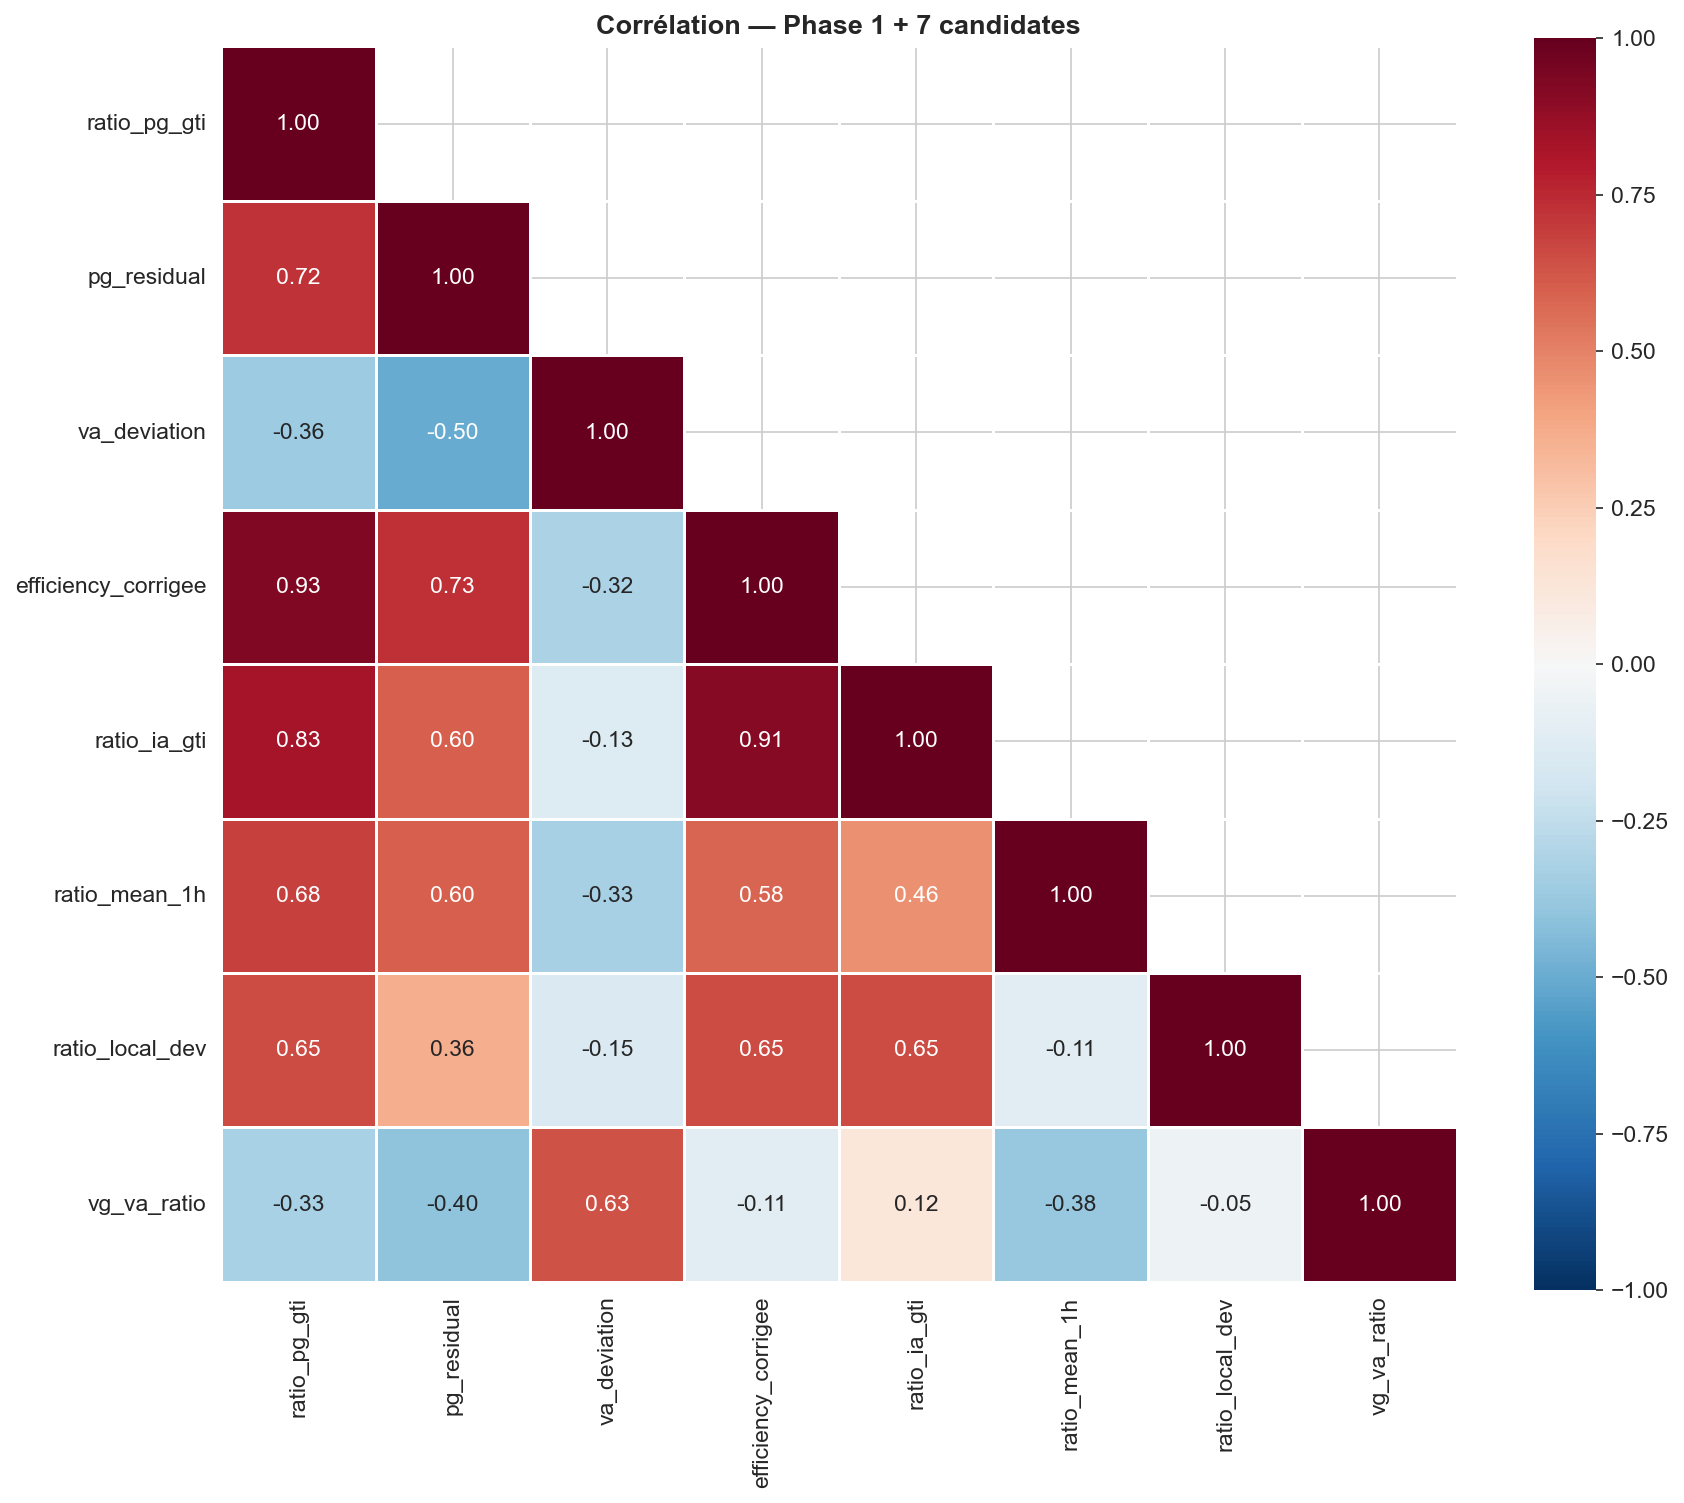

In [272]:
import seaborn as sns

corr_cols = FEATURES_PHASE1 + CANDIDATE_NAMES
corr_check = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_check, dtype=bool), k=1)
sns.heatmap(corr_check, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            mask=mask, square=True, ax=ax, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title("Corrélation — Phase 1 + 7 candidates", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig_fe_03_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


#### 4.2.5 Scatter plots — Fault 3.1 vs 3.2 dans l'espace des candidates retenues


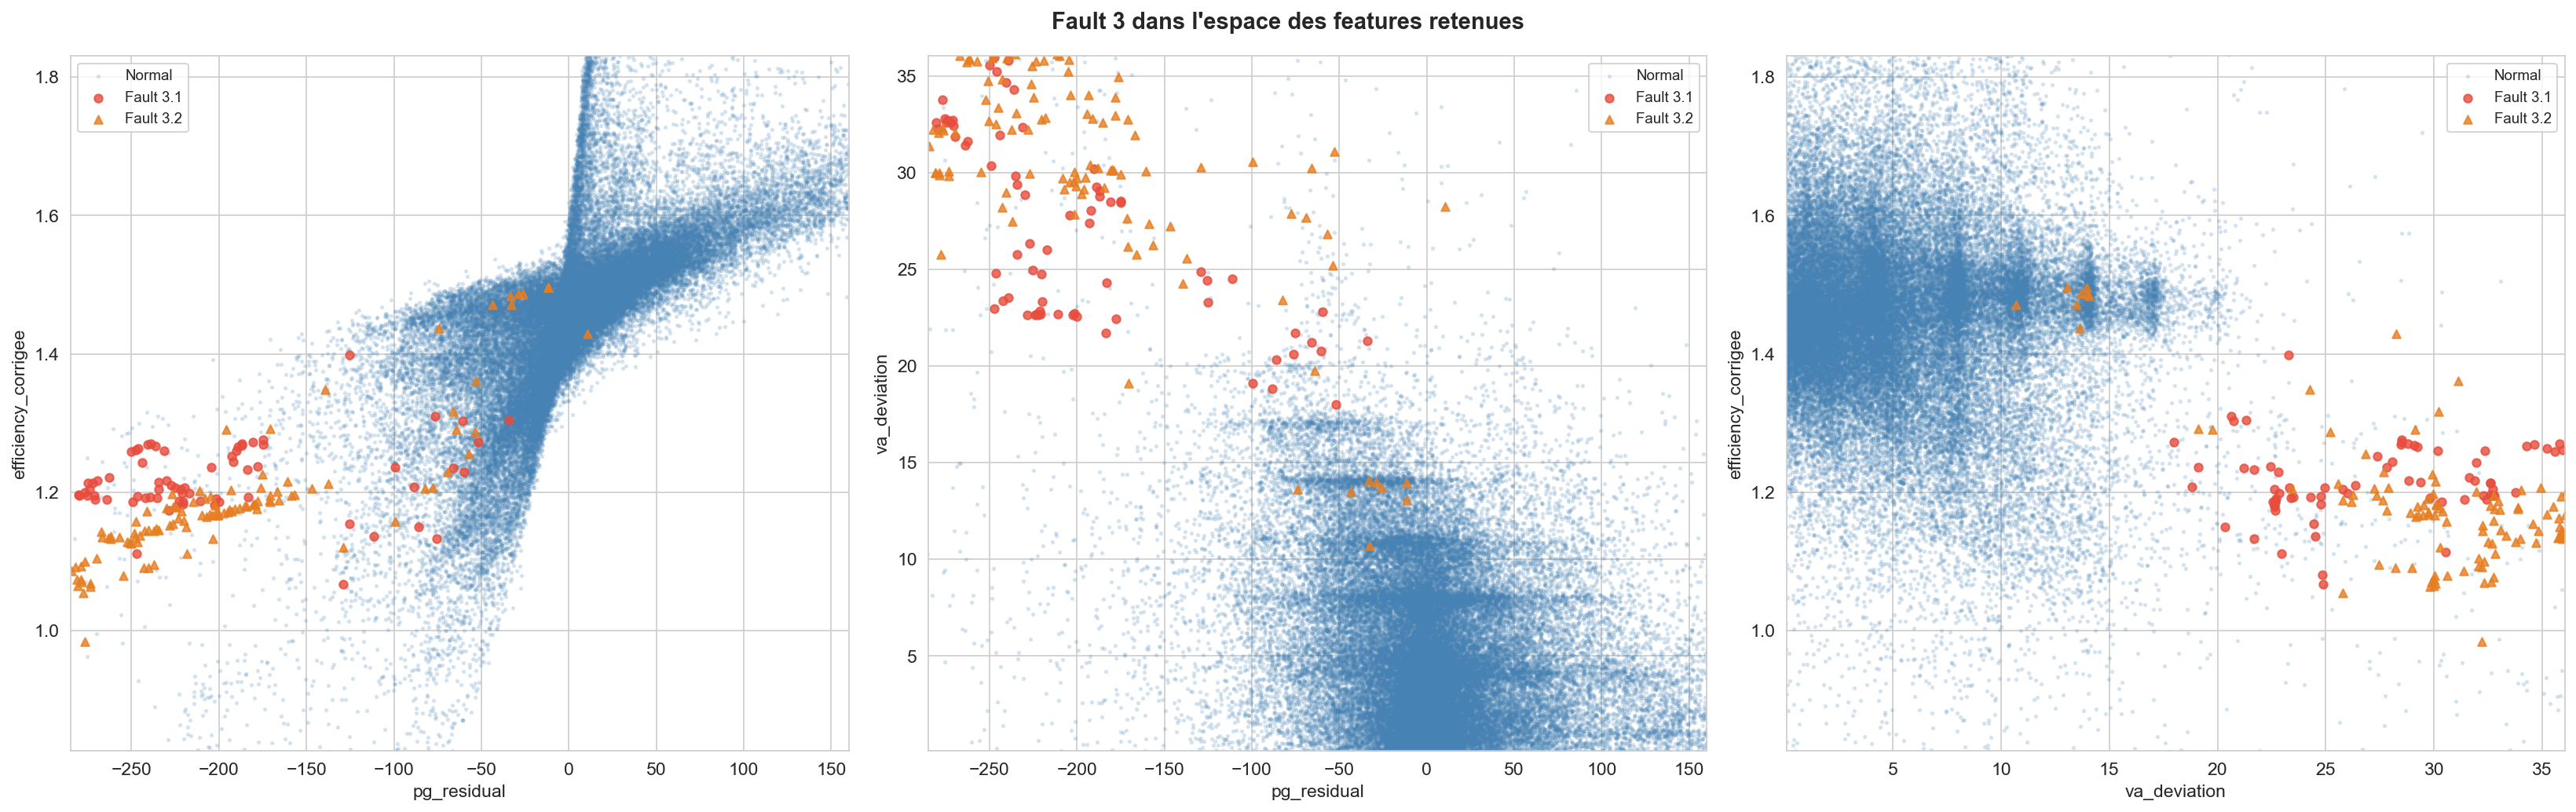

In [251]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Fault 3 dans l'espace des features retenues", fontsize=14, fontweight="bold")

pairs = [
    ("pg_residual", "efficiency_corrigee"),
    ("pg_residual", "va_deviation"),
    ("va_deviation", "efficiency_corrigee"),
]

for ax, (fx, fy) in zip(axes, pairs):
    ax.scatter(normal[fx], normal[fy], s=3, alpha=0.15, c="#4682B4", label="Normal")
    ax.scatter(fault31[fx], fault31[fy], s=25, alpha=0.8, c="#E74C3C", label="Fault 3.1", marker="o")
    ax.scatter(fault32[fx], fault32[fy], s=25, alpha=0.8, c="#E67E22", label="Fault 3.2", marker="^")
    ax.set_xlim(df[fx].quantile(0.01), df[fx].quantile(0.99))
    ax.set_ylim(df[fy].quantile(0.01), df[fy].quantile(0.99))
    ax.set_xlabel(fx, fontsize=11); ax.set_ylabel(fy, fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

#### 4.2.6 Boxplots — Normal vs Fault 3.1 vs Fault 3.2


C:\Users\PC\AppData\Local\Temp\ipykernel_18932\3471573292.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)
C:\Users\PC\AppData\Local\Temp\ipykernel_18932\3471573292.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)
C:\Users\PC\AppData\Local\Temp\ipykernel_18932\3471573292.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)
C:\Users\PC\AppData\Local\Temp\ipykernel_18932\3471573292.py:14: Matpl

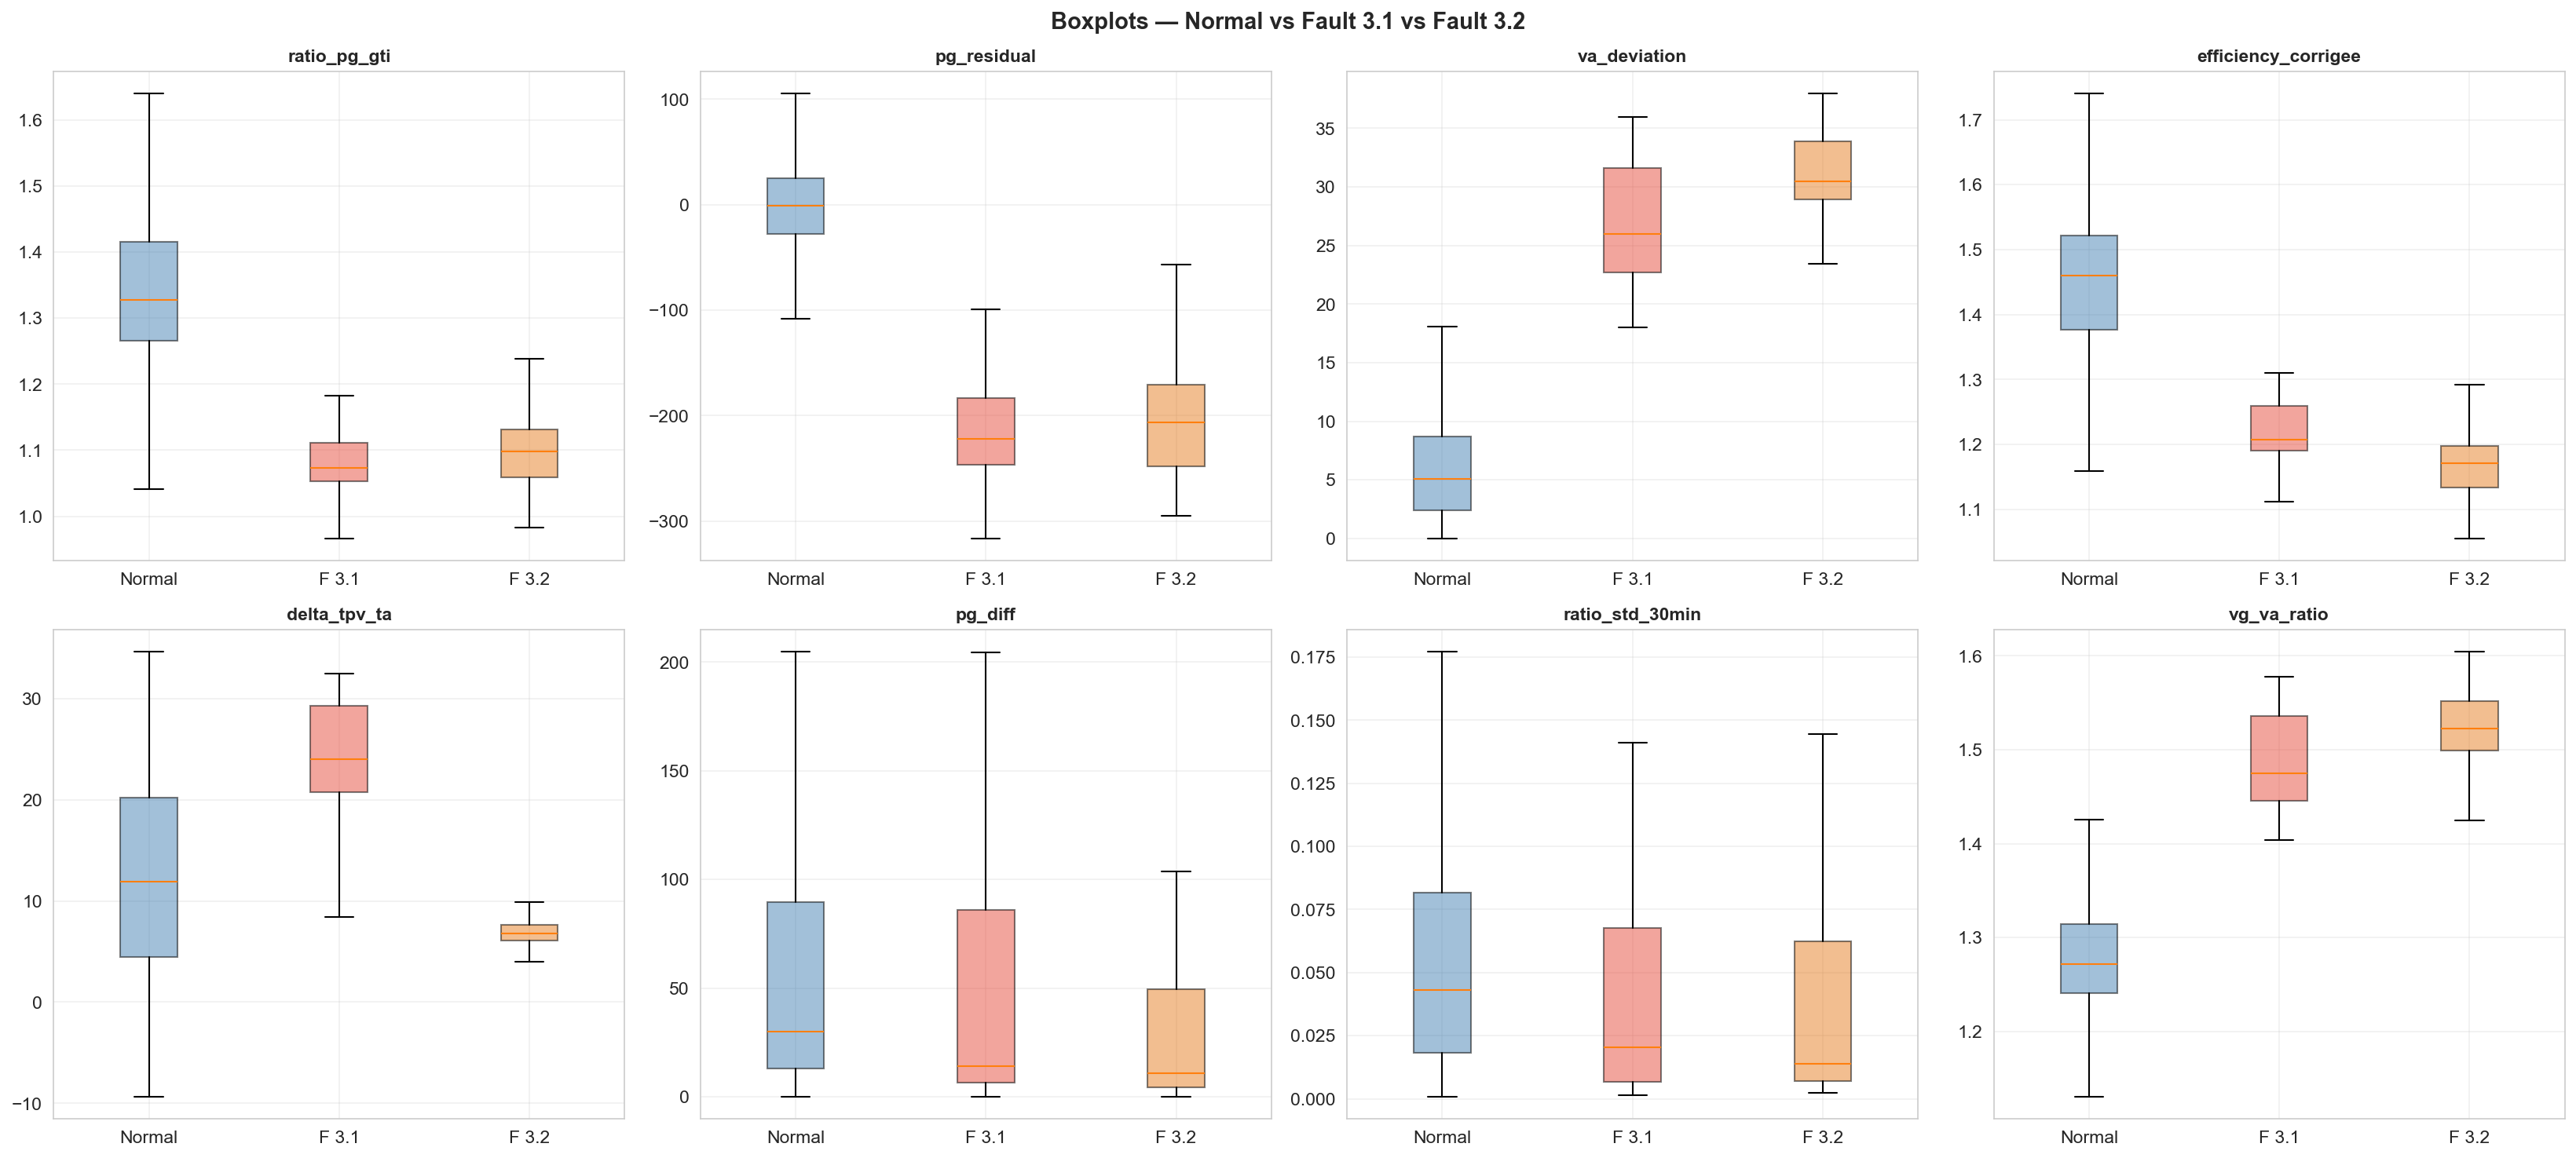

In [255]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("Boxplots — Normal vs Fault 3.1 vs Fault 3.2", fontsize=14, fontweight="bold")

box_feats = FEATURES_PHASE1[:1] + ["pg_residual", "va_deviation", "efficiency_corrigee",
             "delta_tpv_ta", "pg_diff", "ratio_std_30min","vg_va_ratio"]

for ax, feat in zip(axes.flatten()[:len(box_feats)], box_feats):
    data, labels = [], []
    for name, subset in [("Normal", normal), ("F 3.1", fault31), ("F 3.2", fault32)]:
        d = subset[feat].dropna()
        if len(d) > 0:
            data.append(d.values); labels.append(name)

    bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)
    for patch, color in zip(bp["boxes"], ["#4682B4", "#E74C3C", "#E67E22"]):
        patch.set_facecolor(color); patch.set_alpha(0.5)
    ax.set_title(feat, fontsize=11, fontweight="bold"); ax.grid(True, alpha=0.3)

for ax in axes.flatten()[len(box_feats):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

#### 4.2.7 Zoom temporel — Comportement pendant une période Fault 3


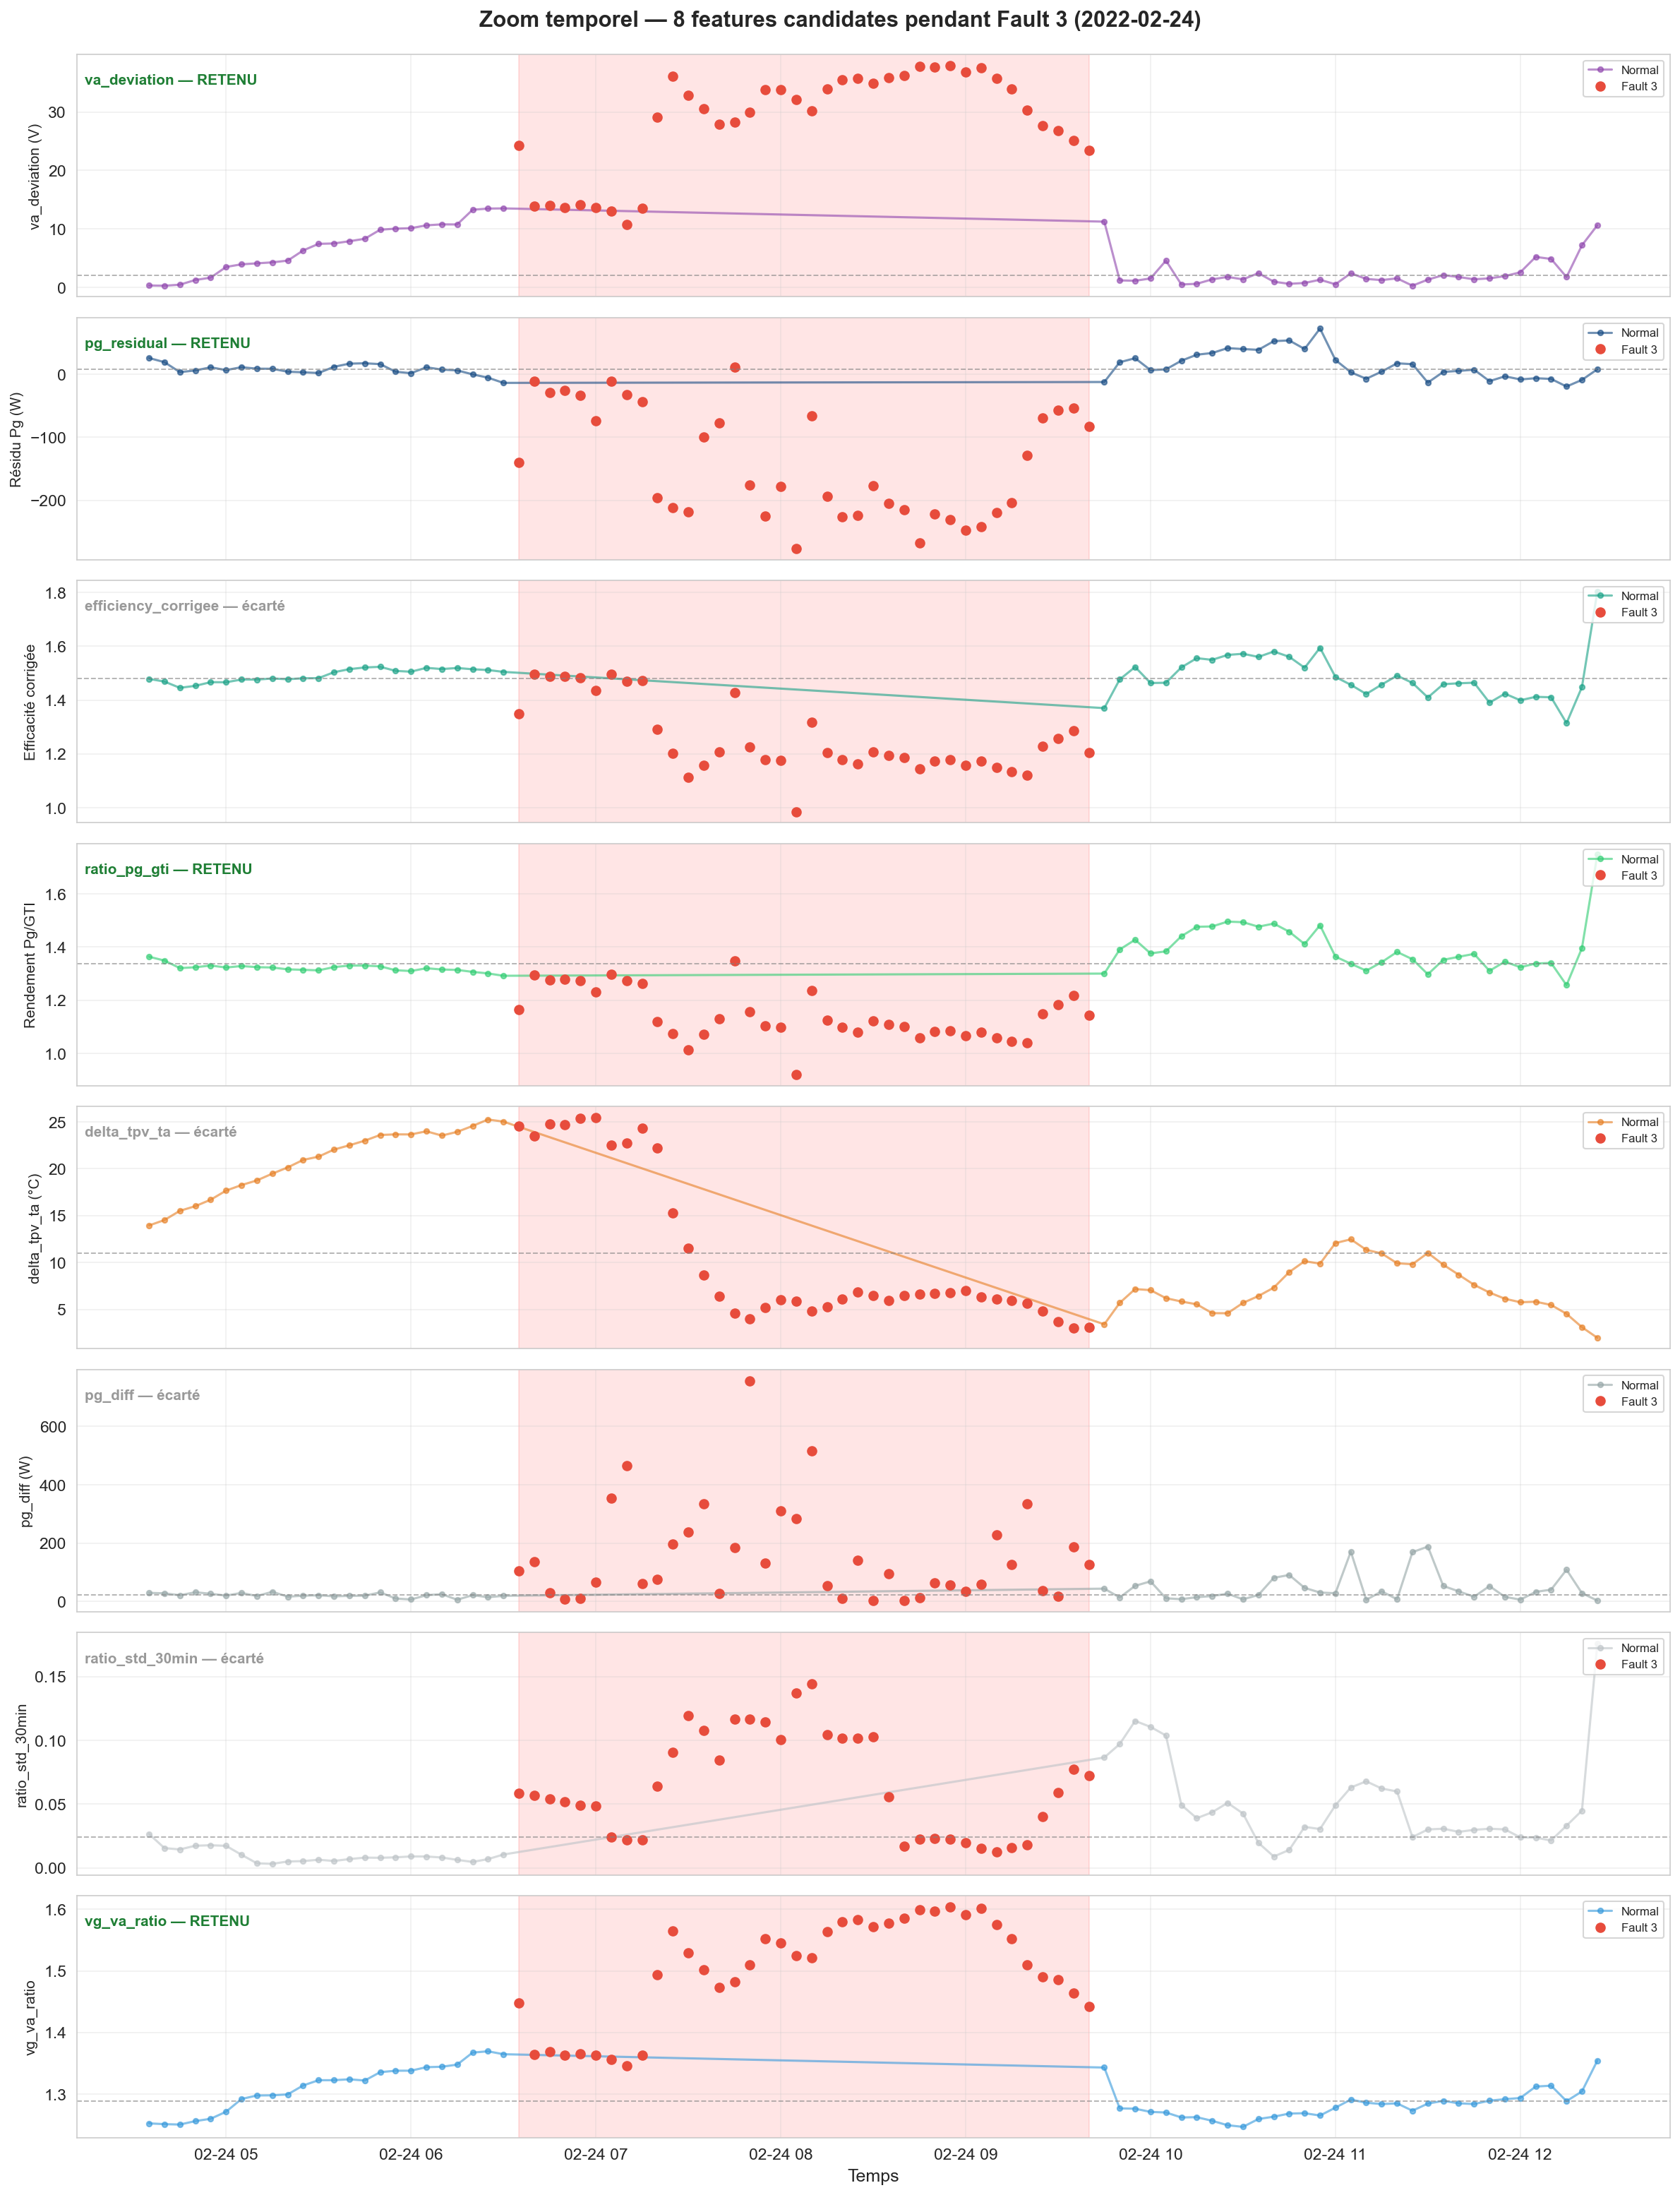

Épisode : 2022-02-24 06:35 (Fault 3.2)



In [284]:


f3 = df[df["Fault"].isin([3.1, 3.2])]
gaps = f3.index.to_series().diff() > pd.Timedelta("30min")
gaps.iloc[0] = True
fault3_starts = f3.index[gaps]

if len(fault3_starts) > 0:
    start = fault3_starts[0] - pd.Timedelta("2h")
    end   = fault3_starts[0] + pd.Timedelta("6h")
    window = df[start:end]

    # 7 features : ordre = fort pouvoir séparateur → faible (d'après KS)
    plot_vars = [
        ("va_deviation",        "va_deviation (V)",        "#8E44AD"),
        ("pg_residual",         "Résidu Pg (W)",           "#144982"),
        ("efficiency_corrigee", "Efficacité corrigée",     "#16A085"),
        ("ratio_pg_gti",        "Rendement Pg/GTI",        "#2ECC71"),
        ("delta_tpv_ta",        "delta_tpv_ta (°C)",       "#E67E22"),
        ("pg_diff",             "pg_diff (W)",             "#95A5A6"),
        ("ratio_std_30min",     "ratio_std_30min",         "#BDC3C7" ),
        ("vg_va_ratio",         "vg_va_ratio",             "#3498DB" ),
    ]

    fig, axes = plt.subplots(len(plot_vars), 1, figsize=(16, 2.6*len(plot_vars)), sharex=True)
    fig.suptitle(f"Zoom temporel — 8 features candidates pendant Fault 3 ({start.strftime('%Y-%m-%d')})",
                 fontsize=15, fontweight="bold", y=0.995)

    for ax, (feat, ylabel, color) in zip(axes, plot_vars):
        mask_ok = window["Fault"] == 0
        mask_f3 = window["Fault"].isin([3.1, 3.2])

        ax.plot(window.index[mask_ok], window[feat][mask_ok],
                "o-", color=color, markersize=3.5, alpha=0.6, label="Normal")
        ax.plot(window.index[mask_f3], window[feat][mask_f3],
                "o", color="#E74C3C", markersize=6, label="Fault 3")

        if mask_f3.any():
            ax.axvspan(window.index[mask_f3].min(), window.index[mask_f3].max(),
                       alpha=0.10, color="red", zorder=0)

        med = window[feat][mask_ok].median()
        ax.axhline(med, color="gray", ls="--", lw=0.9, alpha=0.6)

        # Statut calculé automatiquement depuis FEATURES_ML (une seule source de vérité)
        retenu = feat in FEATURES_ML
        statut = "RETENU" if retenu else "écarté"
        couleur_statut = "#1E7E34" if retenu else "#999999"

        ax.set_ylabel(ylabel, fontsize=10)
        ax.text(0.005, 0.92, f"{feat} — {statut}", transform=ax.transAxes,
                fontsize=10, fontweight="bold", color=couleur_statut, va="top")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)

    axes[-1].set_xlabel("Temps")
    plt.tight_layout()
    plt.show()

    print(f"Épisode : {fault3_starts[0].strftime('%Y-%m-%d %H:%M')} "
          f"(Fault {f3.loc[fault3_starts[0], 'Fault']})\n")


#### 4.2.8 t-SNE APRÈS enrichissement (Phase 1 + Phase 2 — 14 variables)

Même échantillon et mêmes paramètres que le t-SNE de 4.1.1 pour une comparaison équitable.

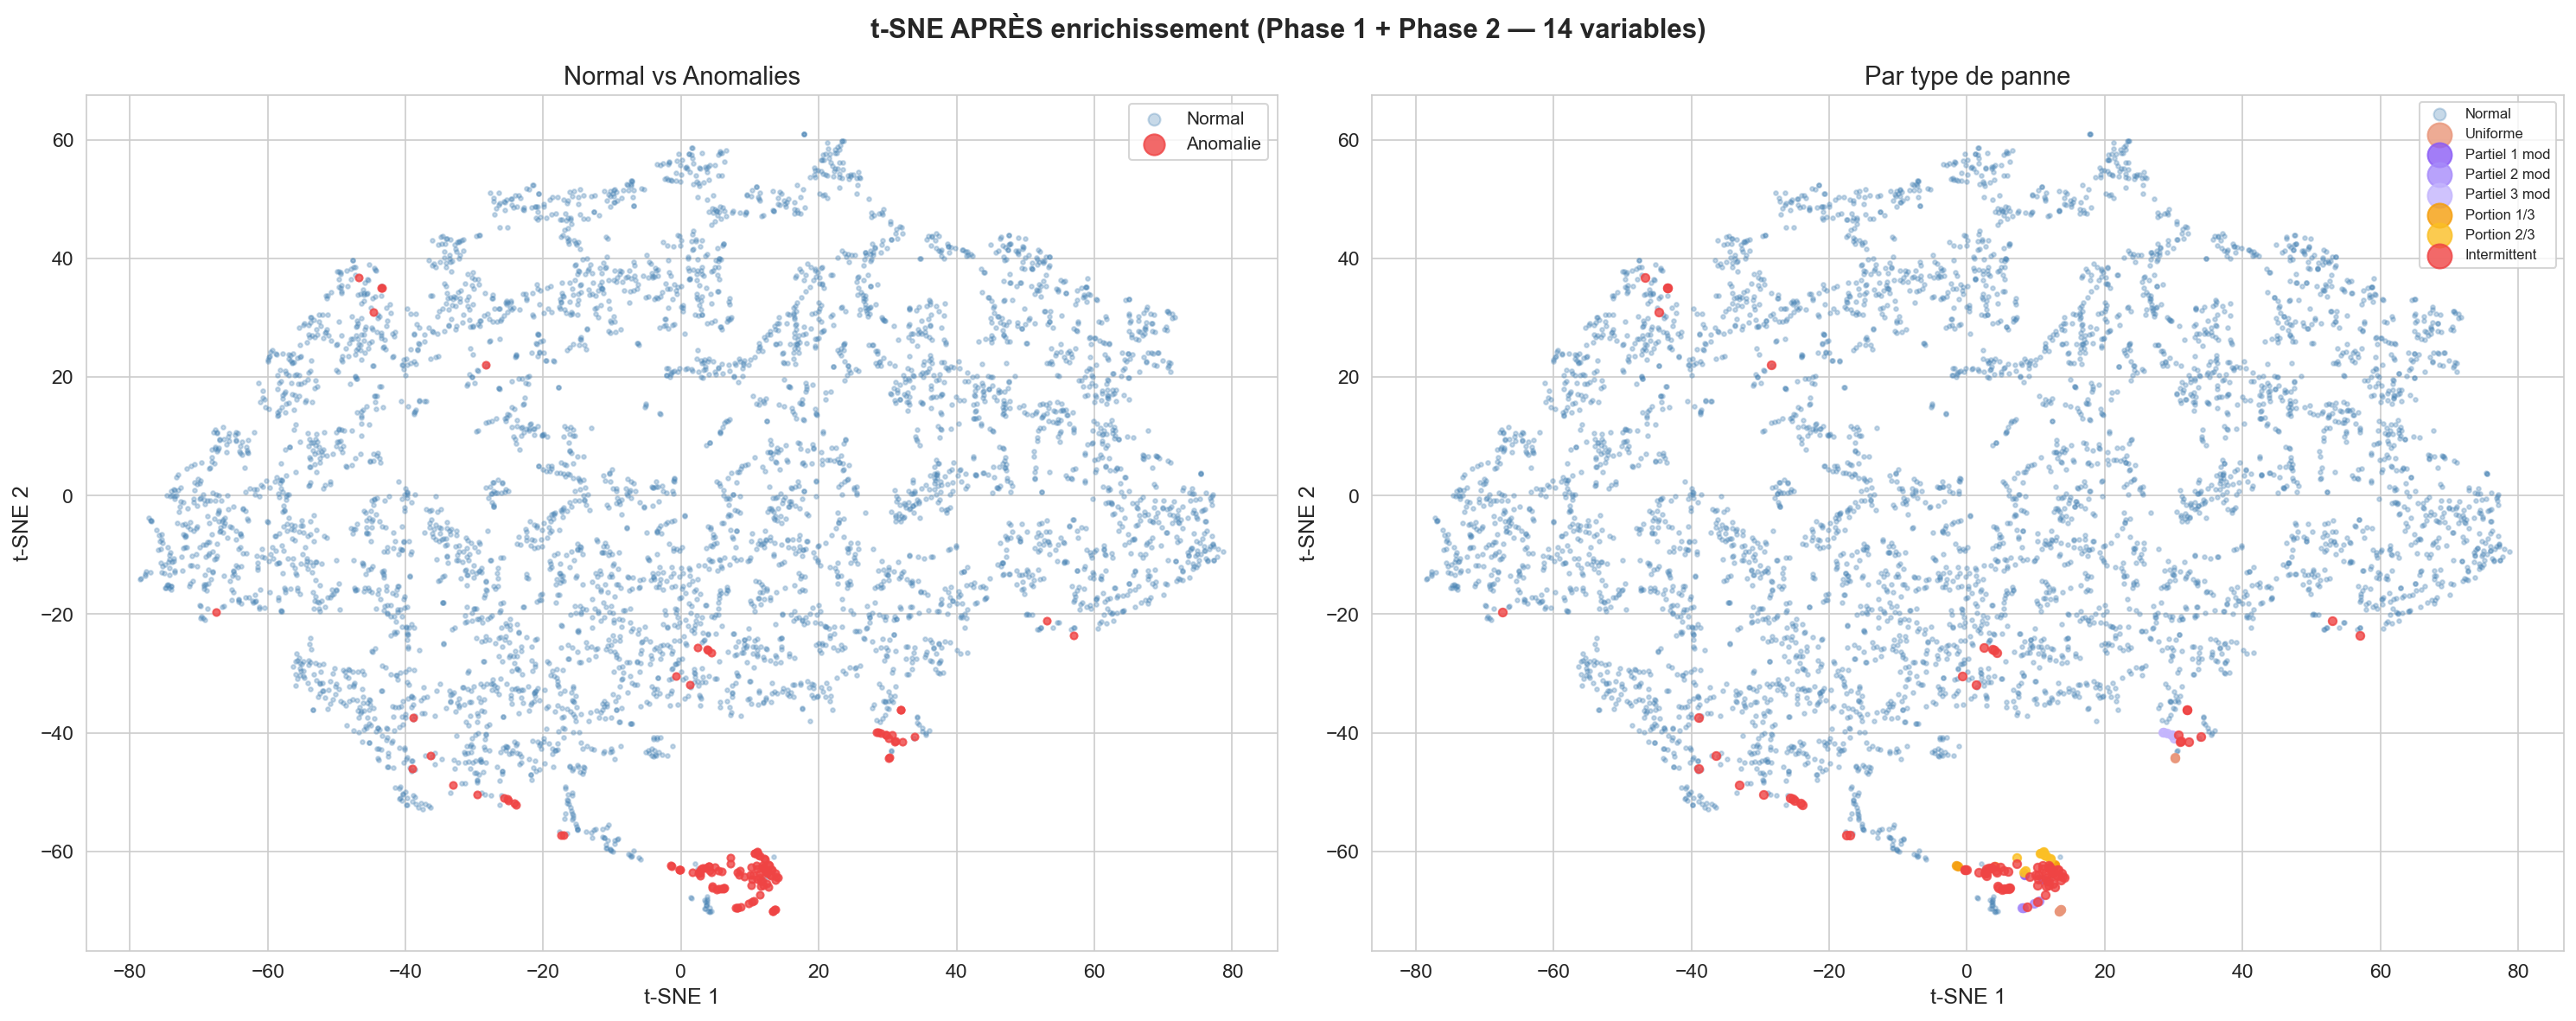

In [287]:
FEATURES_PHASE2_KEPT = ["pg_residual", "va_deviation", "vg_va_ratio"]

FEATURES_ML = FEATURES_CAPTEURS + FEATURES_PHASE1 + FEATURES_PHASE2_KEPT
sample = df.sample(n=5000, random_state=42)
X_sample2 = sample[FEATURES_ML].dropna()
sample_clean2 = sample.loc[X_sample2.index]

X_2d2 = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(
    StandardScaler().fit_transform(X_sample2)
)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("t-SNE APRÈS enrichissement (Phase 1 + Phase 2 — 14 variables)", fontsize=15, fontweight="bold")

mask_n2 = sample_clean2["Fault"] == 0
axes[0].scatter(X_2d2[mask_n2, 0], X_2d2[mask_n2, 1], alpha=0.3, s=5, c="#4682B4", label="Normal")
axes[0].scatter(X_2d2[~mask_n2, 0], X_2d2[~mask_n2, 1], alpha=0.8, s=15, c="#EF4444", label="Anomalie")
axes[0].set_title("Normal vs Anomalies")
axes[0].legend(markerscale=3)
axes[0].set_xlabel("t-SNE 1"); axes[0].set_ylabel("t-SNE 2")

for fv in sorted(sample_clean2["Fault"].unique()):
    m = sample_clean2["Fault"] == fv
    axes[1].scatter(X_2d2[m, 0], X_2d2[m, 1],
                    alpha=0.3 if fv == 0 else 0.8, s=5 if fv == 0 else 20,
                    c=COLORS_TSNE.get(fv, "gray"), label=LABELS_TSNE.get(fv, f"Fault {fv}"))
axes[1].set_title("Par type de panne")
axes[1].legend(markerscale=3, fontsize=8)
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

c:\Users\PC\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


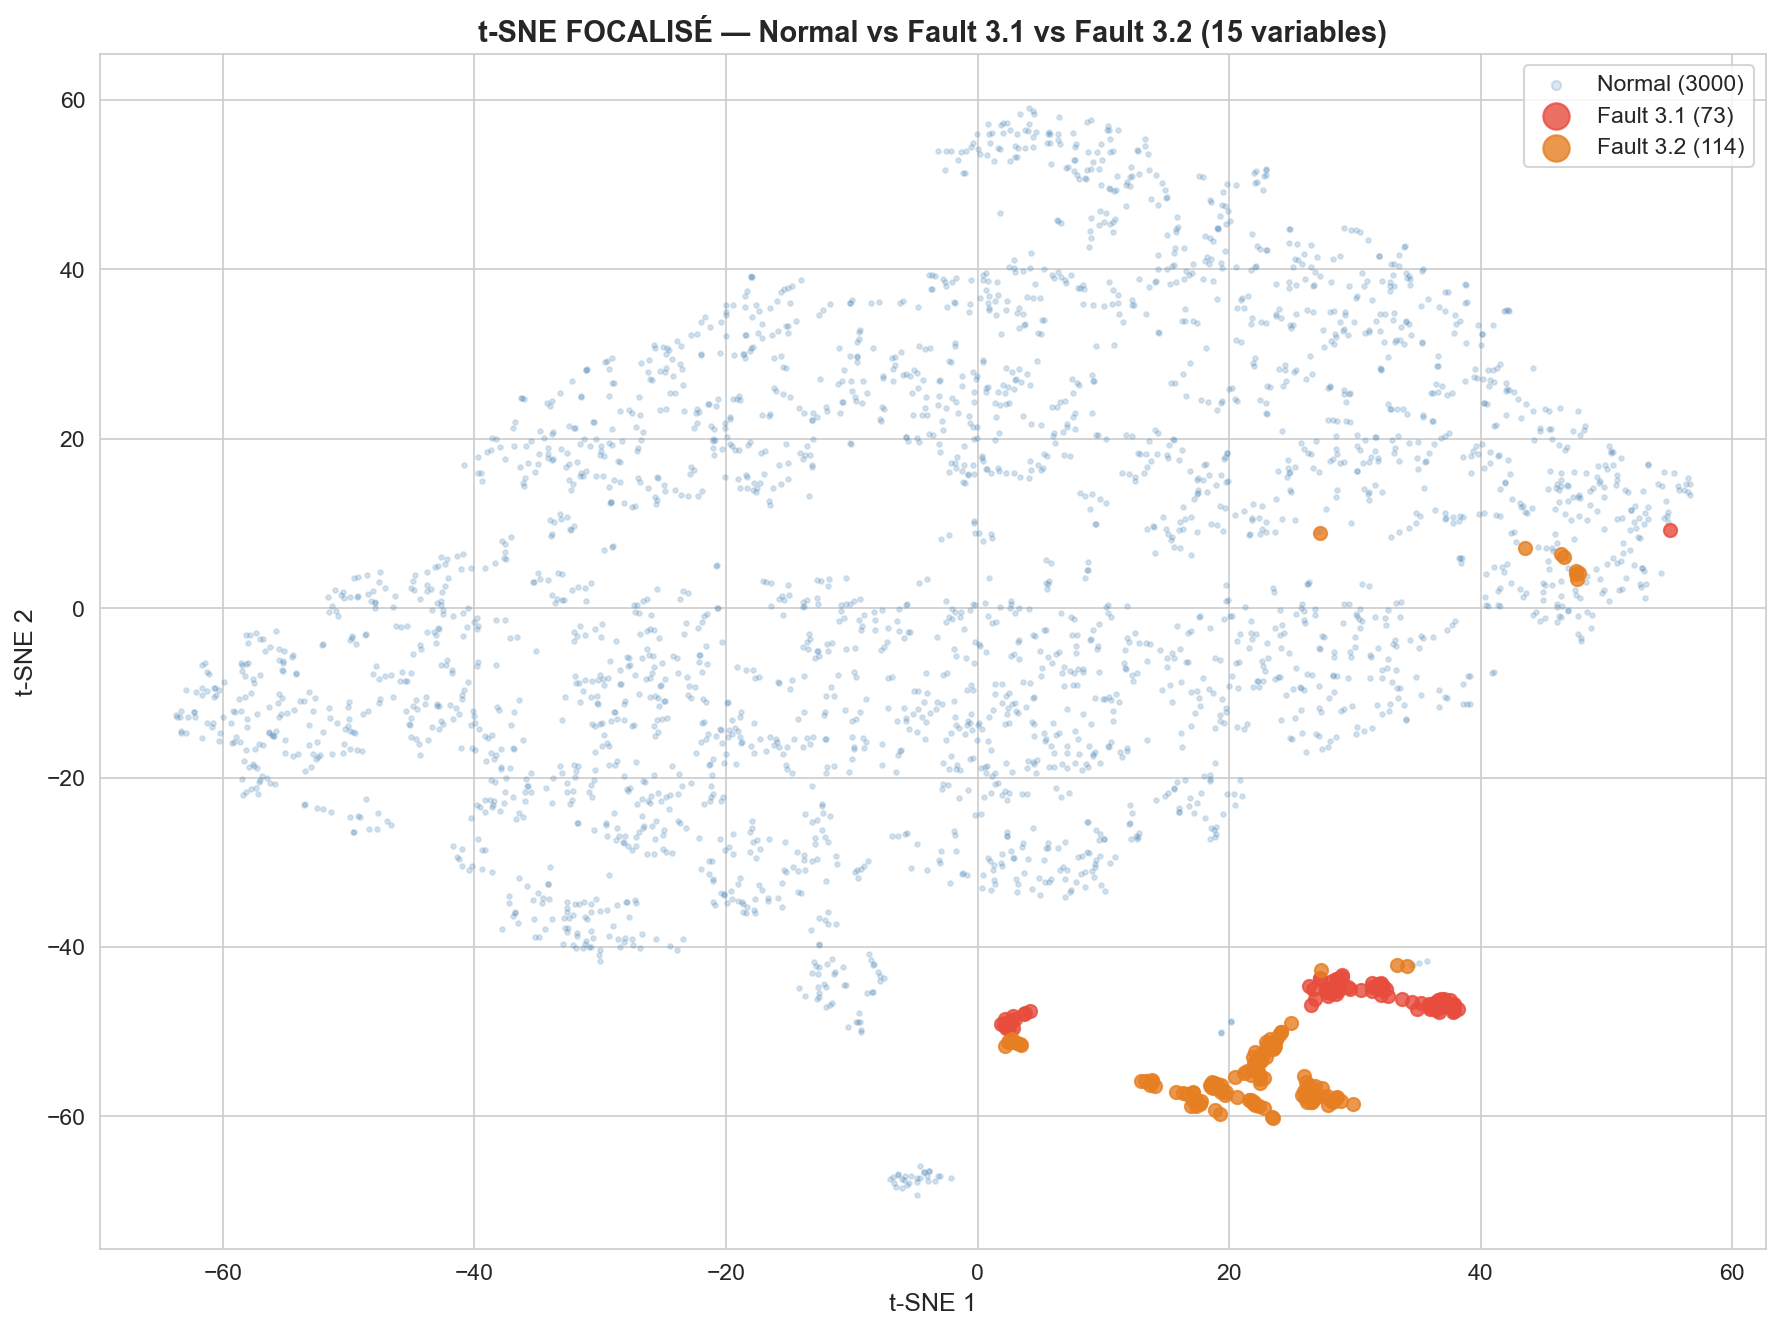

In [ ]:
# t-SNE FOCALISÉ — Normal vs Fault 3.1 vs Fault 3.2 uniquement
normal_tsne = df.loc[df["Fault"] == 0, FEATURES_ML].dropna().sample(n=3000, random_state=42)
f31_tsne = df.loc[df["Fault"] == 3.1, FEATURES_ML].dropna()
f32_tsne = df.loc[df["Fault"] == 3.2, FEATURES_ML].dropna()

sample_focus = pd.concat([normal_tsne, f31_tsne, f32_tsne])
labels_focus = (["Normal"] * len(normal_tsne) +
                ["Fault 3.1"] * len(f31_tsne) +
                ["Fault 3.2"] * len(f32_tsne))

X_2d_focus = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000).fit_transform(
    StandardScaler().fit_transform(sample_focus)
)

fig, ax = plt.subplots(figsize=(12, 9))
color_f = {"Normal": "#4682B4", "Fault 3.1": "#E74C3C", "Fault 3.2": "#E67E22"}
size_f = {"Normal": 5, "Fault 3.1": 40, "Fault 3.2": 40}
alpha_f = {"Normal": 0.2, "Fault 3.1": 0.8, "Fault 3.2": 0.8}

for label in ["Normal", "Fault 3.1", "Fault 3.2"]:
    m = np.array(labels_focus) == label
    ax.scatter(X_2d_focus[m, 0], X_2d_focus[m, 1],
              s=size_f[label], alpha=alpha_f[label],
              c=color_f[label], label=f"{label} ({m.sum()})")

ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE FOCALISÉ — Normal vs Fault 3.1 vs Fault 3.2 (14 variables)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, markerscale=2)
plt.tight_layout()
plt.show()


#### 4.2.9 — Ablation : valider le choix des features par leur effet sur l'IF


ABLATION — PR-AUC test (moyenne 3 seeds) | 184 anomalies de test

Configuration                      n  PR-AUC test
10 capteurs seuls                 10        0.142
+ Phase 1 complète (4)            14        0.134
+ ratio_pg_gti seul (11)          11        0.194
14 : avec efficiency              14        0.342
15 : LES DEUX (eff + vg_va)       15        0.389
14 : avec vg_va (FINALE)          14        0.394
sans vg_va_ratio                  13        0.356
sans va_deviation                 13        0.346
sans pg_residual                  13        0.374


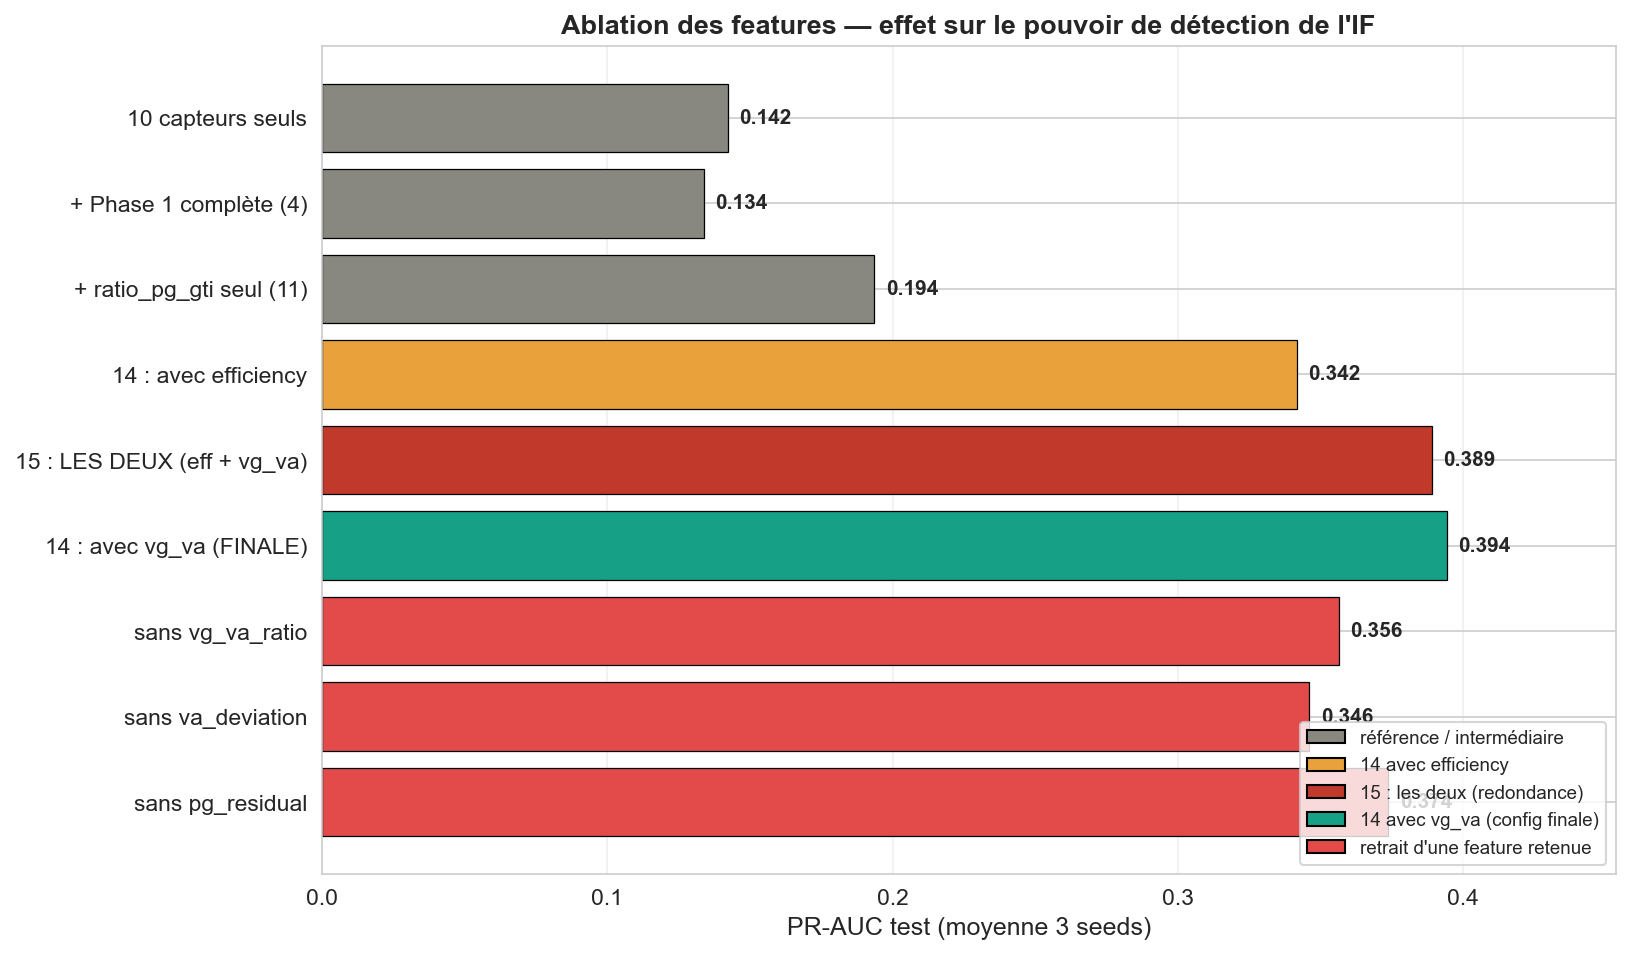

In [279]:
_ano = df[df["Fault"] != 0]
_fin = _ano.index.max() + pd.Timedelta("7D")
_de = df.loc[:_fin]

_d = _de.dropna(
        subset=FEATURES_CAPTEURS + FEATURES_PHASE1_CANDIDATES
               + ["pg_residual", "va_deviation", "efficiency_corrigee", "vg_va_ratio"]
     ).sort_index()
_it = int(len(_d) * 0.72)
_tr, _te = _d.iloc[:_it], _d.iloc[_it:]
_trn = _tr[_tr["Fault"] == 0]
_yte = (_te["Fault"] != 0).astype(int).values
assert _yte.sum() > 0, "mini-split : test sans anomalie"

def _pr_auc(feats):
    sc = StandardScaler().fit(_trn[feats])
    p = []
    for s in [0, 42, 7]:
        m = IsolationForest(n_estimators=300, max_samples=512, contamination=0.01,
                            random_state=s, n_jobs=-1).fit(sc.transform(_trn[feats]))
        p.append(average_precision_score(_yte, -m.score_samples(sc.transform(_te[feats]))))
    return float(np.mean(p))

_base3 = ["pg_residual", "va_deviation", "vg_va_ratio"]   # Phase 2 finale

configs = {
    "10 capteurs seuls":              FEATURES_CAPTEURS,
    "+ Phase 1 complète (4)":         FEATURES_CAPTEURS + FEATURES_PHASE1_CANDIDATES,
    "+ ratio_pg_gti seul (11)":       FEATURES_CAPTEURS + ["ratio_pg_gti"],
    "14 : avec efficiency":           FEATURES_CAPTEURS + ["ratio_pg_gti", "pg_residual", "va_deviation", "efficiency_corrigee"],
    "15 : LES DEUX (eff + vg_va)":    FEATURES_CAPTEURS + ["ratio_pg_gti", "pg_residual", "va_deviation", "efficiency_corrigee", "vg_va_ratio"],
    "14 : avec vg_va (FINALE)":       FEATURES_CAPTEURS + ["ratio_pg_gti"] + _base3,
    "sans vg_va_ratio":               FEATURES_CAPTEURS + ["ratio_pg_gti", "pg_residual", "va_deviation"],
    "sans va_deviation":              FEATURES_CAPTEURS + ["ratio_pg_gti", "pg_residual", "vg_va_ratio"],
    "sans pg_residual":               FEATURES_CAPTEURS + ["ratio_pg_gti", "va_deviation", "vg_va_ratio"],
}

resultats = {nom: _pr_auc(feats) for nom, feats in configs.items()}

print(f"ABLATION — PR-AUC test (moyenne 3 seeds) | {_yte.sum()} anomalies de test\n")
print(f"{'Configuration':<32}{'n':>4}{'PR-AUC test':>13}")
for nom, feats in configs.items():
    print(f"{nom:<32}{len(feats):>4}{resultats[nom]:>13.3f}")

noms  = list(resultats.keys())
vals  = [resultats[n] for n in noms]
couleurs = []
for n in noms:
    if n == "14 : avec vg_va (FINALE)":      couleurs.append("#16A085")
    elif n == "15 : LES DEUX (eff + vg_va)": couleurs.append("#C0392B")
    elif n == "14 : avec efficiency":        couleurs.append("#E9A23B")
    elif n.startswith("sans"):               couleurs.append("#E24B4A")
    else:                                    couleurs.append("#888780")

fig, ax = plt.subplots(figsize=(11, 6.5))
y = np.arange(len(noms))
barres = ax.barh(y, vals, color=couleurs, edgecolor="black", linewidth=0.6)
ax.set_yticks(y); ax.set_yticklabels(noms)
ax.invert_yaxis()
ax.set_xlabel("PR-AUC test (moyenne 3 seeds)")
ax.set_xlim(0, max(vals) * 1.15)
ax.set_title("Ablation des features — effet sur le pouvoir de détection de l'IF",
             fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
for b, v in zip(barres, vals):
    ax.text(v + 0.004, b.get_y() + b.get_height()/2, f"{v:.3f}",
            va="center", fontsize=10, fontweight="bold")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#888780", edgecolor="black", label="référence / intermédiaire"),
    Patch(facecolor="#E9A23B", edgecolor="black", label="14 avec efficiency"),
    Patch(facecolor="#C0392B", edgecolor="black", label="15 : les deux (redondance)"),
    Patch(facecolor="#16A085", edgecolor="black", label="14 avec vg_va (config finale)"),
    Patch(facecolor="#E24B4A", edgecolor="black", label="retrait d'une feature retenue"),
], loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("figures/fig_if_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

del _d, _it, _tr, _te, _trn, _yte, _base3, _ano, _fin, _de

#### 4.2.10 Conclusion et ajout des features retenues

| Feature | KS | ρ avec ratio_pg_gti | Décision | Justification |
|---|---|---|---|---|
| ratio_pg_gti | 0.82 | — | Retenue (P1) | Rendement normalisé par le soleil, forte séparation |
| pg_residual | 0.76 | 0.72 | Retenue | Écart à la production attendue, amplifie les écarts subtils |
| va_deviation | 0.71 | −0.36 | Retenue | Déviation de tension, axe décorrélé du rendement |
| vg_va_ratio | 0.71 | faible | Retenue | Déséquilibre de tension Vg/Va, axe physique nouveau (+PR-AUC) |
| efficiency_corrigee | 0.80 | 0.94 | Écartée | KS élevé mais redondante (ρ=0.94) ; l'ablation montre qu'elle dégrade le PR-AUC |
| ratio_mean_1h | 0.85 | 0.78 | Écartée | KS élevé mais redondante avec ratio_pg_gti ; n'apporte pas d'info nouvelle |
| ratio_ia_gti | 0.27 | 0.82 | Écartée | KS trop faible ET redondante |
| ratio_local_dev | 0.05 | — | Écartée | KS quasi nul, aucun pouvoir discriminant |

In [285]:

cols_drop = ["ratio_ia_gti", "ratio_mean_1h", "ratio_local_dev"]
df.drop(columns=[c for c in cols_drop if c in df.columns], inplace=True)
FEATURES_ENG = FEATURES_PHASE1 + FEATURES_PHASE2_KEPT

print(f"Dataset final : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"\n=== {len(FEATURES_ENG)} features engineered retenues ===")
print(df[FEATURES_ENG].describe().round(3))
print(f"\nColonnes finales : {df.columns.tolist()}")

# Sauvegarde
df.to_csv("data/cleaned_with_features.csv")
print(f"\nSauvegardé : data/cleaned_with_features.csv")

Dataset final : 52,959 lignes × 22 colonnes

=== 4 features engineered retenues ===
       ratio_pg_gti  pg_residual  va_deviation  vg_va_ratio
count     52959.000    52959.000     52959.000    52959.000
mean          1.336       -7.083         6.784        1.286
std           0.176       82.218         6.841        0.072
min           0.000    -1477.342         0.000        1.056
25%           1.260      -31.224         2.460        1.242
50%           1.324       -2.210         5.200        1.274
75%           1.412       24.266         9.040        1.318
max           3.369      390.642       181.502        2.190

Colonnes finales : ['DTI', 'GTI', 'TA', 'TPV', 'Ia', 'Ig', 'Eg', 'Fg', 'Pg', 'Va', 'Vg', 'Fault', 'ratio_pg_gti', 'delta_tpv_ta', 'pg_diff', 'ratio_std_30min', 'pg_residual', 'va_deviation', 'efficiency_corrigee', 'date', 'split', 'vg_va_ratio']

Sauvegardé : data/cleaned_with_features.csv


---
## 6. Distribution temporelle des anomalies — contrainte sur le découpage
---

In [61]:
anomalies_all = df[df["Fault"] != 0]

print(f"Période couverte  : {df.index.min().date()} → {df.index.max().date()}")
print(f"Première anomalie : {anomalies_all.index.min().date()}")
print(f"Dernière anomalie : {anomalies_all.index.max().date()}")

pos_derniere = df.index.get_indexer([anomalies_all.index.max()])[0] / len(df)
print(f"\nLa dernière anomalie se situe à {pos_derniere:.1%} de la série.")

print("\n=== Anomalies par mois ===")
par_mois = anomalies_all.groupby(anomalies_all.index.tz_localize(None).to_period("M")).size()
print(par_mois.to_string())

Période couverte  : 2021-10-28 → 2023-04-13
Première anomalie : 2022-02-08
Dernière anomalie : 2022-05-19

La dernière anomalie se situe à 32.6% de la série.

=== Anomalies par mois ===
time
2022-02    430
2022-03    880
2022-04    111
2022-05     73
Freq: M


**Constat.** Les pannes se concentrent sur une fenêtre de trois mois en début de série ; les onze mois suivants n'en comportent aucune.

Un découpage 70/10/20 sur la série entière placerait donc toutes les anomalies dans le train, laissant `val` et `test` sans un seul positif — aucune métrique de détection ne serait calculable.

**Décision.** L'étude est restreinte à la période allant du début de la série jusqu'à peu après la dernière anomalie. Cette troncature garantit que chaque partition contient des pannes, tout en préservant l'ordre chronologique.

In [291]:
# Horizon serré : la troncature s'arrête peu après la dernière anomalie,
# sinon la queue sans panne accapare le test.
MARGE = pd.Timedelta(days=7)
fin_etude = anomalies_all.index.max() + MARGE

df_etude = df.loc[:fin_etude].copy()

print(f"Période d'étude : {df_etude.index.min().date()} → {df_etude.index.max().date()}")
print(f"Volume          : {len(df_etude):,} lignes sur {len(df):,} ({100*len(df_etude)/len(df):.1f}%)")
print(f"Anomalies       : {(df_etude['Fault'] != 0).sum():,}")

df_hors_etude = df.loc[fin_etude:].copy()
print(f"\nHors période d'étude : {len(df_hors_etude):,} lignes, "
      f"{(df_hors_etude['Fault'] != 0).sum()} anomalie(s)")

Période d'étude : 2021-10-28 → 2022-05-26
Volume          : 18,057 lignes sur 52,959 (34.1%)
Anomalies       : 1,494

Hors période d'étude : 34,903 lignes, 0 anomalie(s)


---
## 7. Split chronologique sur la période d'étude
---




Split  Lignes      Début        Fin  Normaux  Anomalies   Taux
train    8060 2021-10-28 2022-02-23     7668        392  4.86%
  val    4941 2022-02-23 2022-04-11     4023        918 18.58%
 test    5056 2022-04-11 2022-05-26     4872        184  3.64%

Types de panne par partition :
  train : {np.float64(1.0): 51, np.float64(2.1): 36, np.float64(2.2): 41, np.float64(2.3): 55, np.float64(4.0): 209}
  val   : {np.float64(3.2): 58, np.float64(4.0): 860}
  test  : {np.float64(3.1): 73, np.float64(3.2): 56, np.float64(4.0): 55}

val enrichie (918 anos) | test réaliste 3 types dont Fault 3.1.


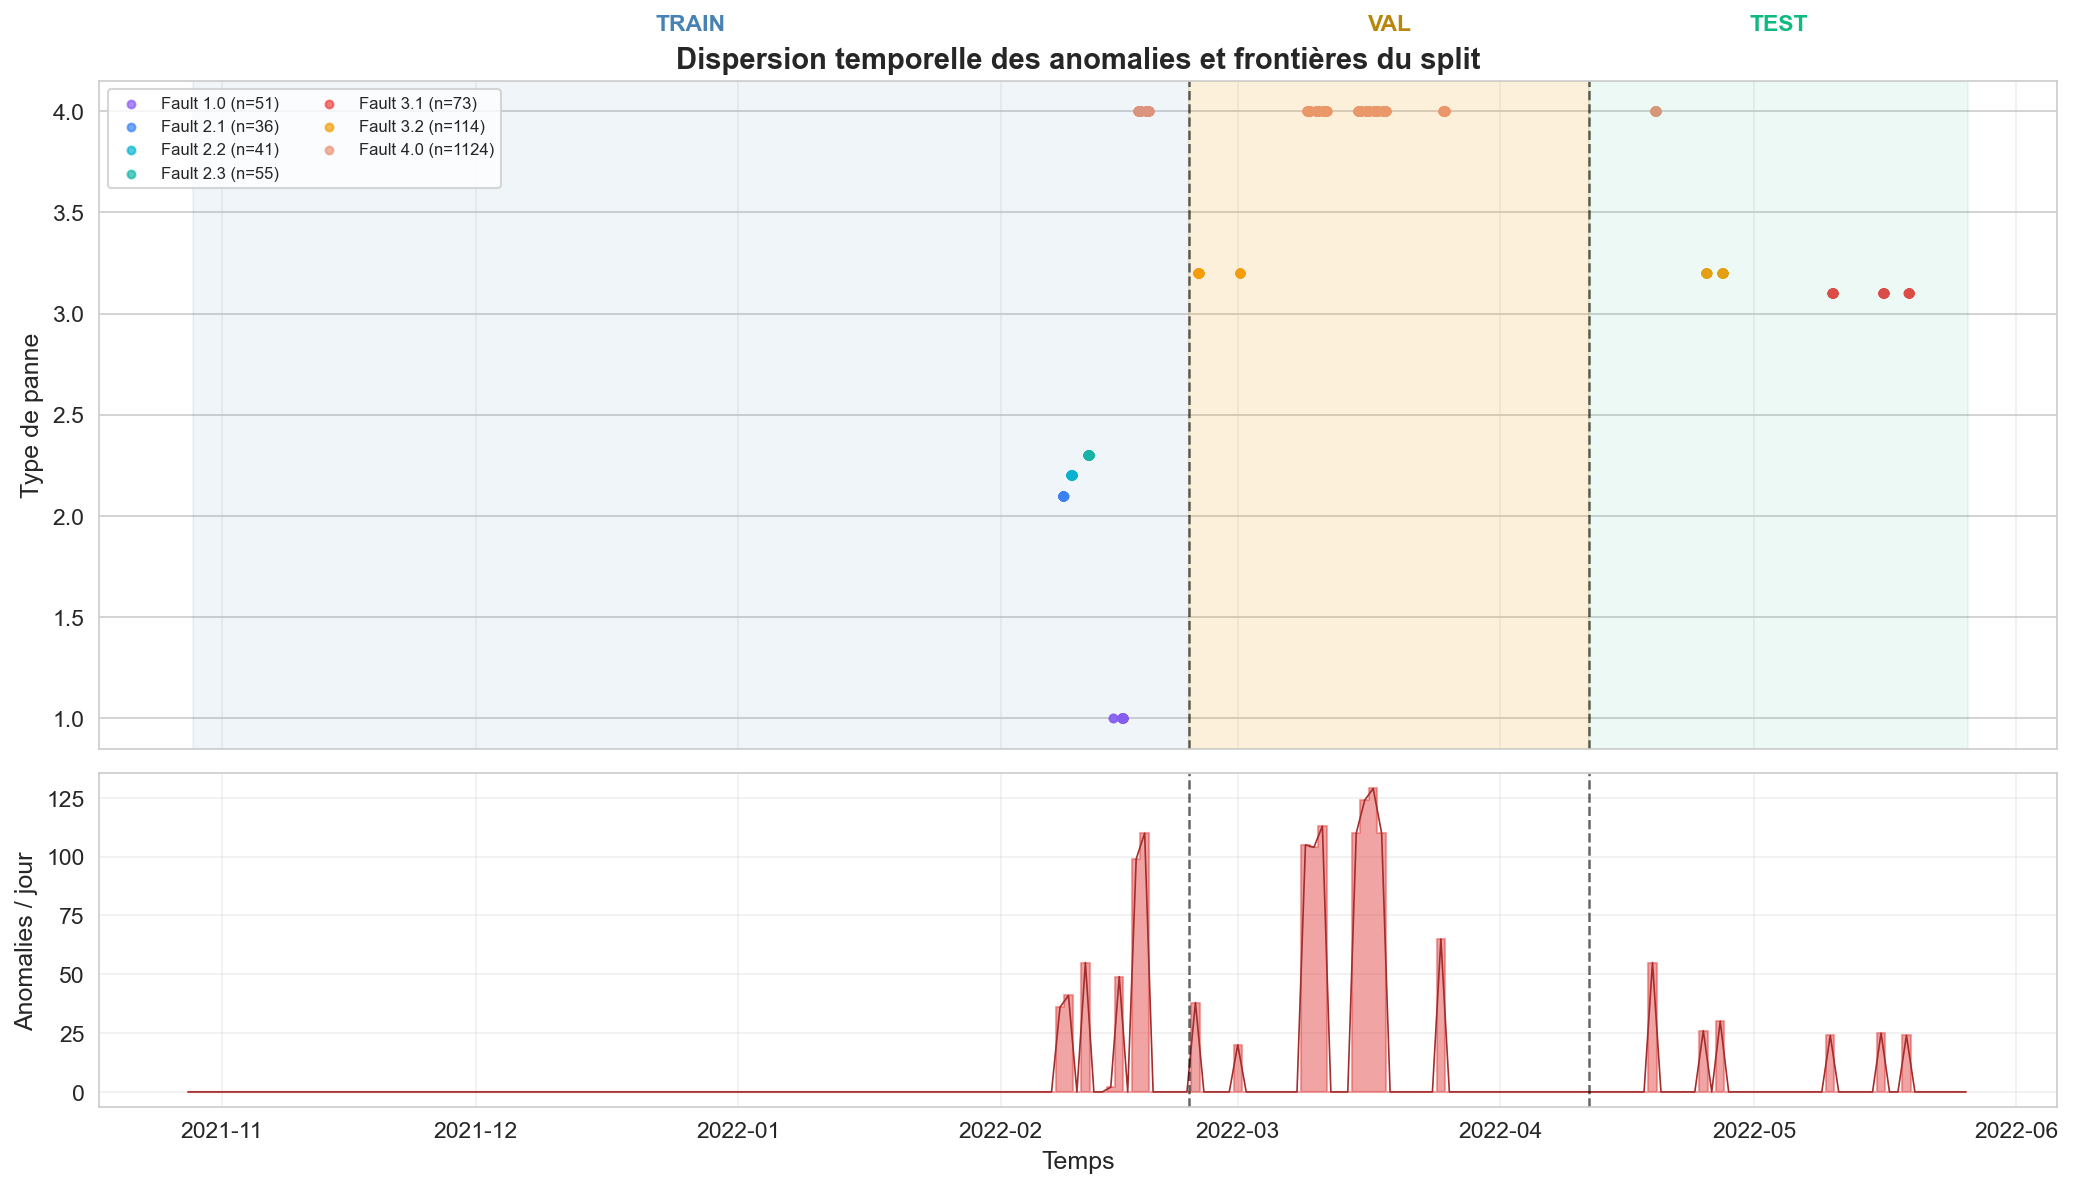

Concentration des anomalies :
  train :  392 anomalies sur  8060 lignes (4.9%) | types [np.float64(1.0), np.float64(2.1), np.float64(2.2), np.float64(2.3), np.float64(4.0)]
  val   :  918 anomalies sur  4941 lignes (18.6%) | types [np.float64(3.2), np.float64(4.0)]
  test  :  184 anomalies sur  5056 lignes (3.6%) | types [np.float64(3.1), np.float64(3.2), np.float64(4.0)]


In [292]:
# =============================================================
# Visualisation : dispersion temporelle des anomalies + frontières du split
# =============================================================
# Split chronologique : test réaliste + val riche pour le tuning
df_etude = df_etude.sort_index()
n = len(df_etude)

I_TEST = int(n * 0.72)             
dev    = df_etude.iloc[:I_TEST]
test   = df_etude.iloc[I_TEST:]

I_VAL = int(len(dev) * 0.62)     
train = dev.iloc[:I_VAL]
val   = dev.iloc[I_VAL:]

recap = pd.DataFrame([
    {"Split": nom, "Lignes": len(d),
     "Début": d.index.min().date(), "Fin": d.index.max().date(),
     "Normaux": int((d["Fault"] == 0).sum()),
     "Anomalies": int((d["Fault"] != 0).sum()),
     "Taux": f"{100*(d['Fault'] != 0).mean():.2f}%"}
    for nom, d in [("train", train), ("val", val), ("test", test)]
])
print(recap.to_string(index=False))

print("\nTypes de panne par partition :")
for nom, d in [("train", train), ("val", val), ("test", test)]:
    types = {t: int((d["Fault"] == t).sum()) for t in sorted(d["Fault"].unique()) if t != 0}
    print(f"  {nom:6s}: {types}")

assert (val["Fault"]  != 0).sum() > 0, "val sans anomalie"
assert (test["Fault"] != 0).sum() > 0, "test sans anomalie"
print("\nval enrichie (918 anos) | test réaliste 3 types dont Fault 3.1.")
COUL_FAULT = {1.0:"#8B5CF6", 2.1:"#3B82F6", 2.2:"#06B6D4", 2.3:"#14B8A6",
              3.1:"#EF4444", 3.2:"#F59E0B", 4.0:"#E9967A"}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)

ax = axes[0]
for f in sorted(k for k in COUL_FAULT if (df_etude["Fault"] == k).any()):
    sub = df_etude[df_etude["Fault"] == f]
    ax.scatter(sub.index, [f]*len(sub), s=14, color=COUL_FAULT[f],
               label=f"Fault {f} (n={len(sub)})", alpha=0.7)

ax.axvspan(train.index.min(), train.index.max(), alpha=0.08, color="#4682B4")
ax.axvspan(val.index.min(),   val.index.max(),   alpha=0.15, color="#F59E0B")
ax.axvspan(test.index.min(),  test.index.max(),  alpha=0.08, color="#10B981")
for x in [train.index.max(), val.index.max()]:
    ax.axvline(x, color="black", ls="--", lw=1.2, alpha=0.6)

ymax = max(COUL_FAULT)
ax.text(train.index.min()+(train.index.max()-train.index.min())/2, ymax+0.4,
        "TRAIN", ha="center", fontweight="bold", color="#4682B4")
ax.text(val.index.min()+(val.index.max()-val.index.min())/2, ymax+0.4,
        "VAL", ha="center", fontweight="bold", color="#B8860B")
ax.text(val.index.max()+(test.index.max()-val.index.max())/2, ymax+0.4,
        "TEST", ha="center", fontweight="bold", color="#10B981")

ax.set_ylabel("Type de panne")
ax.set_title("Dispersion temporelle des anomalies et frontières du split",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(axis="x", alpha=0.3)

ax2 = axes[1]
daily = (df_etude["Fault"] != 0).resample("D").sum()
ax2.fill_between(daily.index, daily.values, color="#E24B4A", alpha=0.5, step="mid")
ax2.plot(daily.index, daily.values, color="#A32D2D", lw=0.8)
for x in [train.index.max(), val.index.max()]:
    ax2.axvline(x, color="black", ls="--", lw=1.2, alpha=0.6)
ax2.set_ylabel("Anomalies / jour")
ax2.set_xlabel("Temps")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/fig_if_split_dispersion.png", dpi=150, bbox_inches="tight")
plt.show()

# Résumé chiffré de la dispersion
print("Concentration des anomalies :")
for nom, d in [("train", train), ("val", val), ("test", test)]:
    a = int((d["Fault"] != 0).sum())
    print(f"  {nom:6s}: {a:>4} anomalies sur {len(d):>5} lignes "
          f"({100*a/len(d):.1f}%) | types {sorted(t for t in d['Fault'].unique() if t!=0)}")

---
## 7bis. Normalisation
---

**Pourquoi après le split.** Ajuster un `StandardScaler` sur le dataset complet ferait entrer les statistiques de `val` et `test` dans la transformation du `train` — une fuite qui annulerait l'intérêt du découpage chronologique. Le `fit` se fait donc uniquement sur les données d'entraînement.

**Un scaler par configuration.** Les moyennes et écarts-types doivent refléter les données que chaque modèle voit réellement. Un scaler ajusté sur données saines produit un écart-type plus faible, donc des valeurs normalisées plus extrêmes pour les anomalies. Utiliser le même scaler pour les deux configurations introduirait un biais sans rapport avec la stratégie testée.

In [ ]:
from sklearn.preprocessing import StandardScaler
train_c = train.dropna(subset=FEATURES_ML)
val_c   = val.dropna(subset=FEATURES_ML)
test_c  = test.dropna(subset=FEATURES_ML)
train_normal_c = train_c[train_c["Fault"] == 0]      

print("Après suppression des NaN :")
for nom, avant, apres in [("train", train, train_c), ("val", val, val_c), ("test", test, test_c)]:
    n_ano = int((apres["Fault"] != 0).sum())
    print(f"  {nom:6s} {len(avant):>6,} → {len(apres):>6,}  ({n_ano:,} anomalies)")
print(f"  train_normal : {len(train_normal_c):,} points sains (base d'entraînement Novelty)")

scaler_novelty = StandardScaler().fit(train_normal_c[FEATURES_ML])   # sur le sain
scaler_outlier = StandardScaler().fit(train_c[FEATURES_ML])          # sur tout

SCALERS = {"Novelty": scaler_novelty, "Outlier": scaler_outlier}

Xtr = {"Novelty": scaler_novelty.transform(train_normal_c[FEATURES_ML]),
       "Outlier": scaler_outlier.transform(train_c[FEATURES_ML])}
Xva = {k: s.transform(val_c[FEATURES_ML])  for k, s in SCALERS.items()}
Xte = {k: s.transform(test_c[FEATURES_ML]) for k, s in SCALERS.items()}

y_val  = (val_c["Fault"]  != 0).astype(int).values
#tab numpy sans type danomalie
y_test = (test_c["Fault"] != 0).astype(int).values
f_test = test_c["Fault"].values
#tab numpy avec type danomalie depuis cleaned
f_val  = val_c["Fault"].values

contamination_reelle = (train_c["Fault"] != 0).mean()

print(f"\n{len(FEATURES_ML)} features | contamination réelle du train : {contamination_reelle:.4f}")
print(f"Entraînement — Novelty : {Xtr['Novelty'].shape[0]:,} pts | Outlier : {Xtr['Outlier'].shape[0]:,} pts")
print(f"Évaluation   — val : {len(y_val):,} ({100*y_val.mean():.1f}% anos) | "
      f"test : {len(y_test):,} ({100*y_test.mean():.1f}% anos)")

Après suppression des NaN :
  train   8,060 →  8,060  (392 anomalies)
  val     4,941 →  4,941  (918 anomalies)
  test    5,056 →  5,056  (184 anomalies)
  train_normal : 7,668 points sains (base d'entraînement Novelty)

14 features | contamination réelle du train : 0.0486
Entraînement — Novelty : 7,668 pts | Outlier : 8,060 pts
Évaluation   — val : 4,941 (18.6% anos) | test : 5,056 (3.6% anos)


---
## 8. Isolation Forest — Détection non supervisée des anomalies
---

**Principe.** L'algorithme construit des arbres qui partitionnent l'espace par coupures aléatoires. Un point anormal, isolé dans une région peu dense, est séparé du reste en peu de coupures ; un point normal, noyé dans la masse, en demande beaucoup. La profondeur moyenne d'isolation donne le score d'anomalie.

**La colonne `Fault` n'est jamais une feature.** Elle sert uniquement à évaluer les prédictions a posteriori sur `val` et `test`.

### Les deux approches comparées

| | Novelty Detection | Outlier Detection |
|---|---|---|
| **Entraînement** | `train_normal` | `train` complet |
| **Le modèle apprend** | la frontière du fonctionnement normal | la structure globale des données |
| **`contamination`** | faible (~0.01) — marge de tolérance | taux réel d'anomalies du train |
| **Détecte** | toute déviation du normal appris | les points statistiquement isolés |
| **Risque** | frontière trop stricte → faux positifs | anomalies fréquentes « absorbées » dans le normal |

Les deux modèles partagent les mêmes features et les mêmes hyperparamètres (hors `contamination`), et sont évalués sur le **même test set** : la seule variable est la composition des données d'entraînement.


### Utilité du scaler — ce qu'il change 


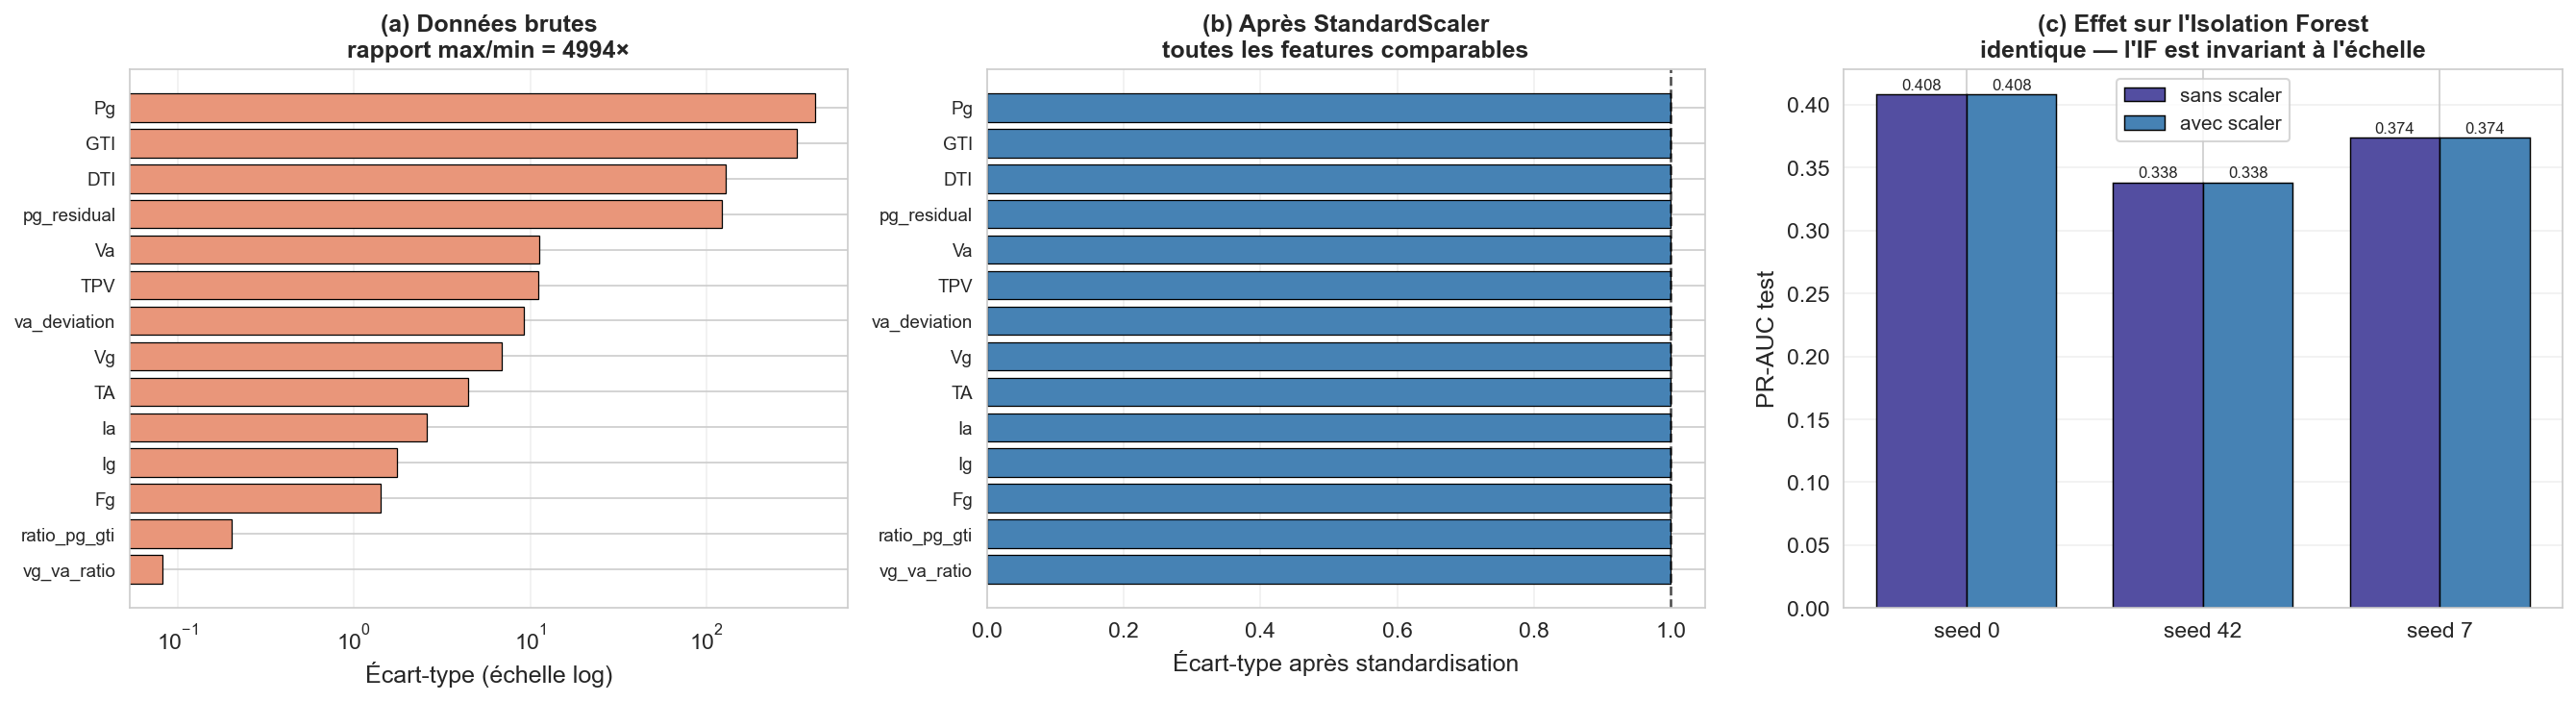

In [298]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- (a) Échelles brutes : disparité énorme entre features ---
ax = axes[0]
ecarts = train_c[FEATURES_ML].std().sort_values(ascending=True)
ax.barh(range(len(ecarts)), ecarts.values, color="#E9967A", edgecolor="black", linewidth=0.6)
ax.set_yticks(range(len(ecarts))); ax.set_yticklabels(ecarts.index, fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Écart-type (échelle log)")
ax.set_title(f"(a) Données brutes\nrapport max/min = {ecarts.max()/ecarts.min():.0f}×",
             fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

ax = axes[1]
ec_std = pd.Series(Xtr["Outlier"].std(axis=0),
                   index=FEATURES_ML).loc[ecarts.index]
ax.barh(range(len(ec_std)), ec_std.values, color="#4682B4", edgecolor="black", linewidth=0.6)
ax.set_yticks(range(len(ec_std))); ax.set_yticklabels(ec_std.index, fontsize=9)
ax.axvline(1.0, color="black", ls="--", lw=1.2, alpha=0.7)
ax.set_xlabel("Écart-type après standardisation")
ax.set_title("(b) Après StandardScaler\ntoutes les features comparables",
             fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

ax = axes[2]
seeds = [0, 42, 7]
sans, avec = [], []
for s in seeds:
    m1 = IsolationForest(n_estimators=200, max_samples=512, contamination=0.01,
                         random_state=s, n_jobs=-1).fit(train_normal_c[FEATURES_ML].values)
    m2 = IsolationForest(n_estimators=200, max_samples=512, contamination=0.01,
                         random_state=s, n_jobs=-1).fit(Xtr["Novelty"])
    sans.append(average_precision_score(y_test, -m1.score_samples(test_c[FEATURES_ML].values)))
    avec.append(average_precision_score(y_test, -m2.score_samples(Xte["Novelty"])))
x = np.arange(len(seeds)); w = 0.38
b1 = ax.bar(x - w/2, sans, w, label="sans scaler", color="#534EA1", edgecolor="black", linewidth=0.7)
b2 = ax.bar(x + w/2, avec, w, label="avec scaler", color="#4682B4", edgecolor="black", linewidth=0.7)
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.004,
                f"{b.get_height():.3f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f"seed {s}" for s in seeds])
ax.set_ylabel("PR-AUC test")
ax.set_title("(c) Effet sur l'Isolation Forest\nidentique — l'IF est invariant à l'échelle",
             fontsize=12, fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [142]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score, f1_score)

SCALERS = {"Novelty": scaler_novelty, "Outlier": scaler_outlier}

Xtr = {"Novelty": scaler_novelty.transform(train_normal_c[FEATURES_ML]),
       "Outlier": scaler_outlier.transform(train_c[FEATURES_ML])}
Xva = {k: s.transform(val_c[FEATURES_ML])  for k, s in SCALERS.items()}
Xte = {k: s.transform(test_c[FEATURES_ML]) for k, s in SCALERS.items()}

y_val  = (val_c["Fault"]  != 0).astype(int).values
y_test = (test_c["Fault"] != 0).astype(int).values
f_test = test_c["Fault"].values

contamination_reelle = (train_c["Fault"] != 0).mean()

print("Entraînement")
for k, X in Xtr.items():
    print(f"  {k:8s} : {X.shape[0]:>7,} points")
print(f"\nÉvaluation")
print(f"  val  : {len(y_val):,} points | {y_val.sum():,} anomalies ({100*y_val.mean():.2f}%)")
print(f"  test : {len(y_test):,} points | {y_test.sum():,} anomalies ({100*y_test.mean():.2f}%)")
print(f"\nContamination réelle du train : {contamination_reelle:.4f}")

Entraînement
  Novelty  :   9,584 points
  Outlier  :  10,829 points

Évaluation
  val  : 2,708 points | 65 anomalies (2.40%)
  test : 4,515 points | 184 anomalies (4.08%)

Contamination réelle du train : 0.1150


#### 8.2 Tuning des hyperparamètres  `[VALIDATION — modèle optimisé d'emblée]`

On règle les hyperparamètres **avant** toute caractérisation : les analyses des sections suivantes décriront ainsi le modèle final, pas un brouillon.

**Ce qu'on optimise, et pourquoi :**
- **`max_samples`** — points tirés par arbre. Levier central de l'Isolation Forest (`"auto"`=256 est rarement optimal) : trop petit → arbres instables, trop grand → anomalies noyées (masking).
- **`n_estimators`** — nombre d'arbres. Plus il y en a, plus le score est stable.
- **`max_features`** — features tirées par arbre. En sous-tirer décorrèle les arbres.
- **`contamination`** — seuil de décision. N'affecte pas le classement des points (donc pas le PR-AUC), mais fixe le point de fonctionnement precision/recall ; on le règle sur le F1 validation une fois la structure choisie.

**Critère de structure = PR-AUC validation** (qualité du classement, indépendante du seuil). Les **deux profils sont optimisés séparément** : Novelty s'entraîne sur données saines, Outlier sur tout — ils n'ont aucune raison de partager le même réglage.

=== Novelty — top 3 configs (tri PR-AUC) + recall par type ===
 n_estimators  max_samples  max_features  PR-AUC val  recall_F3.2  recall_F4.0  recall_min
          150         1024           1.0       0.873        0.862        0.747       0.747
          300         2048           0.7       0.872        0.862        0.762       0.762
          150         2048           0.7       0.871        0.862        0.755       0.755
  ✓ Aucune panne sacrifiée par la meilleure config (recall_min ≥ 0.30).
  → structure : n_est=150, max_samples=1024, max_features=1.0 | PR-AUC val 0.8727 | contamination 0.005 (F1 val 0.8180)

=== Outlier — top 3 configs (tri PR-AUC) + recall par type ===
 n_estimators  max_samples  max_features  PR-AUC val  recall_F3.2  recall_F4.0  recall_min
          300          256           1.0       0.831        0.810        0.699       0.699
          150          256           1.0       0.830        0.810        0.690       0.690
          300          128           0.7    

C:\Users\PC\AppData\Local\Temp\ipykernel_18932\3717402569.py:97: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\PC\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


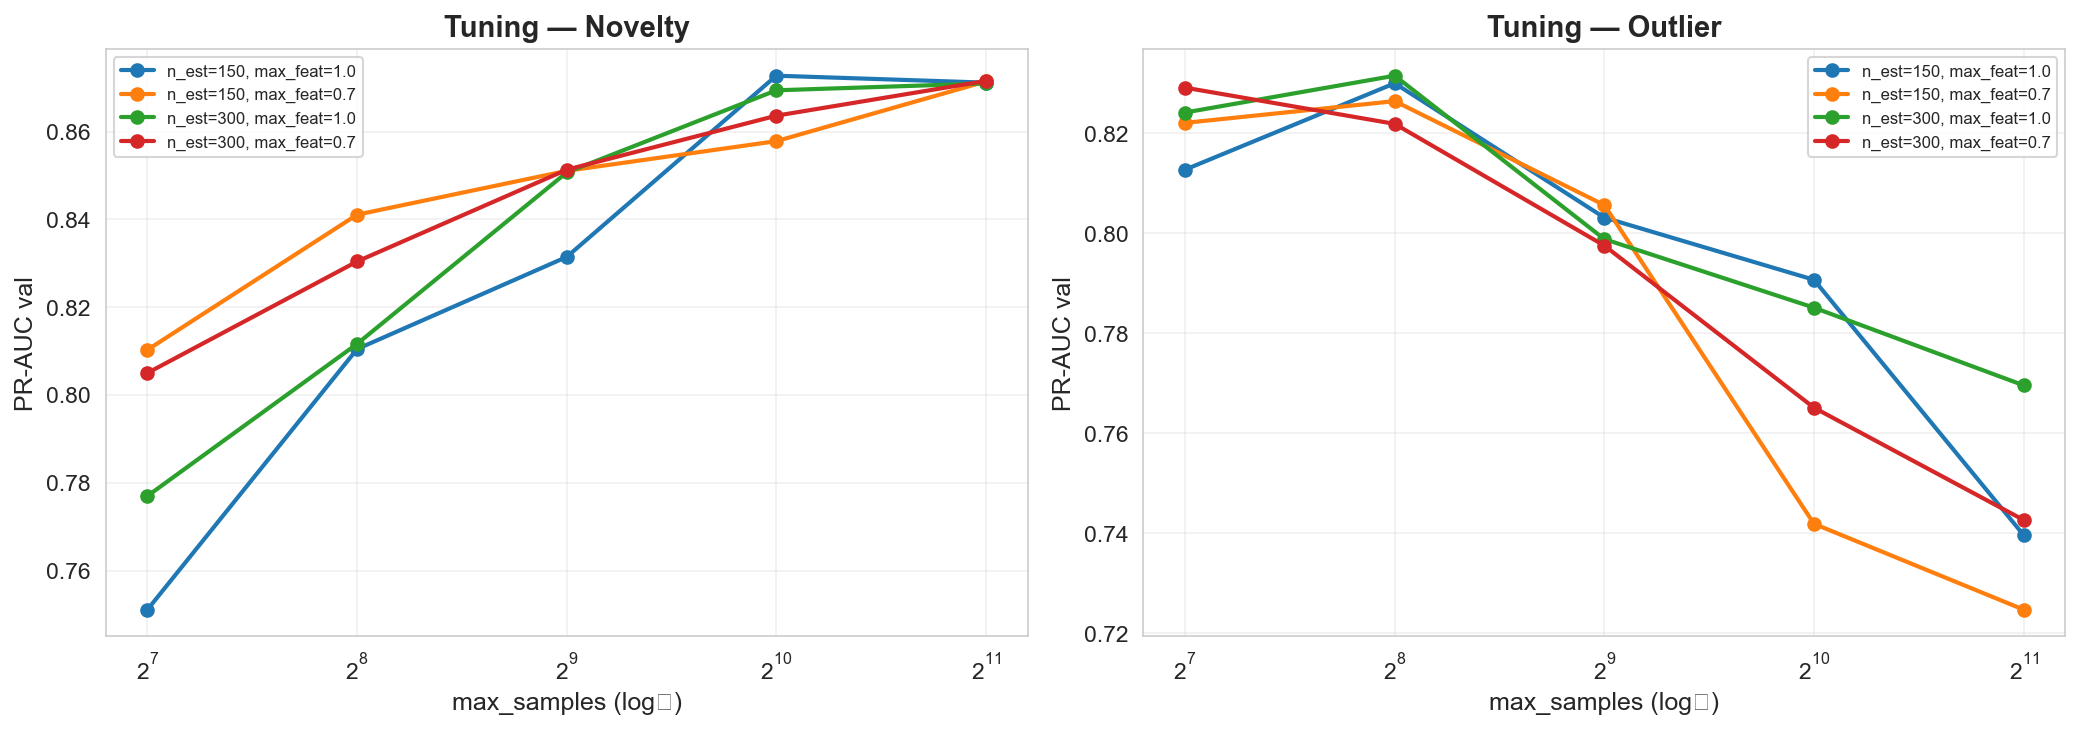

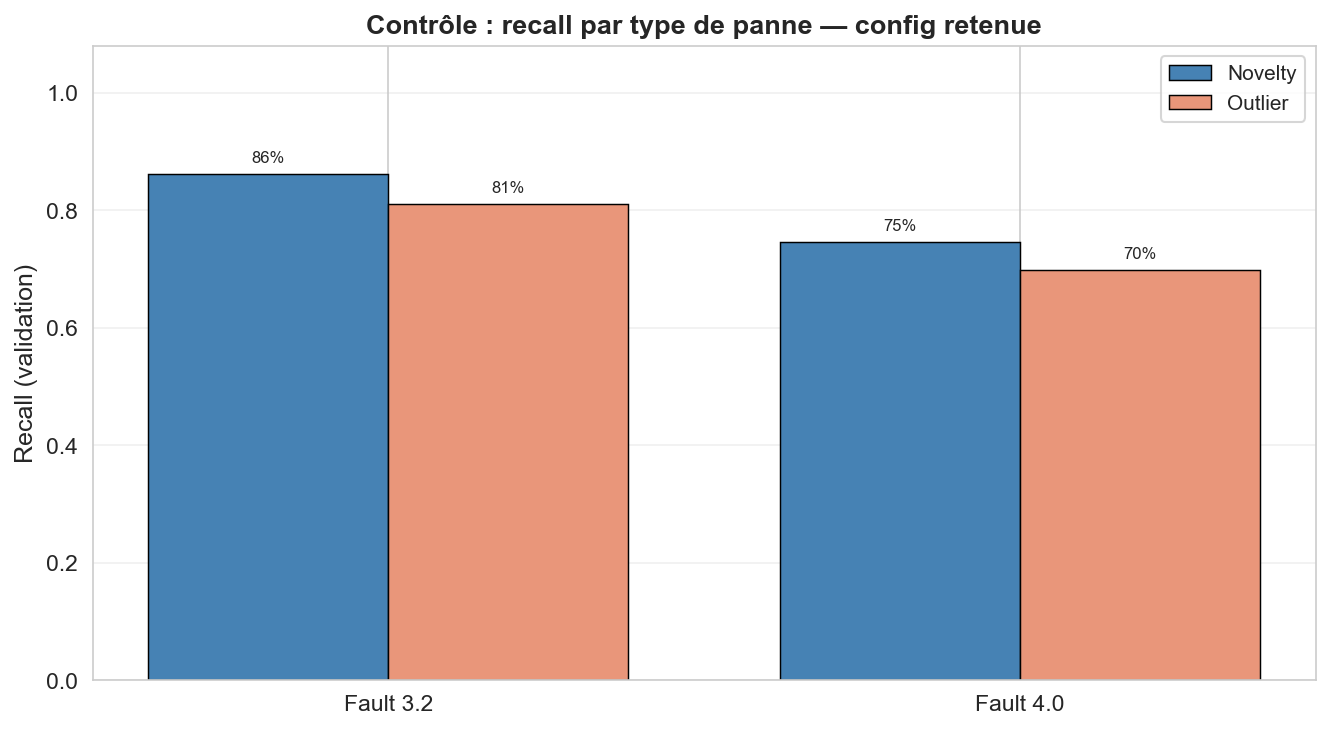

In [301]:
from sklearn.metrics import average_precision_score
from itertools import product

def predire(model, X):
    return (model.predict(X) == -1).astype(int), -model.score_samples(X)

# Fault par ligne en validation (pour le recall par type)
f_val = val_c["Fault"].values
types_val = sorted([f for f in np.unique(f_val) if f != 0])

def recall_par_type(pred, f_arr):
    """Recall par type de panne : part des points d'un type détectés comme anomalie."""
    return {f: pred[f_arr == f].mean() if (f_arr == f).any() else np.nan for f in types_val}

# Grille de STRUCTURE (contamination réglée ensuite, elle ne touche pas le PR-AUC)
GRILLE = {"n_estimators": [150, 300],
          "max_samples":  [128, 256, 512, 1024,2048],
          "max_features": [1.0, 0.7]}

GRILLE_CONTAM = [0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
contamination_defaut = {"Novelty": 0.01, "Outlier": contamination_reelle}

PARAMS_OPT, CONTAM, modeles = {}, {}, {}
tuning_log = {}

for profil in Xtr:
    # --- (1) STRUCTURE : PR-AUC val (critère) + recall par type (contrôle) ---
    lignes = []
    for ne, ms, mf in product(GRILLE["n_estimators"], GRILLE["max_samples"], GRILLE["max_features"]):
        m = IsolationForest(n_estimators=ne, max_samples=ms, max_features=mf,
                            contamination=contamination_defaut[profil],
                            random_state=42, n_jobs=-1).fit(Xtr[profil])
        scores = -m.score_samples(Xva[profil])
        pred   = (m.predict(Xva[profil]) == -1).astype(int)
        pr = average_precision_score(y_val, scores)
        rec = recall_par_type(pred, f_val)
        ligne = {"n_estimators": ne, "max_samples": ms, "max_features": mf, "PR-AUC val": pr}
        for f in types_val:
            ligne[f"recall_F{f}"] = rec[f]
        ligne["recall_min"] = np.nanmin(list(rec.values()))   # panne la plus mal détectée
        lignes.append(ligne)

    df_hp = pd.DataFrame(lignes).sort_values("PR-AUC val", ascending=False).reset_index(drop=True)
    tuning_log[profil] = df_hp
    best = df_hp.iloc[0]

    PARAMS_OPT[profil] = dict(n_estimators=int(best["n_estimators"]),
                              max_samples=int(best["max_samples"]),
                              max_features=float(best["max_features"]),
                              random_state=42, n_jobs=-1)

    # --- Contrôle : recall par type pour le TOP 3 (PR-AUC) ---
    cols_rec = [f"recall_F{f}" for f in types_val]
    print(f"=== {profil} — top 3 configs (tri PR-AUC) + recall par type ===")
    apercu = df_hp.head(3)[["n_estimators","max_samples","max_features","PR-AUC val"] + cols_rec + ["recall_min"]]
    print(apercu.round(3).to_string(index=False))
    # Alerte si la meilleure config rate une panne
    if best["recall_min"] < 0.3:
        pire = min(types_val, key=lambda f: best[f"recall_F{f}"])
        print(f"  ⚠ La config retenue détecte mal Fault {pire} "
              f"(recall {best[f'recall_F{pire}']:.2f}). "
              f"Vérifier si une autre config du top 3 est plus équilibrée.")
    else:
        print("  ✓ Aucune panne sacrifiée par la meilleure config (recall_min ≥ 0.30).")

    # --- (2) CONTAMINATION : F1 val, structure fixée ---
    best_c, best_f1 = contamination_defaut[profil], -1
    for c in GRILLE_CONTAM:
        m = IsolationForest(contamination=c, **PARAMS_OPT[profil]).fit(Xtr[profil])
        p, _ = predire(m, Xva[profil])
        f1 = f1_score(y_val, p)
        if f1 > best_f1:
            best_f1, best_c = f1, c
    CONTAM[profil] = best_c

    # --- (3) modèle final ---
    modeles[profil] = IsolationForest(contamination=CONTAM[profil], **PARAMS_OPT[profil]).fit(Xtr[profil])
    print(f"  → structure : n_est={PARAMS_OPT[profil]['n_estimators']}, "
          f"max_samples={PARAMS_OPT[profil]['max_samples']}, "
          f"max_features={PARAMS_OPT[profil]['max_features']} "
          f"| PR-AUC val {best['PR-AUC val']:.4f} | contamination {CONTAM[profil]:.3f} "
          f"(F1 val {best_f1:.4f})\n")

# --- Figure 1 : effet de max_samples sur PR-AUC val, par profil ---
fig, axes = plt.subplots(1, len(modeles), figsize=(7*len(modeles), 5), squeeze=False)
for ax, profil in zip(axes[0], modeles):
    df_hp = tuning_log[profil]
    for ne in GRILLE["n_estimators"]:
        for mf in GRILLE["max_features"]:
            sub = df_hp[(df_hp["n_estimators"]==ne) & (df_hp["max_features"]==mf)].sort_values("max_samples")
            ax.plot(sub["max_samples"], sub["PR-AUC val"], "o-", lw=2, ms=6,
                    label=f"n_est={ne}, max_feat={mf}")
    ax.set_xscale("log", base=2)
    ax.set_xlabel("max_samples (log₂)"); ax.set_ylabel("PR-AUC val")
    ax.set_title(f"Tuning — {profil}", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Figure 2 : recall par type de panne, config retenue de chaque profil ---
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(types_val)); w = 0.38
for i, profil in enumerate(modeles):
    best = tuning_log[profil].iloc[0]
    vals = [best[f"recall_F{f}"] for f in types_val]
    barres = ax.bar(x + (i-0.5)*w, vals, w, label=profil,
                    color=["#4682B4","#E9967A"][i], edgecolor="black", linewidth=0.7)
    for b in barres:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                f"{b.get_height():.0%}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f"Fault {f}" for f in types_val])
ax.set_ylabel("Recall (validation)"); ax.set_ylim(0, 1.08)
ax.set_title("Contrôle : recall par type de panne — config retenue",
             fontsize=13, fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### 8.3 Prédictions  

`predict()` → −1 (anomalie) / +1 (normal). `score_samples()` inversé → score élevé = anormal (pour ROC/PR et le budget).

In [302]:
pred_val, score_val, pred_test, score_test = {}, {}, {}, {}
for k, m in modeles.items():
    pred_val[k],  score_val[k]  = predire(m, Xva[k])
    pred_test[k], score_test[k] = predire(m, Xte[k])

print(f"Test set — {y_test.sum():,} anomalies réelles\n")
for k in modeles:
    print(f"  {k:8s} prédit {pred_test[k].sum():>6,} anomalies")

Test set — 184 anomalies réelles

  Novelty  prédit    333 anomalies
  Outlier  prédit    400 anomalies


---
### Phase B — Caractérisation des deux profils
---

Cette phase est **entièrement descriptive**. Elle mesure et compare Novelty et Outlier pour comprendre leurs forces respectives. **Aucune décision n'y est prise** : les métriques test affichées ici servent à caractériser, pas à choisir.

#### 8.4 Métriques  

                            TN   FP   FN   TP  Precision  Recall      F1  ROC-AUC  PR-AUC
Split      Configuration                                                                 
Test       Novelty        4700  172   23  161     0.4835  0.8750  0.6228   0.9368  0.4221
           Outlier        4628  244   28  156     0.3900  0.8478  0.5342   0.9279  0.3438
Validation Novelty        3970   53  246  672     0.9269  0.7320  0.8180   0.9324  0.8727
           Outlier        3925   98  261  657     0.8702  0.7157  0.7854   0.9235  0.8315

--- Écarts sur le test (Outlier − Novelty) ---
  Precision  -0.0935   → avantage Novelty
  Recall     -0.0272   → avantage Novelty
  F1         -0.0886   → avantage Novelty
  ROC-AUC    -0.0089   → avantage Novelty
  PR-AUC     -0.0783   → avantage Novelty


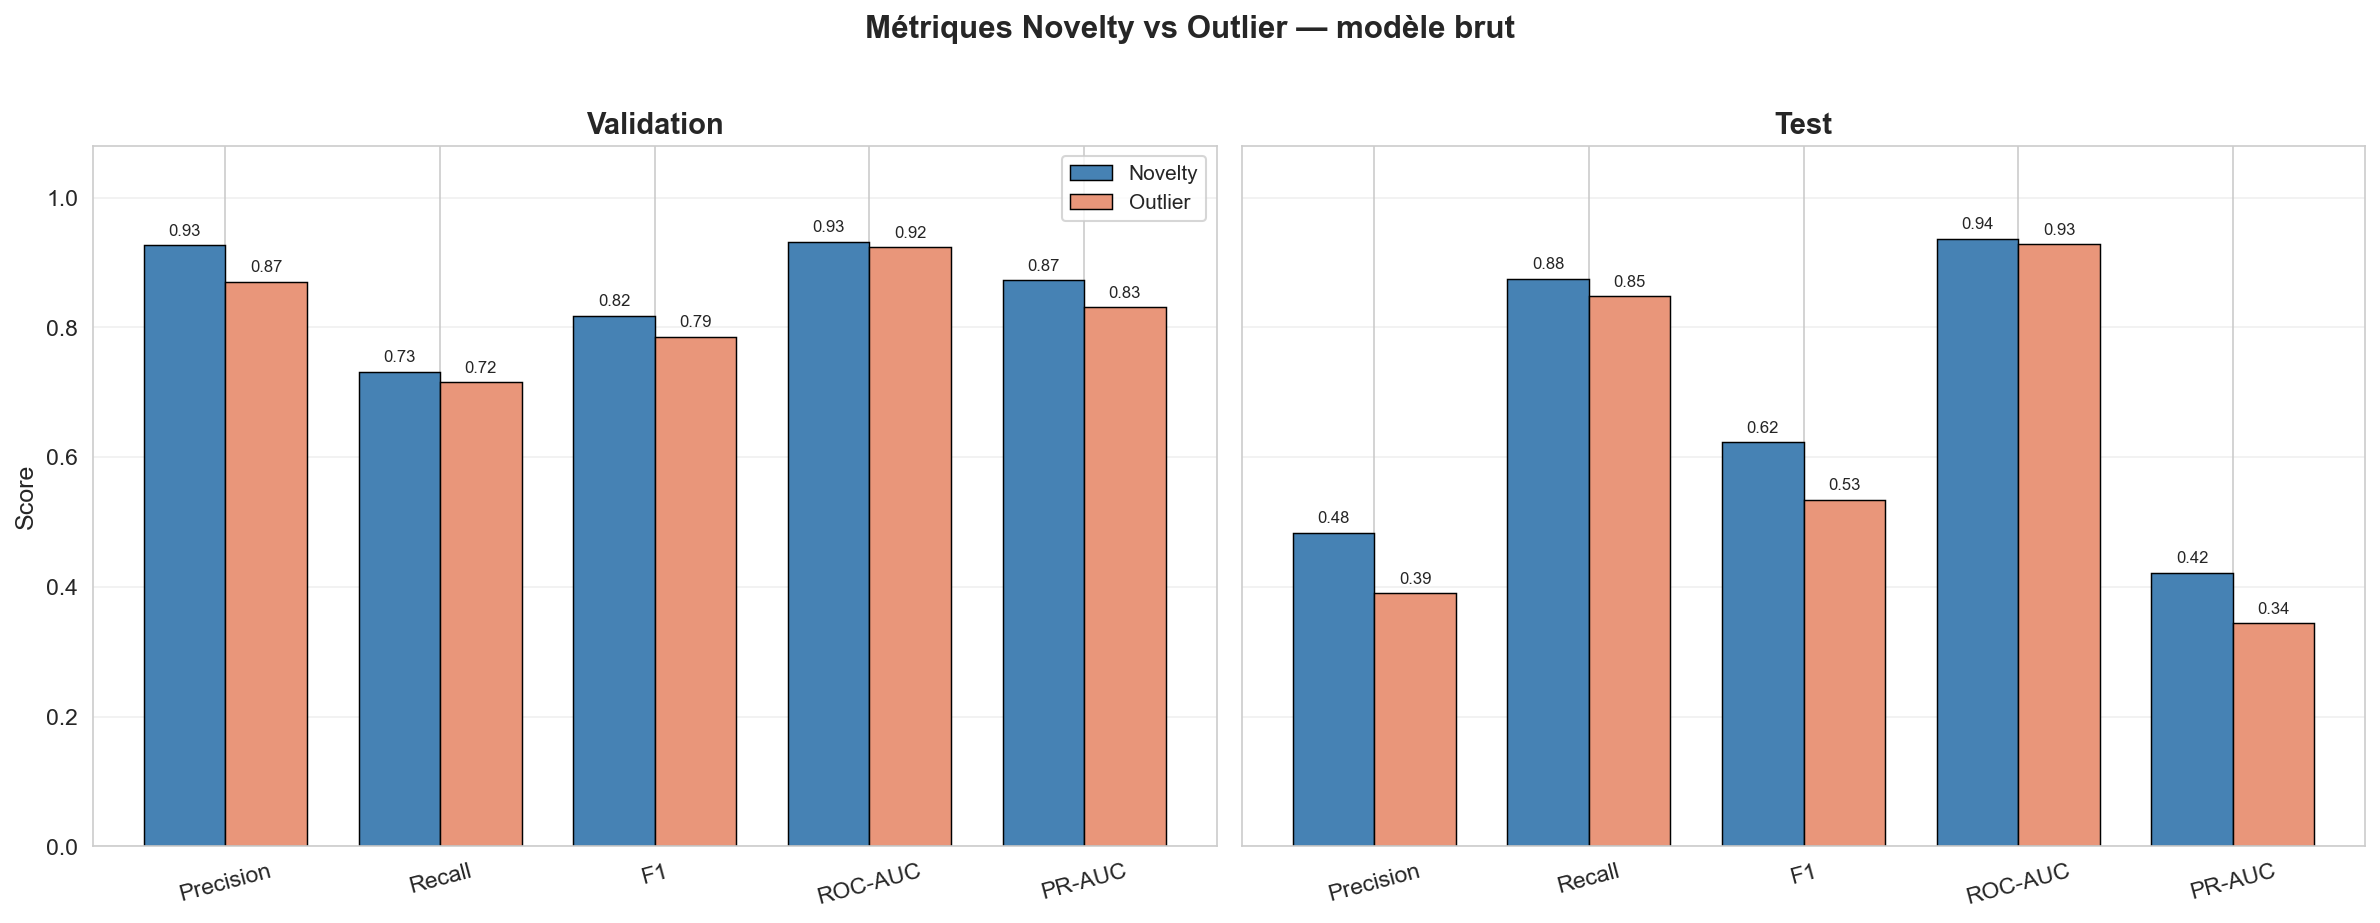

In [303]:
def metriques(y_true, y_pred, scores):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return {"TN": tn, "FP": fp, "FN": fn, "TP": tp,
            "Precision": tp/(tp+fp) if tp+fp else 0.0,
            "Recall":    tp/(tp+fn) if tp+fn else 0.0,
            "F1":        f1_score(y_true, y_pred),
            "ROC-AUC":   roc_auc_score(y_true, scores),
            "PR-AUC":    average_precision_score(y_true, scores)}

M = {}
for k in modeles:
    M[("Validation", k)] = metriques(y_val,  pred_val[k],  score_val[k])
    M[("Test", k)]       = metriques(y_test, pred_test[k], score_test[k])

cols_f = ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
tab = pd.DataFrame(M).T
tab[["TN","FP","FN","TP"]] = tab[["TN","FP","FN","TP"]].astype(int)
tab[cols_f] = tab[cols_f].round(4)
tab.index.names = ["Split", "Configuration"]
print(tab.sort_index().to_string())

print("\n--- Écarts sur le test (Outlier − Novelty) ---")
for k in cols_f:
    d = M[("Test","Outlier")][k] - M[("Test","Novelty")][k]
    print(f"  {k:10s} {d:+.4f}   → avantage {'Outlier' if d > 0 else 'Novelty'}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
x = np.arange(len(cols_f))
w = 0.38

for ax, split in zip(axes, ["Validation", "Test"]):
    for i, k in enumerate(modeles):
        vals = [M[(split, k)][c] for c in cols_f]
        barres = ax.bar(x + (i - 0.5) * w, vals, w, label=k,
                        color=COULEURS[k], edgecolor="black", linewidth=0.7)
        for b, v in zip(barres, vals):
            ax.text(b.get_x() + b.get_width()/2, v + 0.015,
                    f"{v:.2f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(cols_f, rotation=15)
    ax.set_title(split, fontweight="bold")
    ax.set_ylim(0, 1.08)
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("Score")
axes[0].legend(loc="upper right")
fig.suptitle("Métriques Novelty vs Outlier — modèle brut",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_if_00_metriques.png", dpi=150, bbox_inches="tight")
plt.show()

**Note PR-AUC.** Les anomalies étant minoritaires, la ROC-AUC est indulgente. La PR-AUC pénalise les faux positifs proportionnellement à la rareté des positifs : c'est le meilleur critère de séparation du modèle brut.

#### 8.5 Matrices de confusion  `[DESCRIPTIF — test]`

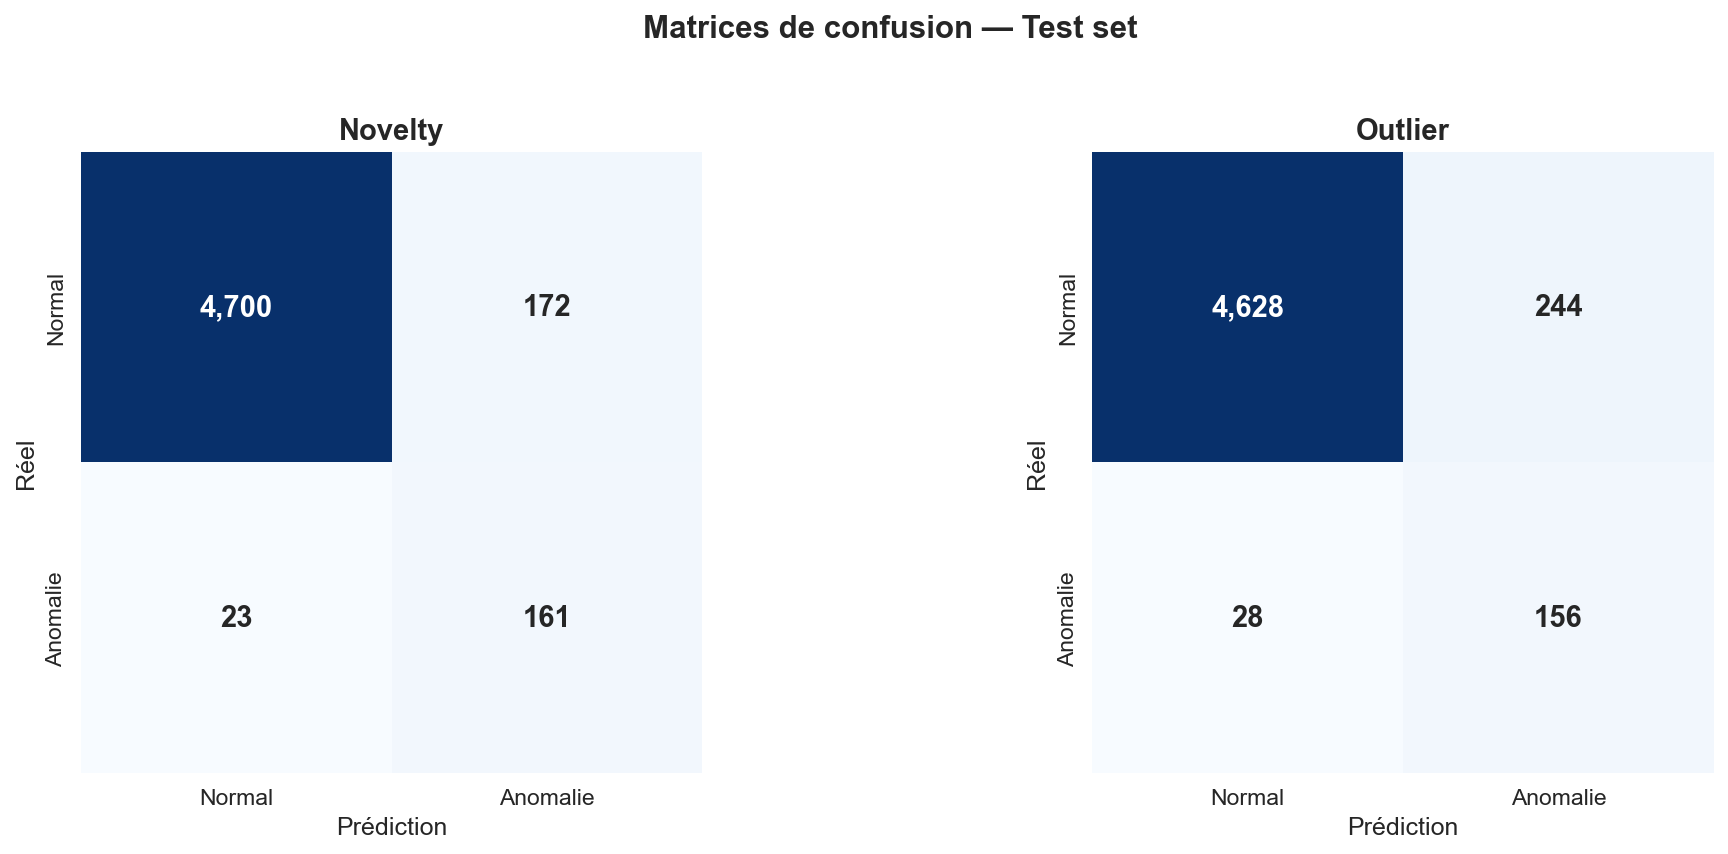

In [304]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, k in zip(axes, modeles):
    cm = confusion_matrix(y_test, pred_test[k], labels=[0,1])
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, square=True,
                xticklabels=["Normal", "Anomalie"], yticklabels=["Normal", "Anomalie"],
                annot_kws={"size": 14, "weight": "bold"}, ax=ax)
    ax.set_title(k, fontweight="bold")
    ax.set_xlabel("Prédiction"); ax.set_ylabel("Réel")
fig.suptitle("Matrices de confusion — Test set", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

#### 8.6 Courbes ROC et Precision-Recall  `[DESCRIPTIF — test]`

Évaluent la capacité à ordonner les points, indépendamment du seuil de décision.

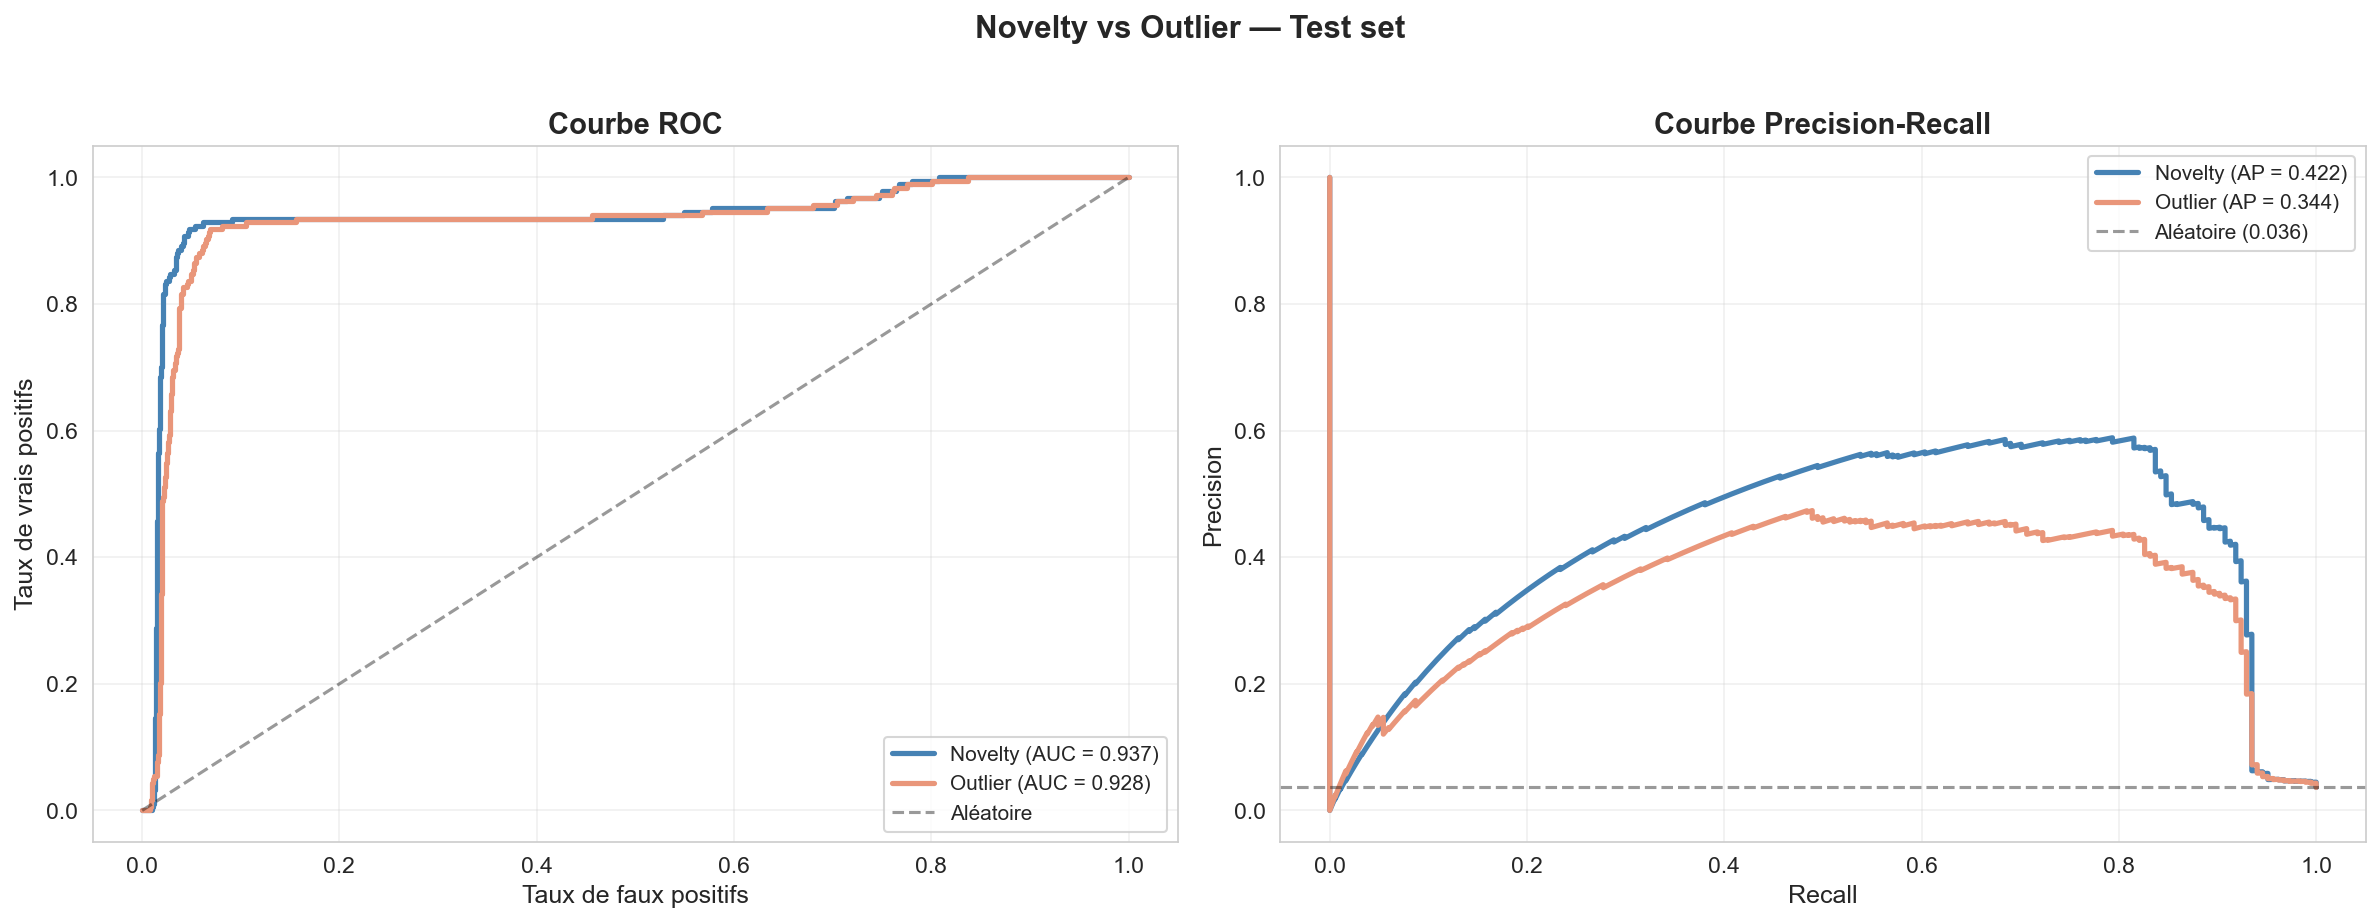

In [305]:
COULEURS = {"Novelty": "#4682B4", "Outlier": "#E9967A"}
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for k in modeles:
    fpr, tpr, _ = roc_curve(y_test, score_test[k])
    axes[0].plot(fpr, tpr, color=COULEURS[k], linewidth=2.5,
                 label=f"{k} (AUC = {M[('Test',k)]['ROC-AUC']:.3f})")
    prec, rec, _ = precision_recall_curve(y_test, score_test[k])
    axes[1].plot(rec, prec, color=COULEURS[k], linewidth=2.5,
                 label=f"{k} (AP = {M[('Test',k)]['PR-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Aléatoire")
axes[0].set_xlabel("Taux de faux positifs"); axes[0].set_ylabel("Taux de vrais positifs")
axes[0].set_title("Courbe ROC", fontweight="bold")
axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)
axes[1].axhline(y_test.mean(), color="black", linestyle="--", alpha=0.4,
                label=f"Aléatoire ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Courbe Precision-Recall", fontweight="bold")
axes[1].legend(); axes[1].grid(alpha=0.3)
fig.suptitle("Novelty vs Outlier — Test set", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_if_02_roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()

#### 8.7 Séparation des distributions de scores  `[DESCRIPTIF — test]`

Moins les distributions normal/anomalie se chevauchent, meilleure est la séparation.

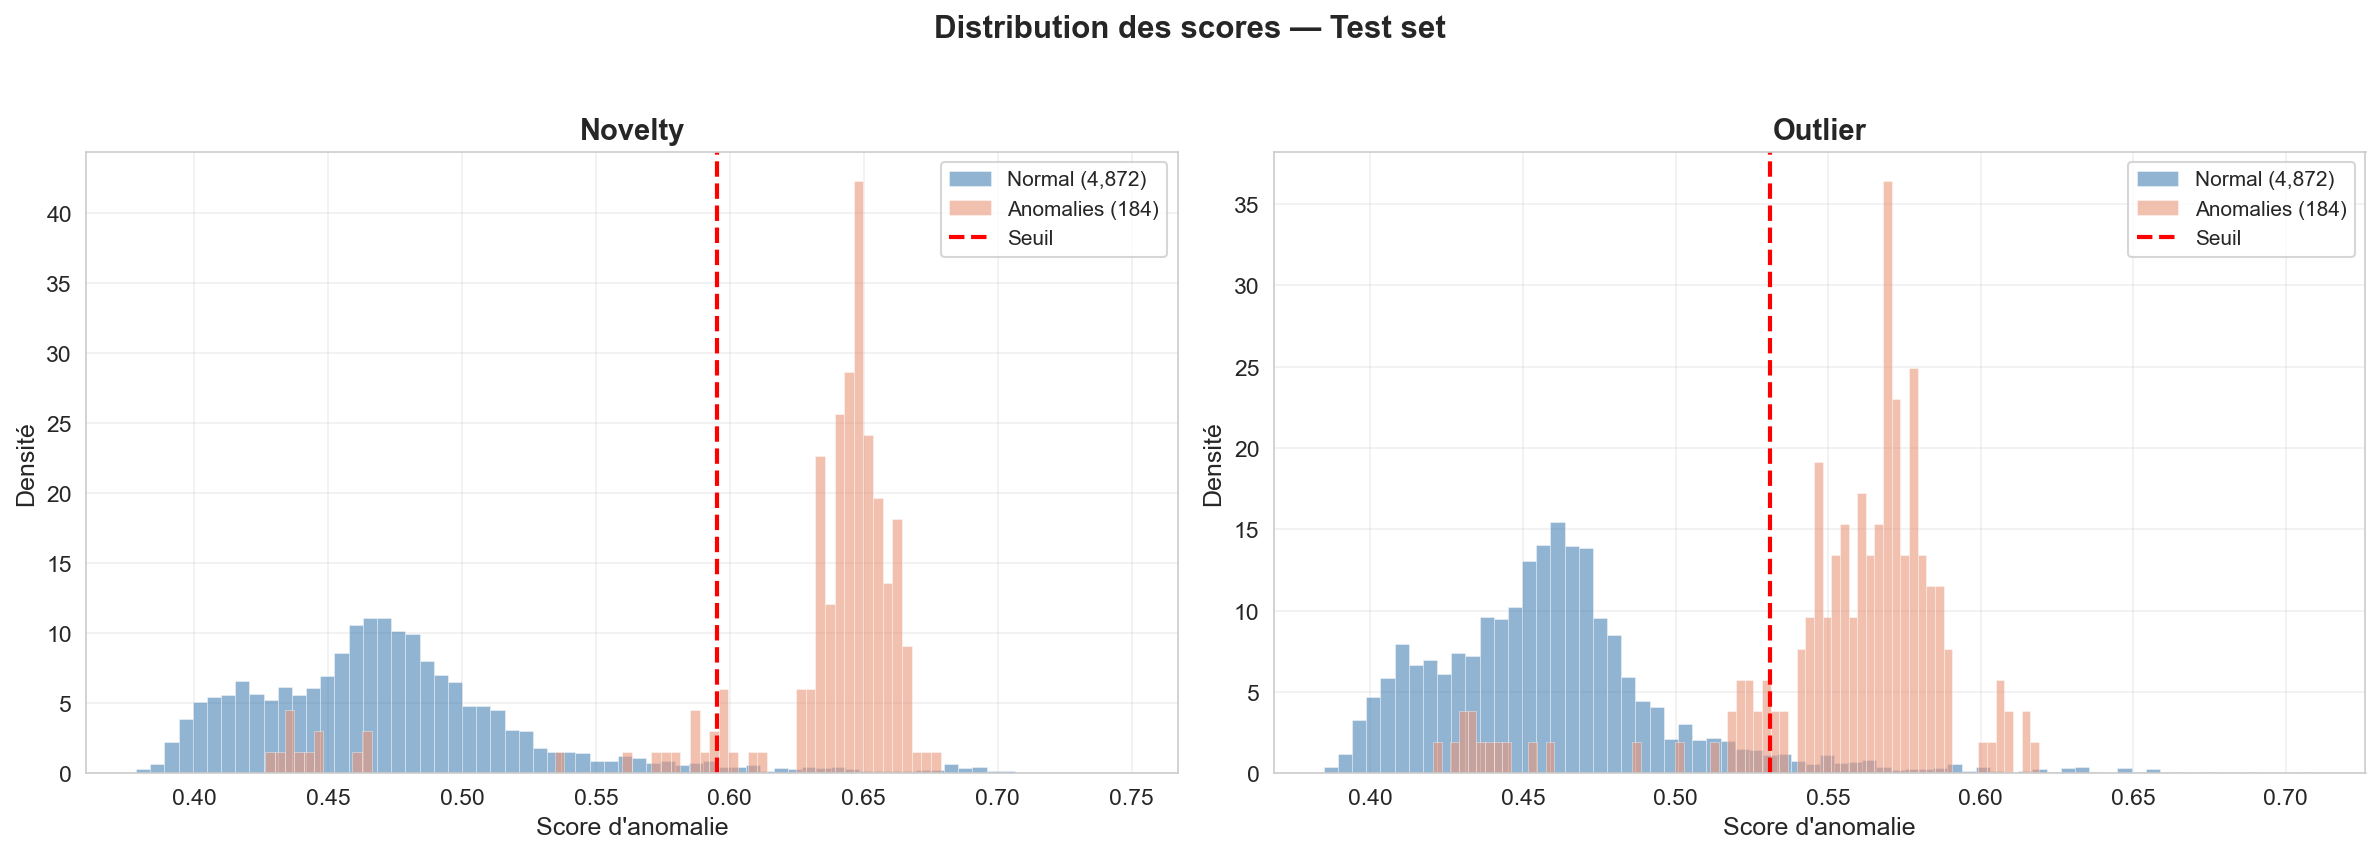

Écart des moyennes (en σ des points normaux) :
  Novelty  : 2.921 σ
  Outlier  : 2.399 σ


In [306]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ax, k in zip(axes, modeles):
    s = score_test[k]
    s_n, s_a = s[y_test == 0], s[y_test == 1]
    ax.hist(s_n, bins=70, alpha=0.6, color="#4682B4", density=True,
            label=f"Normal ({len(s_n):,})", edgecolor="white", linewidth=0.3)
    ax.hist(s_a, bins=70, alpha=0.6, color="#E9967A", density=True,
            label=f"Anomalies ({len(s_a):,})", edgecolor="white", linewidth=0.3)
    ax.axvline(-modeles[k].offset_, color="red", linestyle="--", linewidth=2, label="Seuil")
    ax.set_xlabel("Score d'anomalie"); ax.set_ylabel("Densité")
    ax.set_title(k, fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Distribution des scores — Test set", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("figures/fig_if_03_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("Écart des moyennes (en σ des points normaux) :")
for k in modeles:
    s = score_test[k]
    s_n, s_a = s[y_test == 0], s[y_test == 1]
    print(f"  {k:8s} : {(s_a.mean() - s_n.mean()) / s_n.std():.3f} σ")

#### 8.8 Détection par type de panne  `[DESCRIPTIF — test]`

Point clé pour la fusion : les pannes subtiles (Fault 3.1/3.2, ombrage partiel) départagent les profils. Un profil fort sur ces pannes est un bon candidat pour **compléter** le LSTM/AE.

 Fault  Occurrences  Recall Novelty  Recall Outlier   Écart
   3.1           73          0.9041          0.8630 -0.0411
   3.2           56          0.9821          0.9643 -0.0179
   4.0           55          0.7273          0.7091 -0.0182


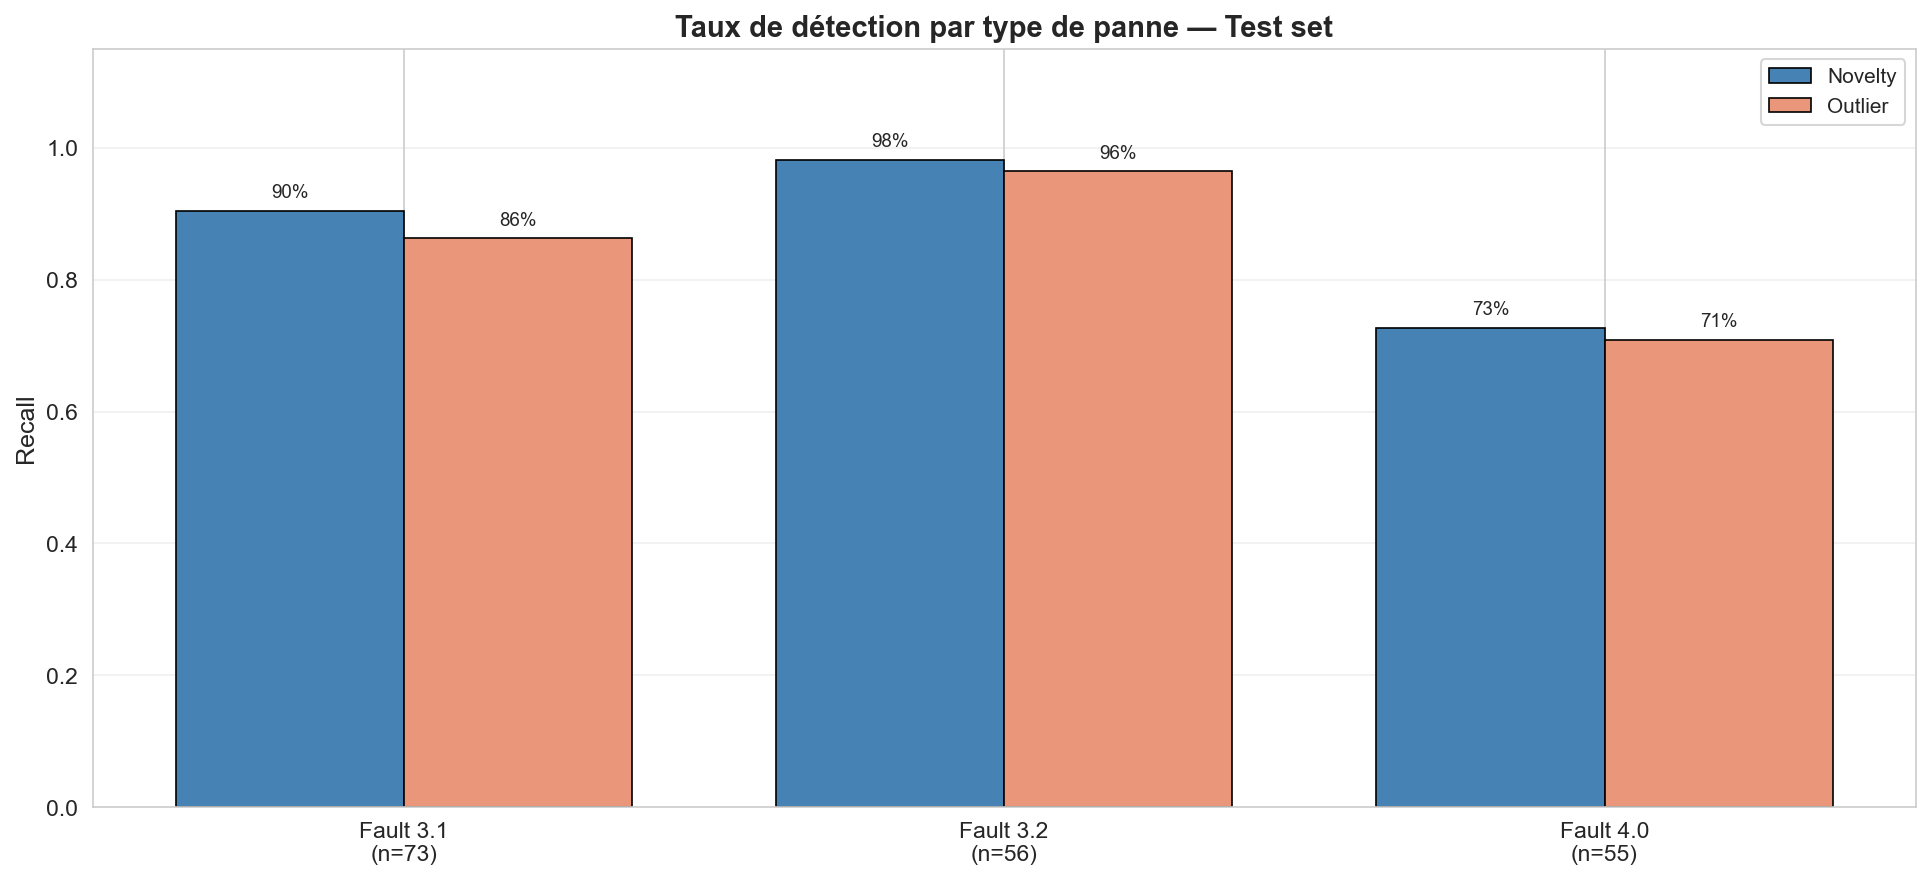

In [310]:
types = sorted([f for f in np.unique(f_test) if f != 0])

lignes = []
for f in types:
    msk = f_test == f
    ligne = {"Fault": f, "Occurrences": int(msk.sum())}
    for k in modeles:
        ligne[f"Recall {k}"] = pred_test[k][msk].mean()
    lignes.append(ligne)
df_types = pd.DataFrame(lignes)
df_types["Écart"] = df_types["Recall Outlier"] - df_types["Recall Novelty"]
print(df_types.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 6))
x, w = np.arange(len(types)), 0.38
for i, k in enumerate(modeles):
    barres = ax.bar(x + (i - 0.5) * w, df_types[f"Recall {k}"], w, label=k,
                    color=COULEURS[k], edgecolor="black", linewidth=0.8)
    for b in barres:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
                f"{b.get_height():.0%}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([f"Fault {f}\n(n={n:,})" for f, n in zip(types, df_types["Occurrences"])])
ax.set_ylabel("Recall")
ax.set_title("Taux de détection par type de panne — Test set", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.15); ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig_if_04_recall_par_panne.png", dpi=150, bbox_inches="tight")
plt.show()

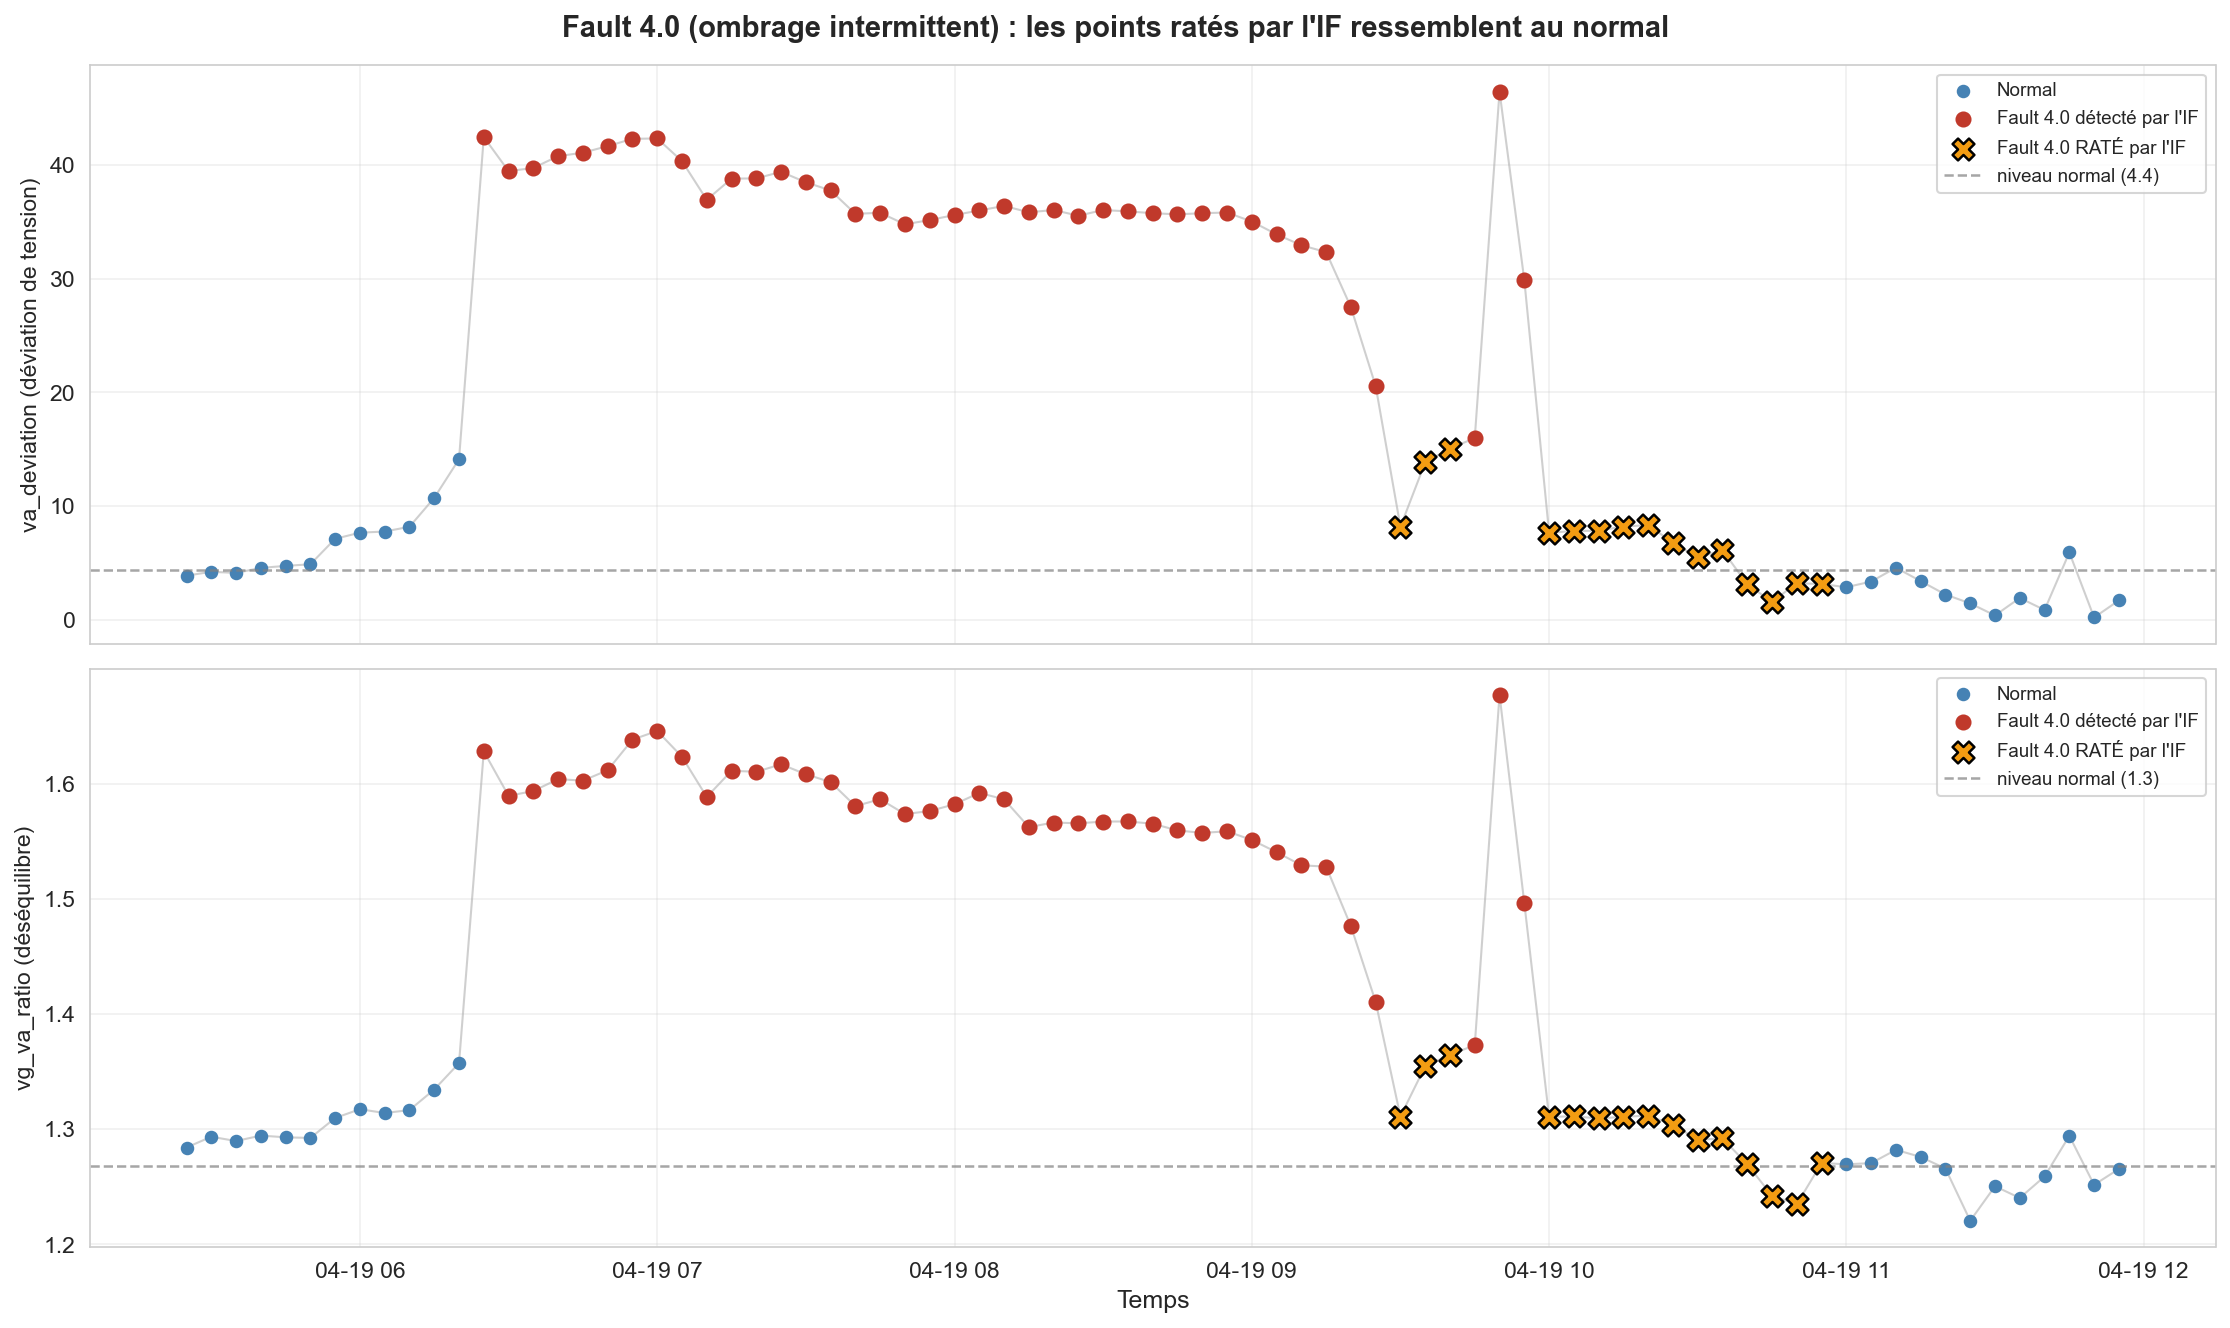

Épisode Fault 4.0 : 55 points, 15 ratés par l'IF

                      détectés     ratés    normal
va_deviation             35.96      7.66      4.40
vg_va_ratio               1.58      1.31      1.27


In [ ]:
# =============================================================
# Pourquoi l'IF rate certains Fault 4.0 : ils ressemblent au normal
# =============================================================


# Prédictions du modèle Novelty sur le test (déjà entraîné)
pred_te = (modeles["Novelty"].predict(Xte["Novelty"]) == -1).astype(int)
test_pred = test_c.copy()
test_pred["pred"] = pred_te

# Épisode Fault 4.0 du test + 1h de marge
f4 = test_pred[test_pred["Fault"] == 4.0]
s, e = f4.index.min(), f4.index.max()
w = test_pred[s - pd.Timedelta("1h"): e + pd.Timedelta("1h")]

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
fig.suptitle("Fault 4.0 (ombrage intermittent) : les points ratés par l'IF ressemblent au normal",
             fontsize=14, fontweight="bold")

for ax, feat, ylabel in zip(axes,
                             ["va_deviation", "vg_va_ratio"],
                             ["va_deviation (déviation de tension)", "vg_va_ratio (déséquilibre)"]):
    normal_med = train_normal_c[feat].median()

    m_ok   = w["Fault"] == 0                                  # points normaux
    m_det  = (w["Fault"] == 4.0) & (w["pred"] == 1)           # Fault 4.0 DÉTECTÉS
    m_miss = (w["Fault"] == 4.0) & (w["pred"] == 0)           # Fault 4.0 RATÉS

    # Ligne continue du signal
    ax.plot(w.index, w[feat], "-", color="#B0B0B0", lw=1, alpha=0.6, zorder=1)

    # Points par catégorie
    ax.scatter(w.index[m_ok],  w[feat][m_ok],  s=30, color="#4682B4",
               label="Normal", zorder=2)
    ax.scatter(w.index[m_det], w[feat][m_det], s=45, color="#C0392B",
               label="Fault 4.0 détecté par l'IF", zorder=3)
    ax.scatter(w.index[m_miss], w[feat][m_miss], s=110, marker="X",
               color="#F39C12", edgecolor="black", linewidth=1.2,
               label="Fault 4.0 RATÉ par l'IF", zorder=4)

    # Niveau normal
    ax.axhline(normal_med, color="gray", ls="--", lw=1.2, alpha=0.7,
               label=f"niveau normal ({normal_med:.1f})")

    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Temps")
plt.tight_layout()
plt.savefig("figures/fig_fault4_rates_if.png", dpi=150, bbox_inches="tight")
plt.show()

# Chiffres à l'appui
det  = f4[f4["pred"] == 1]
miss = f4[f4["pred"] == 0]
print(f"Épisode Fault 4.0 : {len(f4)} points, {len(miss)} ratés par l'IF\n")
print(f"{'':20}{'détectés':>10}{'ratés':>10}{'normal':>10}")
for feat in ["va_deviation", "vg_va_ratio"]:
    print(f"{feat:20}{det[feat].median():>10.2f}{miss[feat].median():>10.2f}"
          f"{train_normal_c[feat].median():>10.2f}")

# =============================================================
#  Export de la brique IF pour la fusion
# =============================================================

In [316]:

# On sauvegarde tout ce dont la fusion (avec AE et LSTM) aura besoin :
# le modèle, le scaler, la liste des features, le seuil de décision, et les
# scores d'anomalie sur val/test (pour calibrer la fusion sans réentraîner).
import os, joblib, json

os.makedirs("models/if", exist_ok=True)

PROFIL = "Novelty"   # profil retenu pour le déploiement

# 1. Le modèle et le scaler (objets sklearn) → joblib
joblib.dump(modeles[PROFIL],  "models/if/if_model.joblib")
joblib.dump(SCALERS[PROFIL],  "models/if/if_scaler.joblib")

# 2. Les métadonnées (features, hyperparamètres, seuil) → JSON lisible
#    Le seuil = score à partir duquel on déclare une anomalie (via contamination)
seuil = np.quantile(-modeles[PROFIL].score_samples(Xtr[PROFIL]), 1 - CONTAM[PROFIL])
meta = {
    "profil": PROFIL,
    "features": FEATURES_ML,
    "n_features": len(FEATURES_ML),
    "hyperparametres": {k: v for k, v in PARAMS_OPT[PROFIL].items() if k != "n_jobs"},
    "contamination": CONTAM[PROFIL],
    "seuil_score": float(seuil),
    "perf_test": {
        "recall": float(metriques_test["Recall"][PROFIL]) if "metriques_test" in dir() else None,
        "pr_auc": float(average_precision_score(y_test, -modeles[PROFIL].score_samples(Xte[PROFIL]))),
    },
}
with open("models/if/if_meta.json", "w") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

# 3. Les SCORES d'anomalie sur val et test (indexés par timestamp) → pour la fusion
#    La fusion combinera ces scores avec ceux de l'AE et du LSTM.
scores_val  = pd.Series(-modeles[PROFIL].score_samples(Xva[PROFIL]), index=val_c.index,  name="score_if")
scores_test = pd.Series(-modeles[PROFIL].score_samples(Xte[PROFIL]), index=test_c.index, name="score_if")
scores_val.to_csv("models/if/if_scores_val.csv")
scores_test.to_csv("models/if/if_scores_test.csv")

print("Brique IF exportée dans models/if/ :")
print(f"  if_model.joblib      — modèle {PROFIL}")
print(f"  if_scaler.joblib     — StandardScaler ({len(FEATURES_ML)} features)")
print(f"  if_meta.json         — features, hyperparamètres, seuil={seuil:.4f}")
print(f"  if_scores_val.csv    — {len(scores_val)} scores (pour calibrer la fusion)")
print(f"  if_scores_test.csv   — {len(scores_test)} scores (pour évaluer la fusion)")
print(f"\nPR-AUC test de la brique : {meta['perf_test']['pr_auc']:.4f}")

Brique IF exportée dans models/if/ :
  if_model.joblib      — modèle Novelty
  if_scaler.joblib     — StandardScaler (14 features)
  if_meta.json         — features, hyperparamètres, seuil=0.5952
  if_scores_val.csv    — 4941 scores (pour calibrer la fusion)
  if_scores_test.csv   — 5056 scores (pour évaluer la fusion)

PR-AUC test de la brique : 0.4221


In [339]:
# =============================================================
#  A — Vérification de l'état mémoire AVANT export
# =============================================================
ATTENDU = {"train_c": 8060, "val_c": 4941, "test_c": 5056}
REQUIS = ["FEATURES_ML", "train_c", "val_c", "test_c", "train_normal_c",
          "Xtr", "Xva", "Xte", "SCALERS", "y_val", "y_test"]

manquants = [n for n in REQUIS if n not in globals()]
if manquants:
    raise NameError(f"Variables absentes : {manquants}\n"
                    "→ Réexécute le split (cellules 74-76) puis la normalisation (7bis).")

erreurs = [f"{n} : {len(globals()[n]):,} lignes (attendu {k:,})"
           for n, k in ATTENDU.items() if len(globals()[n]) != k]
if erreurs:
    raise ValueError("Split en mémoire ≠ split final :\n  " + "\n  ".join(erreurs) +
                     "\n→ Tu es sur l'ancien 70/10/20. Réexécute 74-76 puis 7bis.")

try:
    import pyarrow; FORMAT = "parquet"
except ImportError:
    FORMAT = "csv"

print(f"État mémoire OK — {len(FEATURES_ML)} features, format = {FORMAT}")
print(f"  train {len(train_c):,} | val {len(val_c):,} | test {len(test_c):,} "
      f"| train_normal {len(train_normal_c):,}")
print(f"  profils : {list(SCALERS.keys())}")

État mémoire OK — 14 features, format = parquet
  train 8,060 | val 4,941 | test 5,056 | train_normal 7,668
  profils : ['Novelty', 'Outlier']


In [340]:
# =============================================================
#  B — Gel du dataset ML
# =============================================================
import os, json, joblib, pandas as pd

os.makedirs("data/processed", exist_ok=True)
os.makedirs("models/dataset", exist_ok=True)

COLS = list(FEATURES_ML) + ["Fault"]

def _ecrire(df, nom):
    df = df.copy(); df.index.name = "time"
    if FORMAT == "parquet":
        df.to_parquet(f"data/processed/{nom}.parquet")
    else:
        df.to_csv(f"data/processed/{nom}.csv")
    return df

meta_splits = {}
for nom, d in {"train": train_c, "val": val_c, "test": test_c}.items():
    sub = _ecrire(d[COLS], nom)
    meta_splits[nom] = {
        "lignes": int(len(sub)),
        "debut": str(sub.index.min()), "fin": str(sub.index.max()),
        "anomalies": int((sub["Fault"] != 0).sum()),
        "taux_anomalies": round(float((sub["Fault"] != 0).mean()), 4),
        "types_pannes": {str(k): int(v) for k, v in
                         sub.loc[sub["Fault"] != 0, "Fault"].value_counts().sort_index().items()},
    }

tn = _ecrire(train_normal_c[COLS], "train_normal")

for profil, sc in SCALERS.items():
    joblib.dump(sc, f"models/dataset/scaler_{profil.lower()}.joblib")

meta = {
    "features_ml": list(FEATURES_ML),
    "n_features": len(FEATURES_ML),
    "colonne_label": "Fault",
    "regle_label_binaire": "y = (Fault != 0).astype(int)",
    "format": FORMAT,
    "periode_etude": {"debut": str(train_c.index.min()), "fin": str(test_c.index.max())},
    "splits": meta_splits,
    "train_normal": {"lignes": int(len(tn)),
                     "usage": "entrainement Novelty / Autoencoder / LSTM-AE"},
    "scalers": {p: f"models/dataset/scaler_{p.lower()}.joblib" for p in SCALERS},
    "note": ("Splits chronologiques sur periode tronquee (arret 7j apres la derniere anomalie). "
             "Scaler Novelty ajuste sur train_normal, scaler Outlier sur train complet. "
             "Ne JAMAIS reajuster un scaler sur val/test. "
             "Serie non continue (jour uniquement, pas 5min) : verifier les trous avant "
             "de construire des sequences LSTM."),
}
with open("models/dataset/dataset_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print("Dataset gelé dans data/processed/ :")
for nom, m in meta_splits.items():
    print(f"  {nom:12s} {m['lignes']:>6,} lignes | {m['anomalies']:>4} anos "
          f"({m['taux_anomalies']:6.2%}) | {m['debut'][:10]} → {m['fin'][:10]}")
print(f"  {'train_normal':12s} {len(tn):>6,} lignes")
print("\nScalers + manifeste → models/dataset/")

Dataset gelé dans data/processed/ :
  train         8,060 lignes |  392 anos ( 4.86%) | 2021-10-28 → 2022-02-23
  val           4,941 lignes |  918 anos (18.58%) | 2022-02-23 → 2022-04-11
  test          5,056 lignes |  184 anos ( 3.64%) | 2022-04-11 → 2022-05-26
  train_normal  7,668 lignes

Scalers + manifeste → models/dataset/


In [341]:
# =============================================================
#  C — Vérification : le rechargement reproduit-il Xtr/Xva/Xte ?
# =============================================================
import numpy as np, json, joblib, pandas as pd

meta_v = json.load(open("models/dataset/dataset_meta.json", encoding="utf-8"))
FEATS = meta_v["features_ml"]

def charger(nom):
    if meta_v["format"] == "parquet":
        df = pd.read_parquet(f"data/processed/{nom}.parquet")
    else:
        df = pd.read_csv(f"data/processed/{nom}.csv", index_col="time")
        df.index = pd.to_datetime(df.index, utc=True)
    return df

d  = {n: charger(n) for n in ["train", "val", "test", "train_normal"]}
sc = {p: joblib.load(c) for p, c in meta_v["scalers"].items()}

ok = True
for profil in sc:
    base = d["train_normal"] if profil == "Novelty" else d["train"]
    for nom, df_, X_ref in [("train", base, Xtr[profil]),
                            ("val", d["val"], Xva[profil]),
                            ("test", d["test"], Xte[profil])]:
        X_new = sc[profil].transform(df_[FEATS])
        delta = np.abs(X_new - np.asarray(X_ref)).max()
        identique = delta < 1e-8
        ok &= identique
        print(f"  {profil:8s} {nom:6s} : {'OK   ' if identique else 'ÉCART'} | max Δ = {delta:.2e}")

y_ok = np.array_equal((d["test"]["Fault"] != 0).astype(int).values, np.asarray(y_test))
print(f"  labels test        : {'OK' if y_ok else 'ÉCART'}")

print("\n" + ("Dataset gelé et vérifié — l'Autoencoder peut démarrer."
              if ok and y_ok else "ÉCART détecté — stop, on corrige avant de continuer."))

  Novelty  train  : OK    | max Δ = 0.00e+00
  Novelty  val    : OK    | max Δ = 0.00e+00
  Novelty  test   : OK    | max Δ = 0.00e+00
  Outlier  train  : OK    | max Δ = 0.00e+00
  Outlier  val    : OK    | max Δ = 0.00e+00
  Outlier  test   : OK    | max Δ = 0.00e+00
  labels test        : OK

Dataset gelé et vérifié — l'Autoencoder peut démarrer.


In [342]:
import sys; sys.path.insert(0, ".")
import numpy as np
from src import dataset as ds

print("features :", len(ds.features()), "| identiques à FEATURES_ML :",
      ds.features() == list(FEATURES_ML))

ok = True
for profil in ["Novelty", "Outlier"]:
    for nom, X_ref in [("train_normal" if profil == "Novelty" else "train", Xtr[profil]),
                       ("val", Xva[profil]), ("test", Xte[profil])]:
        X, y, f, idx = ds.charger(nom, profil)
        d = np.abs(X - np.asarray(X_ref)).max()
        ok &= d < 1e-8
        print(f"  {profil:8s} {nom:13s} : max Δ = {d:.2e}")

# Segments continus : combien de blocs, et de quelle taille ?
_, _, _, idx_tr = ds.charger("train")
blocs = ds.segments_continus(idx_tr)
tailles = np.array([b - a for a, b in blocs])
print(f"\ntrain : {len(blocs)} segments continus | "
      f"médiane {np.median(tailles):.0f} pas | min {tailles.min()} | max {tailles.max()}")

S, fins = ds.sequences(*ds.charger("train")[:1], longueur=12, index=idx_tr)
naif = len(idx_tr) - 12
print(f"séquences (12 pas) : {len(S):,} valides vs {naif:,} en découpage naïf "
      f"→ {naif - len(S):,} séquences à cheval sur une nuit évitées")

print("\n" + ("Module OK." if ok else "ÉCART — stop."))

features : 14 | identiques à FEATURES_ML : True
  Novelty  train_normal  : max Δ = 0.00e+00
  Novelty  val           : max Δ = 0.00e+00
  Novelty  test          : max Δ = 0.00e+00
  Outlier  train         : max Δ = 0.00e+00
  Outlier  val           : max Δ = 0.00e+00
  Outlier  test          : max Δ = 0.00e+00

train : 100 segments continus | médiane 116 pas | min 1 | max 131
séquences (12 pas) : 7,157 valides vs 8,048 en découpage naïf → 891 séquences à cheval sur une nuit évitées

Module OK.


In [343]:
import numpy as np
from src import dataset as ds

print(f"{'partition':<14}{'points':>8}{'segм':>7}{'jours':>7}{'médiane':>9}"
      f"{'seg<12':>8}{'pts perdus':>12}{'séquences':>11}")
for nom in ["train", "train_normal", "val", "test"]:
    X, y, f, idx = ds.charger(nom)
    blocs = ds.segments_continus(idx)
    t = np.array([b - a for a, b in blocs])
    S, _ = ds.sequences(X, longueur=12, index=idx)
    print(f"{nom:<14}{len(idx):>8,}{len(blocs):>7}{idx.normalize().nunique():>7}"
          f"{np.median(t):>9.0f}{(t < 12).sum():>8}{t[t < 12].sum():>12,}{len(S):>11,}")

partition       points   segм  jours  médiane  seg<12  pts perdus  séquences
train            8,060    100     71      116      25          78      7,157
train_normal     7,668    103     71       85      25          78      6,732
val              4,941     59     41      111      14          43      4,403
test             5,056     64     45      112      17          35      4,504


In [344]:
import sys; sys.path.insert(0, ".")
import joblib, numpy as np
from src import dataset as ds, evaluation as ev

m = joblib.load("models/if/if_model.joblib")
X, y, f, idx = ds.charger("test", "Novelty")
pred, score = (m.predict(X) == -1).astype(int), -m.score_samples(X)

r = ev.metriques(y, pred, score, nom="IF Novelty")
print(ev.comparer([r]).T)
print()
print(ev.recall_par_type(f, pred, "IF").round(4).to_string(index=False))

attendu = {"TP": 161, "FP": 172, "FN": 23, "TN": 4700,
           "Recall": 0.8750, "PR_AUC": 0.4221}
ecarts = [k for k, v in attendu.items() if abs(r[k] - v) > 5e-4]
print("\n" + ("Module validé — mêmes chiffres que la cellule 88."
              if not ecarts else f"ÉCART sur : {ecarts}"))

Modele       IF Novelty
N             5056.0000
TP             161.0000
FP             172.0000
FN              23.0000
TN            4700.0000
Precision        0.4835
Recall           0.8750
F1               0.6228
ROC_AUC          0.9368
PR_AUC           0.4221
PR_AUC_lift     11.5999
Taux_alerte      0.0659
Prevalence       0.0364

 Fault  Occurrences  Recall IF
   3.1           73     0.9041
   3.2           56     0.9821
   4.0           55     0.7273

Module validé — mêmes chiffres que la cellule 88.


In [349]:
import sys; sys.path.insert(0, ".")
import numpy as np, pandas as pd, joblib
from src import dataset as ds, evaluation as ev

m = joblib.load("models/if/if_model.joblib")
lignes = []

for nom in ["train", "val", "test"]:
    X, y, f, idx = ds.charger(nom, "Novelty")
    pred   = (m.predict(X) == -1).astype(int)
    masque = ev.masque_commun(idx, ds.index_evaluable(nom, longueur=12))

    for zone, sel in [("démarrage", ~masque), ("régime", masque)]:
        sain = sel & (y == 0)
        lignes.append({
            "partition": nom,
            "zone": zone,
            "points": int(sel.sum()),
            "anomalies": int(y[sel].sum()),
            "sains": int(sain.sum()),
            "fausses_alertes": int(pred[sain].sum()),
            "taux_FP_%": round(100 * pred[sain].mean(), 2) if sain.sum() else np.nan,
        })

print(pd.DataFrame(lignes).to_string(index=False))

partition      zone  points  anomalies  sains  fausses_alertes  taux_FP_%
    train démarrage     903         12    891                2       0.22
    train    régime    7157        380   6777               37       0.55
      val démarrage     538         66    472                2       0.42
      val    régime    4403        852   3551               51       1.44
     test démarrage     552          0    552               69      12.50
     test    régime    4504        184   4320              103       2.38


In [350]:
import sys; sys.path.insert(0, ".")
import numpy as np, joblib
from src import dataset as ds, evaluation as ev

m = joblib.load("models/if/if_model.joblib")
X, y, f, idx = ds.charger("val", "Novelty")        # ← val, pas test
score = -m.score_samples(X)
pred0 = (m.predict(X) == -1).astype(int)

def persistance(pred, idx, k):
    if k <= 1:
        return pred.copy()
    out = np.zeros_like(pred)
    for a, b in ds.segments_continus(idx):
        p = pred[a:b]
        if len(p) < k:
            continue
        ok = np.convolve(p, np.ones(k, int), mode="valid") == k
        out[a + (k - 1) + np.flatnonzero(ok)] = 1
    return out

lignes = [ev.metriques(y, pred0, score, "actuel (k=1)")]
for k in [2, 3, 4]:
    lignes.append(ev.metriques(y, persistance(pred0, idx, k), score, f"persistance k={k}"))

# Taux adaptés à val : 18.6 % d'anomalies, pas 3.6 % comme le test
for taux in [0.05, 0.10, 0.15, 0.20]:
    p = (score >= np.quantile(score, 1 - taux)).astype(int)
    lignes.append(ev.metriques(y, p, score, f"seuil {taux:.0%}"))
    lignes.append(ev.metriques(y, persistance(p, idx, 3), score, f"seuil {taux:.0%} + k=3"))

print(ev.comparer(lignes)[["TP", "FP", "FN", "Precision", "Recall", "F1"]].to_string())

b = np.flatnonzero(np.diff(np.r_[0, (y == 1).astype(int), 0]) != 0)
eps = list(zip(b[::2], b[1::2]))
print(f"\nÉpisodes d'anomalie dans val : {len(eps)} | "
      f"détectés (≥1 alerte) : {sum(1 for a, e in eps if pred0[a:e].any())}")

                  TP   FP   FN  Precision  Recall      F1
Modele                                                   
actuel (k=1)     672   53  246     0.9269  0.7320  0.8180
persistance k=2  636   20  282     0.9695  0.6928  0.8081
persistance k=3  607    9  311     0.9854  0.6612  0.7914
persistance k=4  582    5  336     0.9915  0.6340  0.7734
seuil 5%         246    2  672     0.9919  0.2680  0.4220
seuil 5% + k=3   139    0  779     1.0000  0.1514  0.2630
seuil 10%        486    9  432     0.9818  0.5294  0.6879
seuil 10% + k=3  343    1  575     0.9971  0.3736  0.5436
seuil 15%        678   64  240     0.9137  0.7386  0.8169
seuil 15% + k=3  615   13  303     0.9793  0.6699  0.7956
seuil 20%        751  238  167     0.7594  0.8181  0.7876
seuil 20% + k=3  694   60  224     0.9204  0.7560  0.8301

Épisodes d'anomalie dans val : 5 | détectés (≥1 alerte) : 5


In [351]:
def episodes(y, idx, separer_nuits=True):
    y = np.asarray(y).astype(int)
    bornes = ds.segments_continus(idx) if separer_nuits else [(0, len(y))]
    eps = []
    for a, b in bornes:
        d = np.flatnonzero(np.diff(np.r_[0, y[a:b], 0]) != 0)
        eps += [(a + s, a + e) for s, e in zip(d[::2], d[1::2])]
    return eps

for sep in [False, True]:
    print(f"épisodes (séparation nuits={sep}) : {len(episodes(y, idx, sep))}")

eps = episodes(y, idx, separer_nuits=True)
print(f"\n{'k':>2} {'détectés':>9} {'FP':>5} {'latence médiane':>16}")
for k in [1, 2, 3, 4]:
    p = persistance(pred0, idx, k)
    lat = [np.flatnonzero(p[a:e])[0] for a, e in eps if p[a:e].any()]
    print(f"{k:>2} {len(lat):>4}/{len(eps):<4} {int(p[y==0].sum()):>5} "
          f"{(5*np.median(lat) if lat else np.nan):>13.0f} min")

épisodes (séparation nuits=False) : 5
épisodes (séparation nuits=True) : 11

 k  détectés    FP  latence médiane
 1   11/11      53            25 min
 2   11/11      20            35 min
 3   11/11       9            40 min
 4   11/11       5            45 min


In [352]:
X_te, y_te, f_te, idx_te = ds.charger("test", "Novelty")
score_te = -m.score_samples(X_te)
pred_te  = (m.predict(X_te) == -1).astype(int)
pred_k3  = persistance(pred_te, idx_te, 3)

print(ev.comparer([
    ev.metriques(y_te, pred_te, score_te, "IF seul"),
    ev.metriques(y_te, pred_k3,  score_te, "IF + k=3"),
])[["TP","FP","FN","Precision","Recall","F1"]].to_string())

eps_te = episodes(y_te, idx_te, separer_nuits=True)
print()
for k, p in [(1, pred_te), (3, pred_k3)]:
    lat = [np.flatnonzero(p[a:e])[0] for a, e in eps_te if p[a:e].any()]
    print(f"k={k} : {len(lat)}/{len(eps_te)} épisodes | "
          f"latence médiane {5*np.median(lat):.0f} min" if lat else f"k={k} : 0 détecté")

print()
r1 = ev.recall_par_type(f_te, pred_te, "k=1")
r3 = ev.recall_par_type(f_te, pred_k3, "k=3")
print(r1.merge(r3, on=["Fault","Occurrences"]).round(3).to_string(index=False))

           TP   FP  FN  Precision  Recall      F1
Modele                                           
IF seul   161  172  23     0.4835  0.8750  0.6228
IF + k=3  144   72  40     0.6667  0.7826  0.7200

k=1 : 6/6 épisodes | latence médiane 0 min
k=3 : 6/6 épisodes | latence médiane 10 min

 Fault  Occurrences  Recall k=1  Recall k=3
   3.1           73       0.904       0.767
   3.2           56       0.982       0.929
   4.0           55       0.727       0.655
